# Consolidated analysis notebook

1. Import all relevant data  
   - first the current-study data  
   - then auxotrophy/reference data from other papers  
2. Generate all downstream dataframes  
3. Run the random forest model
   - due to long runtime, data is pulled from a specific run of the model
   - reruning the model may give slighty different results than those presented in the manuscript    
5. Generate figures in manuscript order  


In [2]:
# Imports and setup

# Standard-library imports
import importlib
import itertools
import math
import os
import re
import statistics as stats
import warnings
from pathlib import Path


# Optional third-party imports
DEPENDENCY_STATUS = {}
_WARNED_PACKAGES = set()


def optional_import(module, *, alias=None, names=(), package=None, purpose=None):
    """
    Import a third-party module without stopping the imports cell.

    If the import fails, the relevant names remain undefined. A later cell
    using them will therefore raise a normal error.
    """
    package = package or module.split(".")[0]

    # Remove stale definitions if this cell is rerun.
    targets = ([alias] if alias else []) + list(names)
    if not targets:
        targets = [module.rsplit(".", 1)[-1]]
    for target in targets:
        globals().pop(target, None)
    try: 
        imported_module = importlib.import_module(module)

        if alias:
            globals()[alias] = imported_module
        elif not names: globals()[module.rsplit(".", 1)[-1]] = imported_module

        for name in names:
            globals()[name] = getattr(imported_module, name)

        DEPENDENCY_STATUS.setdefault(package, True)
        return True

    except (ImportError, AttributeError) as exc: 
        DEPENDENCY_STATUS[package] = False

        # Avoid several warnings when multiple imports use the same package.
        if package not in _WARNED_PACKAGES:
            message = f"Could not import '{package}': {exc}"
            if purpose:
                message += f"\nUnavailable functionality: {purpose}"

            warnings.warn(message, RuntimeWarning, stacklevel=2)
            _WARNED_PACKAGES.add(package)

        return False


# Data handling
optional_import("requests",purpose="Downloading data through HTTP requests.")

optional_import("numpy", alias="np", purpose="Numerical calculations.")
optional_import("pandas", alias="pd", purpose="Loading and manipulating tabular data.")

# Plotting
optional_import("seaborn", alias="sns", purpose="Seaborn plots, including heatmaps and barplots.")
optional_import("matplotlib", alias="mpl", purpose="Creating and saving figures.")
optional_import("matplotlib.pyplot", alias="plt", package="matplotlib")
optional_import("matplotlib.colors", alias="mcolors", names=("LogNorm", "Normalize"), package="matplotlib")
optional_import("matplotlib.lines", alias="mlines", names=("Line2D",), package="matplotlib")
optional_import("matplotlib.patches", names=("Rectangle",), package="matplotlib")
optional_import("matplotlib.gridspec", alias="gridspec", package="matplotlib")
optional_import("matplotlib.cm", names=("ScalarMappable",), package="matplotlib")

# SciPy
optional_import("scipy", alias="sp", purpose="Curve fitting, integration, correlations, and statistical tests.")
optional_import("scipy.integrate", names=("simpson",), package="scipy")
optional_import("scipy.optimize", names=("curve_fit",), package="scipy")
optional_import("scipy.stats", names=("mannwhitneyu", "spearmanr", "wilcoxon"), package="scipy")

# Statsmodels
optional_import("statsmodels.api", alias="sm", package="statsmodels", purpose="Statistical models and multiple-testing correction.")
optional_import("statsmodels.formula.api", alias="smf", package="statsmodels")
optional_import("statsmodels.stats.multitest", names=("multipletests",), package="statsmodels")

# Statistical figure annotations
optional_import("statannotations.Annotator", names=("Annotator",), package="statannotations", purpose="Statistical brackets and labels on figures.")

# Scikit-learn
optional_import("sklearn.model_selection", names=("GroupShuffleSplit", "GroupKFold", "RandomizedSearchCV"), 
                package="scikit-learn", purpose="Random-forest training, validation, and feature importance.")
optional_import("sklearn.pipeline", names=("Pipeline",), package="scikit-learn")
optional_import("sklearn.compose", names=("ColumnTransformer",), package="scikit-learn")
optional_import("sklearn.preprocessing", names=("OneHotEncoder",), package="scikit-learn")
optional_import("sklearn.ensemble", names=("RandomForestRegressor",), package="scikit-learn")
optional_import("sklearn.inspection", names=("permutation_importance",), package="scikit-learn")
optional_import("sklearn.metrics", names=("mean_squared_error", "r2_score"), package="scikit-learn")
optional_import("sklearn.base", names=("clone",), package="scikit-learn")

# Parallel processing and model persistence
optional_import("joblib", names=("Parallel", "delayed", "dump", "load"), purpose="Parallel calculations and saving or loading models.")

# Compact-letter displays
optional_import("cld4py", alias="cld4py", purpose="Compact-letter displays, including the letters in Figure 5C.")


# Plotting and display settings

if "sns" in globals():
    sns.set(style="ticks", font_scale=2)
    warnings.filterwarnings("ignore", message=".*points cannot be placed.*")

if "pd" in globals():
    try:
        pd.set_option("future.no_silent_downcasting", True)
    except Exception as exc:
        warnings.warn(f"Could not enable the pandas downcasting option: {exc}", RuntimeWarning)

missing_dependencies = sorted(package
                              for package, available in DEPENDENCY_STATUS.items()
                              if not available)

if missing_dependencies:
    print("Imports completed. Unavailable dependencies: " + ", ".join(missing_dependencies))
else: print("All third-party dependencies imported successfully.")

All third-party dependencies imported successfully.


# 1. Import all relevant data

This section loads the raw/current-study datasets first, followed by the external auxotrophy and reference datasets.


## 1.1 Current-study raw data

In [5]:
#Create Dataframes
single_reads_dict={}

for bug in ["Bs","Ec"]:
    for n in range(1,4):
        file= "Data/Crossfeeding Experiments/"+bug+"_data_Ex"+str(n)+".xlsx"
        print (file)
        xl = pd.ExcelFile(file)
        
        if file == "Data/Crossfeeding Experiments/Bs_data_Ex1.xlsx":
            for i in xl.sheet_names:
                dataset= pd.read_excel(file, sheet_name=i,skiprows=32,
                                       usecols="A:M", index_col= "Unnamed: 0")    
                single_reads_dict[bug+"_"+str(n)+"_"+i]=dataset.dropna()
                
        else:            
            for i in xl.sheet_names:
                dataset= pd.read_excel(file, sheet_name=i,skiprows=23,
                                           usecols="B:N", index_col= "Unnamed: 1")    
                single_reads_dict[bug+"_"+str(n)+"_"+i]=dataset.dropna()

Data/Crossfeeding Experiments/Bs_data_Ex1.xlsx
Data/Crossfeeding Experiments/Bs_data_Ex2.xlsx
Data/Crossfeeding Experiments/Bs_data_Ex3.xlsx
Data/Crossfeeding Experiments/Ec_data_Ex1.xlsx
Data/Crossfeeding Experiments/Ec_data_Ex2.xlsx
Data/Crossfeeding Experiments/Ec_data_Ex3.xlsx


## 1.2 Auxotrophy/reference data from other papers

In [7]:
# Pathway gene list used by the KO analyses
pathway_genes_df = pd.read_csv("Data/AA_synthesis_pathways.csv")

# Koo et al. B. subtilis KO dataset
bs_KO_data_raw = pd.read_excel("Data/Koo et al Data.xlsx",
                               sheet_name="B", skiprows=24)

# Tong et al. E. coli endpoint biomass dataset
ec_KO_data_raw = pd.read_excel("Data/Tong et al Data.xlsx",
                               sheet_name="S1A - Endpoint Biomass")

# Wetmore et al. pooled fitness dataset
fit = pd.read_csv("Data/Wetmore et al Data/fit_logratios_good.tab", sep="\t")
genes = pd.read_csv("Data/Wetmore et al Data/fit_genes.tab", sep="\t")
q = pd.read_csv("Data/Wetmore et al Data/fit_quality.tab", sep="\t")

print("Koo raw shape:", bs_KO_data_raw.shape)
print("Tong raw shape:", ec_KO_data_raw.shape)
print("Wetmore fit shape:", fit.shape)


Koo raw shape: (3976, 51)
Tong raw shape: (3796, 32)
Wetmore fit shape: (3646, 96)


## 1.3 Amino-acid requirement datasets

In [9]:
#import datasets from each experiment
#Add Environment to last so all have the same columns

bs_exp1_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Bsub_ex1.csv', index_col='Unnamed: 0')
bs_exp1_df["Species"]='Bs'
bs_exp1_df["Exp"]=1
# bs_exp1_df["Time"]=96

bs_exp2_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Bsub_ex2.csv', index_col='Unnamed: 0')
bs_exp2_df["Species"]='Bs'
bs_exp2_df["Exp"]=2
# bs_exp1_df["Time"]=96

ec_exp1_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Ecoli_ex1.csv', index_col='Unnamed: 0')
ec_exp1_df["Species"]='Ec'
ec_exp1_df["Exp"]=1
# bs_exp1_df["Time"]=96

ec_exp2_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Ecoli_ex2.csv', index_col='Unnamed: 0').drop(columns='Time')
ec_exp2_df["Species"]='Ec'
ec_exp2_df["Exp"]=2
ec_exp2_df["Environment"]='Gluc_Glcn'
ec_exp2_df["C"]='Gluc'
ec_exp2_df["N"]='Glcn'

aa_requirments_df=pd.concat([bs_exp1_df, bs_exp2_df,
                  ec_exp1_df, ec_exp2_df], ignore_index=True)

print("AA requirement tables loaded.")


aa_requirments_dataset = pd.concat([bs_exp1_df, bs_exp2_df, ec_exp1_df, ec_exp2_df], ignore_index=True)
aa_requirments_dataset["aa_per_od"] = 1 / aa_requirments_dataset.Slope

aa_requirments_dataset.to_csv("Generated Tables/AA_requirments_dataset.csv", index=False)
aa_requirments_dataset.head(5)

AA requirement tables loaded.


,Aux,Environment,Num_of_points,R2,Slope,C,N,Species,Exp,aa_per_od
0,C,Fum_Glcn,8.0,0.722064,0.000550,Fum,Glcn,Bs,1,1819.354426
1,C,Gluc_Asn,6.0,0.971723,0.002439,Gluc,Asn,Bs,1,410.069178
2,C,Gluc_Glcn,6.0,0.975737,0.002341,Gluc,Glcn,Bs,1,427.210122
3,C,Gluc_Glut,8.0,0.947115,0.000918,Gluc,Glut,Bs,1,1089.874582
4,C,Gluc_NoN,6.0,0.966616,0.002046,Gluc,NoN,Bs,1,488.642609


# 2. Generate all downstream dataframes

## 2.1 Reconstruct the current-study assay tables

In [12]:
samples=((pd.read_excel("Data/Sample Names.xlsx",index_col=0 )))

# Normalize raw plate reads to plate blanks
norm_sr_dict = {}

for df_name, plate_df in single_reads_dict.items():
    blank = stats.mean([
        plate_df.at["G", 11], plate_df.at["G", 12],
        plate_df.at["H", 11], plate_df.at["H", 12]
    ])
    norm_sr_dict[df_name] = plate_df.sub(blank, axis=0)
    norm_sr_dict[df_name] = norm_sr_dict[df_name].round(3)
    norm_sr_dict[df_name] = norm_sr_dict[df_name].clip(lower=0.005)

# Build sample-name lookup
sample_name_dic = {}
for row in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']:
    for col in range(1, 13):
        sample_name_dic[f"{row}{col}"] = samples.at[row, col]

# Flatten all plates into one long-form dataframe
nsr_dict = {}
for df_name in norm_sr_dict.keys():
    rows = []
    for row in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']:
        for col in range(1, 13):
            rows.append({
                "Well": f"{row}{col}",
                "Environment": sample_name_dic[f"{row}{col}"],
                "OD": norm_sr_dict[df_name].at[row, col],
                "Species": df_name.split("_")[0],
                "Experiment": df_name.split("_")[1],
                "Pair": df_name.split("_")[2],
            })
    nsr_dict[df_name] = pd.DataFrame(rows)

merged_df = pd.concat(nsr_dict.values(), ignore_index=True)
merged_df = merged_df.replace({"WT": "WT+WT"})
merged_df[["N", "C"]] = merged_df["Environment"].str.split("+", expand=True)
merged_df[["Aux1", "Aux2"]] = merged_df["Pair"].str.split("+", expand=True)

merged_df["C"] = merged_df["C"].astype(str).str.strip()
merged_df["N"] = merged_df["N"].astype(str).str.strip()

merged_df.head()


,Well,Environment,OD,Species,Experiment,Pair,N,C,Aux1,Aux2
0,A1,Glut + Gluc,0.298,Bs,1,WT+WT,Glut,Gluc,WT,WT
1,A2,AmSu + Gluc,0.245,Bs,1,WT+WT,AmSu,Gluc,WT,WT
2,A3,Urea + Gluc,0.199,Bs,1,WT+WT,Urea,Gluc,WT,WT
3,A4,Asp + Gluc,0.356,Bs,1,WT+WT,Asp,Gluc,WT,WT
4,A5,Asn + Gluc,0.104,Bs,1,WT+WT,Asn,Gluc,WT,WT


In [13]:
# Build mean/SEM tables and crossfeeding-normalized dataframe

monos_df = merged_df[(merged_df.Aux1 == merged_df.Aux2) & (merged_df.Aux1 != "WT")].copy()
monos_df["OD"] = monos_df["OD"].astype(float)

mono_growth_for_norm_m = monos_df.groupby(["Environment", "Species", "Aux1"]).mean(numeric_only=True)["OD"].reset_index()
mono_growth_for_norm_e = monos_df.groupby(["Environment", "Species", "Aux1"]).sem(numeric_only=True)["OD"].reset_index()
mono_growth_for_norm = pd.merge(mono_growth_for_norm_m, mono_growth_for_norm_e, on=["Environment", "Species", "Aux1"])
mono_growth_for_norm = mono_growth_for_norm.rename(columns={"Aux1": "mono_aux", 
                                                            "OD_x": "Aux_OD_for_norm_mean",
                                                            "OD_y": "Aux_OD_for_norm_sem"})

mean_df = merged_df.groupby(["Environment", "Species", "Pair",
                             "N", "C", "Aux1", "Aux2"])["OD"].mean().reset_index().rename(columns={"OD": "Mean"})
sem_df = merged_df.groupby(["Environment", "Species", "Pair",
                            "N", "C", "Aux1", "Aux2"])["OD"].sem().reset_index().rename(columns={"OD": "SEM"})
big_df = pd.merge(mean_df, sem_df, on=["Environment", "Species", "Pair", "N", "C", "Aux1", "Aux2"])

big_norm_df = pd.merge(big_df, mono_growth_for_norm, how="outer",
                       left_on=["Environment", "Species", "Aux1"],
                       right_on=["Environment", "Species", "mono_aux"])

big_norm_df = pd.merge(big_norm_df, mono_growth_for_norm, how="outer", suffixes=["1", "2"],
                       left_on=["Environment", "Species", "Aux2"],
                       right_on=["Environment", "Species", "mono_aux"])

big_norm_df["Auxs_growth_wo_AA"] = big_norm_df["Aux_OD_for_norm_mean1"] + big_norm_df["Aux_OD_for_norm_mean2"]
big_norm_df["Norm_mean"] = big_norm_df["Mean"] - big_norm_df["Auxs_growth_wo_AA"]
# big_norm_df["Norm_sem"] = np.sqrt((big_norm_df["SEM"])**2 - (np.sqrt((big_norm_df["Aux_OD_for_norm_sem1"]**2) +
#                                                                      big_norm_df["Aux_OD_for_norm_sem2"]**2)**2))

big_norm_df["Norm_sem"] = np.sqrt(big_norm_df["SEM"]**2 + 
                                  big_norm_df["Aux_OD_for_norm_sem1"]**2 +
                                  big_norm_df["Aux_OD_for_norm_sem2"]**2)

big_norm_df["Norm_mean"] = big_norm_df["Norm_mean"].clip(lower=0.005)
big_norm_df["Norm_mean"] = big_norm_df["Norm_mean"].fillna(big_norm_df["Mean"])
big_norm_df["Norm_sem"] = big_norm_df["Norm_sem"].fillna(0)

# Add amino-acid supplemented control means and SEMs
aa_dic = {}
for pair in ['WT+WT', 'M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_dic[pair] = big_df[big_df.Pair == pair].rename(columns={'Mean': pair.split('+')[0] + "_mean",
                                                               'SEM': pair.split('+')[0] + "_sem",
                                                               'C': 'CS','N': 'NS'}).drop(columns=['Pair', 'Aux1', 'Aux2'])

aa_df = aa_dic["WT+WT"]
for pair in ['M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_df = pd.merge(aa_df, aa_dic[pair], on=['Environment', 'Species', 'NS', 'CS'])

big_norm_df = pd.merge(big_norm_df, aa_df, how='left', 
                       left_on=['Environment', 'Species', 'C', 'N'],
                       right_on=['Environment', 'Species', 'CS', 'NS'])

def pick_stats(row, suffix):
    return row[f"{row['Aux1']}{suffix}"], row[f"{row['Aux2']}{suffix}"]

max_means, min_means, max_sems, min_sems = [], [], [], []
drop_idx = []

for idx, r in big_norm_df.iterrows():
    if r["Aux1"] in ['M','F','R','C','S','L',"WT"] and r["Aux2"] in ['M','F','R','C','S','L',"WT"]:
        m1, m2 = pick_stats(r, "_mean")
        e1, e2 = pick_stats(r, "_sem")
        if m1 >= m2:
            max_means.append(m1); max_sems.append(e1)
            min_means.append(m2); min_sems.append(e2)
        else:
            max_means.append(m2); max_sems.append(e2)
            min_means.append(m1); min_sems.append(e1)
    else:
        drop_idx.append(idx)

if drop_idx:
    big_norm_df = big_norm_df.drop(index=drop_idx)

big_norm_df["max_aux_mean"] = max_means
big_norm_df["max_aux_sem"] = max_sems
big_norm_df["min_aux_mean"] = min_means
big_norm_df["min_aux_sem"] = min_sems

big_norm_df["C"] = big_norm_df["C"].astype(str).str.strip()
big_norm_df["N"] = big_norm_df["N"].astype(str).str.strip()
big_norm_df.to_csv("Generated Tables/big_norm_df.csv", index=False)

big_norm_df.head()


,Environment,Species,Pair,N,C,Aux1,Aux2,Mean,SEM,mono_aux1,...,C_mean,C_sem,S_mean,S_sem,L_mean,L_sem,max_aux_mean,max_aux_sem,min_aux_mean,min_aux_sem
1,Ala + Fum,Bs,C+C,Ala,Fum,C,C,0.005000,0.000000,C,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.052000,0.009957,0.052000,0.009957
2,Ala + Fum,Bs,F+C,Ala,Fum,F,C,0.020500,0.005353,F,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.052000,0.009957,0.045667,0.014906
3,Ala + Fum,Bs,M+C,Ala,Fum,M,C,0.010833,0.003390,M,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.104500,0.004048,0.052000,0.009957
4,Ala + Fum,Bs,R+C,Ala,Fum,R,C,0.029167,0.001376,R,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.052000,0.009957,0.029500,0.004249
6,Ala + Fum,Bs,F+F,Ala,Fum,F,F,0.010167,0.003936,F,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.045667,0.014906,0.045667,0.014906


In [14]:
# Identify auxotrophs that are NOT obligate in a given environment/species
dataset_to_filter_from = big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT' and Mean > 0.02").copy()

bad_aux = (dataset_to_filter_from[['Environment', 'Species', 'Aux1']].drop_duplicates().rename(columns={'Aux1': 'Aux'}))

# Build an index for fast membership tests
bad_idx = pd.MultiIndex.from_frame(bad_aux[['Environment', 'Species', 'Aux']])

# Add flags directly onto big_norm_df
big_norm_df = big_norm_df.copy()

big_norm_df['Aux1_bad'] = pd.MultiIndex.from_frame(
    big_norm_df[['Environment', 'Species', 'Aux1']]
    .rename(columns={'Aux1': 'Aux'})).isin(bad_idx)

big_norm_df['Aux2_bad'] = pd.MultiIndex.from_frame(
    big_norm_df[['Environment', 'Species', 'Aux2']]
    .rename(columns={'Aux2': 'Aux'})).isin(bad_idx)

big_norm_df['filtered_out'] = big_norm_df['Aux1_bad'] | big_norm_df['Aux2_bad']

# filter df 
filtered_df = big_norm_df.loc[~big_norm_df['filtered_out']].copy()

filtered_df[['Mean', 'WT_mean', 'Norm_mean']] = filtered_df[['Mean', 'WT_mean', 'Norm_mean']].astype(float)
filtered_df['C'] = filtered_df['C'].astype(str).str.strip()
filtered_df['N'] = filtered_df['N'].astype(str).str.strip()
filtered_df = filtered_df.query("N != 'NoN'").copy()

filtered_df.to_csv('Generated Tables/filtered_df.csv', index=False)
filtered_df.head()

,Environment,Species,Pair,N,C,Aux1,Aux2,Mean,SEM,mono_aux1,...,S_sem,L_mean,L_sem,max_aux_mean,max_aux_sem,min_aux_mean,min_aux_sem,Aux1_bad,Aux2_bad,filtered_out
1,Ala + Fum,Bs,C+C,Ala,Fum,C,C,0.005000,0.000000,C,...,0.004072,0.156667,0.022208,0.052000,0.009957,0.052000,0.009957,False,False,False
2,Ala + Fum,Bs,F+C,Ala,Fum,F,C,0.020500,0.005353,F,...,0.004072,0.156667,0.022208,0.052000,0.009957,0.045667,0.014906,False,False,False
3,Ala + Fum,Bs,M+C,Ala,Fum,M,C,0.010833,0.003390,M,...,0.004072,0.156667,0.022208,0.104500,0.004048,0.052000,0.009957,False,False,False
4,Ala + Fum,Bs,R+C,Ala,Fum,R,C,0.029167,0.001376,R,...,0.004072,0.156667,0.022208,0.052000,0.009957,0.029500,0.004249,False,False,False
6,Ala + Fum,Bs,F+F,Ala,Fum,F,F,0.010167,0.003936,F,...,0.004072,0.156667,0.022208,0.045667,0.014906,0.045667,0.014906,False,False,False


## 2.2 Comparison tables used for cross-species plots

In [16]:
bs_df = filtered_df[filtered_df.Species == 'Bs'].copy()
ec_df = filtered_df[filtered_df.Species == 'Ec'].copy()

comp_species_df = pd.merge(bs_df, ec_df, 
                           on=['Environment', 'Pair', 'N', 'C', 'Aux1', 'Aux2'],
                           suffixes=['_Bs', '_Ec'])#.dropna()

# Supplemented monoculture dataframe across species
aa_dic = {}
for pair in ['WT+WT', 'M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_dic[pair] = big_df[big_df.Pair == pair].drop(columns=['Aux1', 'Aux2', 'SEM', 'C', 'N'])

comp_aa_df = aa_dic["WT+WT"]
for pair in ['M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    comp_aa_df = pd.concat([comp_aa_df, aa_dic[pair]])

comp_aa_df_b = pd.merge(comp_aa_df.query("Species == 'Bs'"), 
                        comp_aa_df.query("Species == 'Ec'"), 
                        on=['Environment', 'Pair'], suffixes=['_Bs', '_Ec'])

aa_long = pd.merge(comp_aa_df_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='Mean')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)),
                   comp_aa_df_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='SEM')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)))

aa_long[['Aux1', 'Aux2']] = aa_long['Pair'].str.split("+", expand=True)
aa_long[['N', 'C']] = aa_long['Environment'].str.split("+", expand=True)
aa_long['Mean'] = aa_long['Mean'].astype(float)
aa_long.to_csv("Generated Tables/Supplemented_AA_data.csv", index=False)

In [17]:
# Crossfeeding long-form dataframe
df_long = pd.merge(
    comp_species_df.melt(id_vars=['Environment', 'Pair'], value_vars=['Norm_mean_Bs', 'Norm_mean_Ec'],
                         var_name='Species', value_name='Norm_mean').replace({"Norm_mean_Bs": "Bs", "Norm_mean_Ec": "Ec"}),
    comp_species_df.melt(id_vars=['Environment', 'Pair'], value_vars=['Norm_sem_Bs', 'Norm_sem_Ec'],
                         var_name='Species', value_name='Norm_sem').replace({"Norm_sem_Bs": "Bs", "Norm_sem_Ec": "Ec"})
)
df_long[['Aux1', 'Aux2']] = df_long['Pair'].str.split("+", expand=True)
df_long['Norm_mean'] = df_long['Norm_mean'].astype(float)

mean_by_env_df = filtered_df.query("Aux1 != 'WT' and Aux1 != Aux2").groupby(['Environment', 'C', 'N', 'Species']).mean(numeric_only=True).reset_index()
mean_by_pair_df = filtered_df.groupby(['Pair', 'Aux1', 'Aux2', 'Species']).mean(numeric_only=True).reset_index()

comp_env_df = pd.merge(mean_by_env_df[mean_by_env_df.Species == 'Bs'],
                       mean_by_env_df[mean_by_env_df.Species == 'Ec'],
                       on=['Environment', 'N', 'C'], suffixes=['_Bs', '_Ec'])

comp_pair_df = pd.merge(mean_by_pair_df[mean_by_pair_df.Species == 'Bs'],
                        mean_by_pair_df[mean_by_pair_df.Species == 'Ec'],
                        on=['Pair', 'Aux1', 'Aux2'], suffixes=['_Bs', '_Ec'])

cf_comp_pair_df = comp_pair_df[comp_pair_df.Aux1 != 'WT'].copy()

In [18]:
# Auxotrophy summaries used in Figure 2A-B
data = big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT' and Species == 'Bs'").copy()
data = data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
wt_data = filtered_df.query("Aux1 == 'WT' and Species == 'Bs'").pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
cols = wt_data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])
data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')
data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')
data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')
bs_aux_growth = data.melt(id_vars=['Aux1', 'Species'], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])

data = big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT' and Species == 'Ec'").copy()
data = data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
wt_data = filtered_df.query("Aux1 == 'WT' and Species == 'Ec'").pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
cols = wt_data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])
data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')
data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')
data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')
ec_aux_growth = data.melt(id_vars=['Aux1', 'Species'], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])

## 2.3 External auxotrophy summary tables
### Koo et al
- https://doi.org/10.1016/j.cels.2016.12.013
- Table S4. Genome-wide growth phenotypes in several conditions (Sheet B)

In [20]:
# Expand pathway gene names used in the KO analysis
bsub_genes = list(pathway_genes_df["Gene"])
bsub_relevant_genes = []

for s in bsub_genes:
    s = str(s).strip()
    bsub_relevant_genes += (s.split('+', 1) if '+' in s else s.split('/', 1) if '/' in s else [s])

bsub_relevant_genes = [item.strip() for item in bsub_relevant_genes]
bsub_relevant_genes = sorted(list(set(bsub_relevant_genes)))

# Import and subset Koo et al. B. subtilis data
base_cols = ['locus_tag', 'gene',]
erm_cols = [c for c in bs_KO_data_raw.columns if c.startswith('nRF_ErmR_')]
kan_cols = [c for c in bs_KO_data_raw.columns if c.startswith('nRF_KanR_')]


bs_KO_data = bs_KO_data_raw[base_cols + erm_cols + kan_cols].dropna()


bs_KO_data = bs_KO_data[(bs_KO_data.gene.isin(bsub_relevant_genes)) | (bs_KO_data.gene == 'amyE')]


Erm_data = bs_KO_data[base_cols + erm_cols].copy()
Erm_data = Erm_data.rename(columns=lambda c: c.replace('nRF_ErmR_', '') if c.startswith('nRF_ErmR_') else c)
Erm_data = Erm_data.rename(columns=lambda c: c.replace('+', '_').replace('4_', '4') if c not in ['locus_tag', 'gene'] else c)
Erm_data['Casette'] = 'Erm'

Kan_data = bs_KO_data[base_cols + kan_cols].copy()
Kan_data = Kan_data.rename(columns=lambda c: c.replace('nRF_KanR_', '') if c.startswith('nRF_KanR_') else c)
Kan_data = Kan_data.rename(columns=lambda c: c.replace('+', '_').replace('4_', '4') if c not in ['locus_tag', 'gene'] else c)
Kan_data['Casette'] = 'Kan'


koo_df_bs_auxs = pd.concat([Erm_data, Kan_data], ignore_index=True)
koo_df_bs_auxs = koo_df_bs_auxs[['locus_tag', 'gene', 'glucose_NH4','glucose_glutamine','glucose_glutamate', 
                                 'glucose_ornithine','glucose_adenine','glucose_malate_NH4', 'glucose_nitrate',
                                 'malate_NH4', 'pyruvate_NH4', 'fructose_NH4','glycerol_NH4', 'gluconate_NH4',
                                 'succinate_glutamate', 'Casette']]

koo_df_bs_auxs = koo_df_bs_auxs.query(
    'glucose_NH4 < 0.1 or glucose_glutamine < 0.1 or glucose_glutamate < 0.1 or '
    'glucose_ornithine < 0.1 or glucose_adenine < 0.1 or glucose_malate_NH4 < 0.1 or '
    'malate_NH4 < 0.1 or pyruvate_NH4 < 0.1 or fructose_NH4 < 0.1 or glycerol_NH4 < 0.1 or '
    'gluconate_NH4 < 0.1 or succinate_glutamate < 0.1 or glucose_nitrate < 0.1'
).copy()

cols = koo_df_bs_auxs.columns.difference(['locus_tag', 'gene', 'Casette', 'glucose complete'])
koo_df_bs_auxs['n_grows_01'] = (koo_df_bs_auxs[cols] > 0.1).sum(axis=1)/13*100
koo_df_bs_auxs['rank_01'] = koo_df_bs_auxs['n_grows_01'].rank(ascending=False, method='first')
koo_df_bs_auxs['n_grows_05'] = (koo_df_bs_auxs[cols] > 0.5).sum(axis=1)/13*100
koo_df_bs_auxs['rank_05'] = koo_df_bs_auxs['n_grows_05'].rank(ascending=False, method='first')
koo_df_bs_auxs['n_grows_1'] = (koo_df_bs_auxs[cols] > 1).sum(axis=1)/13*100
koo_df_bs_auxs['rank_1'] = koo_df_bs_auxs['n_grows_1'].rank(ascending=False, method='first')
koo_df_bs_auxs.to_csv("Generated Tables/Koo_auxs_df_bs.csv", index=False)


### Tong et al. E. coli
- https://doi.org/10.1128/mbio.02259-20
- File (mbio.02259-20-st001.xlsx)

In [22]:
ec_genes = list(pathway_genes_df["Gene"])
ec_relevant_genes = []
for s in ec_genes:
    s = str(s)
    ec_relevant_genes += s.split('+', 1) if '+' in s else s.split('/', 1) if '/' in s else [s]
ec_relevant_genes = sorted(list(set([x.strip() for x in ec_relevant_genes])))

ec_KO_data = ec_KO_data_raw.copy()
ec_KO_data = ec_KO_data.rename(columns={'Gene':'gene'})
ec_KO_data[ec_KO_data.columns[2:]] = ec_KO_data[ec_KO_data.columns[2:]].astype(float)
ec_KO_data = ec_KO_data.dropna()
ec_KO_data = ec_KO_data[(ec_KO_data.gene.isin(ec_relevant_genes)) | (ec_KO_data.gene == 'kdsC')]

ec_auxs = ec_KO_data[((ec_KO_data[(ec_KO_data.columns[2:])] < 0.1).any(axis=1,)) | (ec_KO_data.gene == 'kdsC')].copy()

ec_normalized = ec_auxs.copy()
cols = ec_normalized.columns[2:]
ec_normalized[cols] = ec_normalized[cols].apply(pd.to_numeric, errors="coerce")
ec_normalized[cols] = ec_normalized[cols].div(ec_normalized.loc[303, cols])

tong_df_ec_auxs = ec_normalized.copy()[((ec_normalized[(ec_normalized.columns[2:])] < 0.1).any(axis=1,))].copy()

cols = tong_df_ec_auxs.columns.difference(['B-numbers', 'gene'])
tong_df_ec_auxs['n_grows_01'] = (tong_df_ec_auxs[cols] > 0.1).sum(axis=1)/30*100
tong_df_ec_auxs['rank_01'] = tong_df_ec_auxs['n_grows_01'].rank(ascending=False, method='first')
tong_df_ec_auxs['n_grows_05'] = (tong_df_ec_auxs[cols] > 0.5).sum(axis=1)/30*100
tong_df_ec_auxs['rank_05'] = tong_df_ec_auxs['n_grows_05'].rank(ascending=False, method='first')
tong_df_ec_auxs['n_grows_1'] = (tong_df_ec_auxs[cols] > 1).sum(axis=1)/30*100
tong_df_ec_auxs['rank_1'] = tong_df_ec_auxs['n_grows_1'].rank(ascending=False, method='first')
tong_df_ec_auxs.to_csv("Generated Tables/Tong_aux_df_ec.csv", index=False)




### Wetmore et al. pooled fitness
- https://doi.org/10.1128/mbio.00306-15
- Data found at this website: https://genomics.lbl.gov/supplemental/rbarseq/html/Keio/

- links on page as follows:
  - Gene annotations: fit_genes 
  - Gene fitness: fit_logratios_good
  - Experiments and quality scores: fit_quality

In [24]:
q_use = q.copy()
q_use = q_use[q_use["u"] == True]
q_use = q_use[~q_use["short"].str.contains("time0", case=False, na=False)]

id_cols = ["locusId", "sysName", "desc"]
exp_cols_full = [c for c in fit.columns if c not in id_cols and c != "comb"]

fit_key_to_full = {}
for c in exp_cols_full:
    key = str(c).split(" ", 1)[0]
    fit_key_to_full[key] = c

exp_ids = q_use["name"].astype(str).tolist()
full_cols = [fit_key_to_full[e] for e in exp_ids if e in fit_key_to_full]

fit_sub = fit[id_cols + full_cols].copy()
gene_map = genes[["locusId", "name"]].rename(columns={"name": "gene"})
fit_sub = fit_sub.merge(gene_map, on="locusId", how="left")

long = fit_sub.melt( id_vars=["locusId", "sysName", "gene", "desc"],
                    var_name="fit_col", value_name="fitness_log2")
long["exp_id"] = long["fit_col"].astype(str).str.split(" ", n=1).str[0]

long = long.merge(q_use[["name", "short", "num", "t0set"]],
                  left_on="exp_id", right_on="name", how="left")

agg = (long.groupby(["locusId", "sysName", "gene", "desc", "short"], as_index=False)
       .agg(fitness_log2=("fitness_log2", "mean")))

wide = agg.pivot_table(index=["locusId", "sysName", "gene", "desc"],
                       columns="short", values="fitness_log2").reset_index()

Wetmore_aux_df_ec = wide.copy()[wide.gene.isin(ec_relevant_genes)]
Wetmore_aux_df_ec.to_csv("Generated Tables/Wetmore_aux_df_ec.csv", index=False)

# 3. Run the random forest model

In [26]:
# Model execution settings
# Run this cell before all model-training and importance-analysis cells.

# Recommended presets:
# Published analysis: set all values to True.
# Complete rerun:      set all values to False.
# Mixed settings may combine results from different model runs.

# Load the published trained model.
# If False, repeat hyperparameter tuning and train a new model.
LOAD_SAVED_MODEL = True

# Load the published test-set permutation importance.
# If False, recalculate it using the current model and test set.
LOAD_SAVED_PERMUTATION_IMPORTANCE = True

# Load the published cross-validation permutation importance.
# If False, recalculate it using the current training data and CV procedure.
LOAD_SAVED_CV_PERMUTATION_IMPORTANCE = True

# Load the published grouped importance results.
# If False, recalculate them from the current importance results.
LOAD_SAVED_GROUPED_IMPORTANCE = True

# Reproducibility and parallel-processing settings
RANDOM_STATE = 1
N_JOBS = -1

## 3.1 Feature engineering and train/test split

In [28]:
# Prepare the dataset used by the random-forest model
rf_df = filtered_df.query("Aux1 != 'WT' and Aux1 != Aux2")[['Environment', 'Species', 'Pair',
                                                            'N', 'C', 'Aux1', 'Aux2', 'Norm_mean', 'WT_mean']].copy()

# Check and standardize identifier columns
identifier_cols = ["Environment", "Species", "Pair", "N", "C", "Aux1", "Aux2"]
missing_identifiers = rf_df[identifier_cols].isna().sum()
missing_identifiers = missing_identifiers[missing_identifiers > 0]

if not missing_identifiers.empty:
    raise ValueError("Missing identifiers found:\n" + missing_identifiers.to_string())
    
# Remove leading or trailing spaces so labels match reliably during merges.
for c in ["Environment", "Species", "Pair", "N", "C", "Aux1", "Aux2"]:
    if c in rf_df.columns:
        rf_df[c] = rf_df[c].astype(str).str.strip()

# Encode the auxotrophies present in each pair
def add_aux_flags(df, col1="Aux1", col2="Aux2", prefix="Aux_"):
    out = df.copy()
    aux_set = sorted(set(out[col1].dropna().unique()).union(set(out[col2].dropna().unique())))
    cols = []
    for a in aux_set:
        col = f"{prefix}{a}"
        out[col] = ((out[col1] == a) | (out[col2] == a)).astype(int)
        cols.append(col)
    return out, cols

rf_df, aux_flag_cols = add_aux_flags(rf_df)

# Add amino-acid requirement information
aa_req_source = aa_requirments_dataset.query("N != 'NoN'").copy()
aa_req = (aa_req_source.groupby(["Species", "Aux"]).median(numeric_only=True).reset_index()[['Species', 'Aux', 'aa_per_od']].copy())

aa_req["Species"] = aa_req["Species"].astype(str).str.strip()
aa_req["Aux"] = aa_req["Aux"].astype(str).str.strip()

rf_df2 = rf_df.merge(aa_req, left_on=["Species", "Aux1"], right_on=["Species", "Aux"], how="left")
rf_df2 = rf_df2.drop(columns=["Aux"]).rename(columns={"aa_per_od": "aa_req_Aux1"})
rf_df2 = rf_df2.merge(aa_req, left_on=["Species", "Aux2"], right_on=["Species", "Aux"], how="left")
rf_df2 = rf_df2.drop(columns=["Aux"]).rename(columns={"aa_per_od": "aa_req_Aux2"})
rf_df2["pair_aa_requirement"] = (rf_df2["aa_req_Aux1"] + rf_df2["aa_req_Aux2"])
rf_df = rf_df2.copy()

# Define the model inputs and target
cat_cols = ["Species", "C", "N"]
num_cols = ["WT_mean", "pair_aa_requirement"] + aux_flag_cols

X = rf_df[cat_cols + num_cols].copy()
y = rf_df["Norm_mean"].copy()

# The model pipeline does not use imputers, so missing values are not allowed.
if X.isna().any().any() or y.isna().any():
    raise ValueError("Missing values found in the model data.")
    
# Create grouped training and test datasets
groups = rf_df["Species"].astype(str) + "||" + rf_df["Environment"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Unique groups train/test:", groups_train.nunique(), groups_test.nunique())


Train: (791, 11) Test: (182, 11)
Unique groups train/test: 64 16


## 3.2 Fit the model

This cell loads a cached `best_model.joblib` if present. Otherwise, it runs the hyperparameter search and stores the result.


In [30]:
best_model_path = ("Generated Tables/Random Forest Model/best_model.joblib")

if LOAD_SAVED_MODEL:
    # Load the previously trained model (recommended for notebook users).
    if not os.path.exists(best_model_path):
        raise FileNotFoundError(f"Saved model not found at: {best_model_path}\n"
                                "Set LOAD_SAVED_MODEL = False to train and save a new model."
                               )

    best_model = load(best_model_path)
    print(f"Loaded saved model: {best_model_path}")

else:
    # ------------------------------------------------------------------
    # Create and tune a new random-forest model
    # ------------------------------------------------------------------

    ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

    preprocess = ColumnTransformer(transformers=[("num", "passthrough", num_cols),
                                                 ("cat", ohe, cat_cols),],remainder="drop")

    rf_model = RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=N_JOBS)

    pipe = Pipeline([("prep", preprocess),("model", rf_model)])

    param_dist = {"model__n_estimators": [300, 600, 1000],
                  "model__max_depth": [None, 8, 12, 20, 30],
                  "model__min_samples_split": [2, 5, 10, 20],
                  "model__min_samples_leaf": [1, 2, 4, 8],
                  "model__max_features": ["sqrt", 0.3, 0.5, 0.8],}

    # Keep each species–environment group together during cross-validation.
    cv_inner = GroupKFold(n_splits=10)

    search = RandomizedSearchCV(estimator=pipe, param_distributions=param_dist,
                                n_iter=50, scoring="neg_root_mean_squared_error",
                                cv=cv_inner, random_state=RANDOM_STATE, n_jobs=N_JOBS,
                                refit=True, verbose=1)

    search.fit(X_train, y_train, groups=groups_train)

    print("Best CV RMSE:", -search.best_score_)
    print("Best parameters:", search.best_params_)

    best_model = search.best_estimator_

    # Save the newly trained model so future users can load it quickly.
    dump(best_model, best_model_path)
    print(f"Saved newly trained model: {best_model_path}")


# ----------------------------------------------------------------------
# Evaluate either the loaded model or the newly trained model
# ----------------------------------------------------------------------

pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test = r2_score(y_test, pred_test)
rho_test = spearmanr(y_test, pred_test).correlation

print(f"Held-out RMSE: {rmse_test:.3f}")
print(f"Held-out R²: {r2_test:.3f}")
print(f"Held-out ρ: {rho_test:.3f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best CV RMSE: 0.02974840374686306
Best parameters: {'model__n_estimators': 1000, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 12}
Saved newly trained model: Generated Tables/Random Forest Model/best_model.joblib
Held-out RMSE: 0.028
Held-out R²: 0.385
Held-out ρ: 0.796


## 3.3 Permutation importance

In [32]:
perm_test_path = ("Generated Tables/Random Forest Model/perm_test_df.csv")

if LOAD_SAVED_PERMUTATION_IMPORTANCE:
    if not os.path.exists(perm_test_path):
        raise FileNotFoundError(
            f"Saved permutation-importance results not found at: "
            f"{perm_test_path}\n"
            "Set LOAD_SAVED_PERMUTATION_IMPORTANCE = False "
            "to calculate and save them."
        )

    perm_test_df = pd.read_csv(perm_test_path)

    # Remove an index column produced by older CSV exports, if present.
    if "Unnamed: 0" in perm_test_df.columns:
        perm_test_df = perm_test_df.drop(columns=["Unnamed: 0"])

    print(f"Loaded saved permutation importance: {perm_test_path}")

else:
    # Recalculate permutation importance on the held-out test set.
    perm_test = permutation_importance(best_model, X_test, y_test, n_repeats=80, 
                                       random_state=RANDOM_STATE, n_jobs=N_JOBS,
                                       scoring="neg_root_mean_squared_error")

    perm_test_df = (pd.DataFrame({"feature": X_test.columns,"importance_mean": perm_test.importances_mean,
                                  "importance_std": perm_test.importances_std,})
                    .sort_values("importance_mean", ascending=False)
                    .reset_index(drop=True))

    # Save without the DataFrame index to avoid creating an "Unnamed: 0" column.
    perm_test_df.to_csv(perm_test_path,index=False)
    print(f"Saved permutation importance: {perm_test_path}")

display(perm_test_df.head(20))

Saved permutation importance: Generated Tables/Random Forest Model/perm_test_df.csv


,feature,importance_mean,importance_std
0,Species,0.006795,0.001862
1,C,0.005790,0.001582
2,Aux_C,0.002429,0.000584
3,Aux_R,0.002383,0.000562
4,WT_mean,0.002161,0.000670
5,pair_aa_requirement,0.001938,0.000348
6,Aux_M,0.001402,0.000414
7,N,0.001010,0.000800
8,Aux_S,0.000618,0.000242
9,Aux_L,0.000504,0.000260


## 3.4 Block permutation importance

In [34]:
# Adapted from Random Forest Model.ipynb cells 28 and 30
def cv_block_perm_importance_parallel(pipeline, X, y, groups, blocks_rawcols, cv, num_cols, cat_cols,
                                      n_repeats=8, random_state=RANDOM_STATE, n_jobs=N_JOBS, backend="loky",):
    def run_one_fold(fold_i, tr, te):
        # suppress warning inside each worker too
        warnings.filterwarnings(
            "ignore",
            category=UserWarning,
            message=r".*sklearn\.utils\.parallel\.delayed.*"
        )

        rng = np.random.default_rng(random_state + fold_i)

        est = clone(pipeline)

        # Avoid nested parallelism:
        # parallelize across folds, keep RF serial within each fold
        try:
            if "model__n_jobs" in est.get_params():
                est.set_params(model__n_jobs=1)
        except Exception:
            pass

        est.fit(X.iloc[tr], y.iloc[tr])

        prep = est.named_steps["prep"]
        model = est.named_steps["model"]

        X_te = X.iloc[te]
        y_te = y.iloc[te].to_numpy()

        X_te_enc = prep.transform(X_te)
        pred_base = model.predict(X_te_enc)
        base_rmse = np.sqrt(np.mean((y_te - pred_base) ** 2))

        feat_names = prep.get_feature_names_out()

        def enc_idx_for_rawcol(rawcol):
            if rawcol in num_cols:
                key = f"num__{rawcol}"
                return [i for i, n in enumerate(feat_names) if n == key]
            if rawcol in cat_cols:
                prefix = f"cat__{rawcol}_"
                return [i for i, n in enumerate(feat_names) if n.startswith(prefix)]
            return []

        blocks_enc = {}
        for block_name, rawcols in blocks_rawcols.items():
            idxs = []
            for rc in rawcols:
                idxs.extend(enc_idx_for_rawcol(rc))
            idxs = sorted(set(idxs))
            if len(idxs) > 0:
                blocks_enc[block_name] = np.array(idxs, dtype=int)

        fold_rows = []
        perm_rows = []

        for block_name, idxs in blocks_enc.items():
            inc = []

            for rep in range(n_repeats):
                Xp = X_te_enc.copy()
                row_perm = rng.permutation(Xp.shape[0])
                Xp[:, idxs] = Xp[row_perm][:, idxs]

                pred_p = model.predict(Xp)
                rmse_p = np.sqrt(np.mean((y_te - pred_p) ** 2))
                delta = rmse_p - base_rmse

                inc.append(delta)
                perm_rows.append({"fold": fold_i, "block": block_name, "repeat": rep,"rmse_increase": float(delta),
                                  "base_rmse": float(base_rmse), "rmse_perm": float(rmse_p), "n_test": int(len(te)),})

            fold_rows.append({"fold": fold_i, "block": block_name, "rmse_increase": float(np.mean(inc)), "n_test": int(len(te)),})

        return fold_rows, perm_rows

    splits = list(cv.split(X, y, groups=groups))

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(run_one_fold)(fold_i, tr, te)
        for fold_i, (tr, te) in enumerate(splits, start=1)
    )

    fold_rows = []
    perm_rows = []
    for fr, pr in results:
        fold_rows.extend(fr)
        perm_rows.extend(pr)

    fold_df = pd.DataFrame(fold_rows)
    perm_df = pd.DataFrame(perm_rows)

    summary = (fold_df.groupby("block")["rmse_increase"].agg(["mean", "std", "count"])
               .rename(columns={"mean": "rmse_increase_mean","std": "rmse_increase_std", "count": "n_folds"})
               .sort_values("rmse_increase_mean", ascending=False).reset_index())

    return summary, fold_df, perm_df

In [35]:
# Define repeated grouped cross-validation

class RepeatedGroupKFold:
    """
    Repeatedly divide complete species–environment groups into CV folds.

    Observations belonging to the same species–environment group always
    remain together within a training or validation fold.
    """

    def __init__(self, n_splits=10, n_repeats=10, random_state=0):
        self.n_splits = n_splits
        self.n_repeats = n_repeats
        self.random_state = random_state

    def split(self, X, y=None, groups=None):
        groups = np.asarray(groups)
        unique_groups = np.unique(groups)
        rng = np.random.default_rng(self.random_state)

        for repeat in range(self.n_repeats):
            shuffled_groups = rng.permutation(unique_groups)
            folds = np.array_split(shuffled_groups, self.n_splits)

            for fold in folds:
                test_idx = np.where(np.isin(groups, fold))[0]

                train_idx = np.where(~np.isin(groups, fold))[0]

                yield train_idx, test_idx


# Five repetitions of 10-fold grouped CV produce 50 validation folds.
cv_block = RepeatedGroupKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE)


# Define the biologically meaningful feature groups


blocks_raw = {
    # Permute all auxotrophy-presence columns together.
    "Auxotroph type": [c for c in X_train.columns
                           if c.startswith("Aux_")], "Prototroph growth": ["WT_mean"],
    
    # C and N are permuted together so observed environments are preserved.
    "Environment": ["C", "N"], "Species": ["Species"], "AA requirements": ["pair_aa_requirement"],}


# Check that every requested block column exists.
# This prevents spelling mistakes from silently removing a feature group.
required_block_cols = [
    col
    for block_cols in blocks_raw.values()
    for col in block_cols
]

missing_block_cols = [
    col
    for col in required_block_cols
    if col not in X_train.columns
]

if missing_block_cols:
    raise KeyError(
        f"Missing columns required for grouped importance: "
        f"{missing_block_cols}"
    )

In [36]:
def compute_individual_feature_importance_across_grouped_cv(estimator, X, y, groups, cv, 
                                                            scoring="neg_root_mean_squared_error",n_repeats=30,
                                                            random_state=1, n_jobs=-1,):
    """
    Calculate individual-feature permutation importance across grouped
    cross-validation folds.

    Each species–environment group remains entirely within either the
    training or validation portion of a fold.
    """

    def run_fold(fold_i, train_idx, test_idx):
        est = clone(estimator)

        # Avoid nested parallel processing: folds run in parallel,
        # while each random forest is fitted serially.
        if "model__n_jobs" in est.get_params():
            est.set_params(model__n_jobs=1)

        est.fit(
            X.iloc[train_idx],
            y.iloc[train_idx]
        )

        fold_result = permutation_importance(
            est,
            X.iloc[test_idx],
            y.iloc[test_idx],
            n_repeats=n_repeats,
            random_state=random_state + fold_i,
            n_jobs=1,
            scoring=scoring,
        )

        return fold_result.importances_mean

    splits = list(cv.split(X, y, groups=groups))

    fold_importances = Parallel(n_jobs=n_jobs)(
        delayed(run_fold)(fold_i, train_idx, test_idx)
        for fold_i, (train_idx, test_idx) in enumerate(splits)
    )

    fold_importances = np.vstack(fold_importances)

    return (
        pd.DataFrame({
            "feature": X.columns,
            "importance_mean": fold_importances.mean(axis=0),
            "importance_std": fold_importances.std(axis=0, ddof=1),
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

In [37]:
# Load or recalculate the grouped-CV permutation importance

perm_cv_path = Path("Generated Tables/Random Forest Model/perm_cv_df.csv")

if LOAD_SAVED_CV_PERMUTATION_IMPORTANCE:
    if not perm_cv_path.exists():
        raise FileNotFoundError(
            f"Saved CV permutation-importance results were not found at:\n"
            f"{perm_cv_path}\n"
            "Set LOAD_SAVED_CV_PERMUTATION_IMPORTANCE = False "
            "to calculate and save them."
        )

    perm_cv_df = pd.read_csv(perm_cv_path)

    # Remove index columns created by older CSV exports.
    unnamed_cols = [
        col for col in perm_cv_df.columns
        if col.startswith("Unnamed:")
    ]

    if unnamed_cols:
        perm_cv_df = perm_cv_df.drop(columns=unnamed_cols)

    required_cols = {
        "feature",
        "importance_mean",
        "importance_std",
    }

    missing_cols = required_cols.difference(perm_cv_df.columns)

    if missing_cols:
        raise ValueError(
            "The saved permutation-importance file is missing columns: "
            f"{sorted(missing_cols)}"
        )

    saved_features = set(perm_cv_df["feature"])
    current_features = set(X_train.columns)

    if saved_features != current_features:
        raise ValueError(
            "The features in the saved permutation-importance file do not "
            "match the current X_train columns. Set "
            "LOAD_SAVED_CV_PERMUTATION_IMPORTANCE = False to recalculate."
        )

    print(f"Loaded saved CV permutation importance: {perm_cv_path}")

else:
    perm_cv_df = compute_individual_feature_importance_across_grouped_cv(
        estimator=best_model, X=X_train, y=y_train, groups=groups_train, cv=GroupKFold(n_splits=10),
        scoring="neg_root_mean_squared_error", n_repeats=30, random_state=RANDOM_STATE, n_jobs=N_JOBS,)

    perm_cv_path.parent.mkdir(parents=True, exist_ok=True)

    perm_cv_df.to_csv(
        perm_cv_path,
        index=False
    )

    print(f"Calculated and saved CV permutation importance: {perm_cv_path}")


display(perm_cv_df.head(10))

Calculated and saved CV permutation importance: Generated Tables\Random Forest Model\perm_cv_df.csv


,feature,importance_mean,importance_std
0,Species,0.011623,0.005578
1,C,0.006683,0.003825
2,Aux_R,0.005620,0.002650
3,WT_mean,0.004936,0.004069
4,Aux_C,0.003108,0.001201
5,N,0.002982,0.002769
6,pair_aa_requirement,0.002146,0.001800
7,Aux_F,0.001232,0.001301
8,Aux_M,0.001178,0.000980
9,Aux_S,0.000595,0.000499


In [38]:
#Load or recalculate block-level permutation importance

block_summary_path = ("Generated Tables/Random Forest Model/block_cv_fast.csv")
block_folds_path = ("Generated Tables/Random Forest Model/block_cv_folds_fast.csv")
block_permutations_path = ("Generated Tables/Random Forest Model/block_cv_perms.csv")

if LOAD_SAVED_GROUPED_IMPORTANCE:
    grouped_paths = [block_summary_path, block_folds_path, block_permutations_path,]

    missing_paths = [
        path for path in grouped_paths
        if not os.path.exists(path)
    ]

    if missing_paths:
        raise FileNotFoundError(
            "The following grouped-importance files were not found:\n"
            + "\n".join(missing_paths)
            + "\nSet LOAD_SAVED_GROUPED_IMPORTANCE = False "
              "to calculate and save them."
        )

    block_cv_fast = pd.read_csv(block_summary_path)
    block_cv_folds_fast = pd.read_csv(block_folds_path)
    block_cv_perms = pd.read_csv(block_permutations_path)

    print("Loaded saved grouped permutation importance.")

else:
    block_cv_fast, block_cv_folds_fast, block_cv_perms = (cv_block_perm_importance_parallel(pipeline=best_model,
                                                                                            X=X_train, y=y_train,groups=groups_train,
                                                                                            blocks_rawcols=blocks_raw, cv=cv_block,
                                                                                            num_cols=num_cols, cat_cols=cat_cols,n_repeats=10,
                                                                                            random_state=RANDOM_STATE, n_jobs=N_JOBS,))

    block_cv_fast.to_csv(block_summary_path, index=False)

    block_cv_folds_fast.to_csv(block_folds_path, index=False)

    block_cv_perms.to_csv(block_permutations_path, index=False)

    print("Calculated and saved grouped permutation importance.")


display(block_cv_fast)

Calculated and saved grouped permutation importance.


,block,rmse_increase_mean,rmse_increase_std,n_folds
0,Auxotroph type,0.011389,0.004899,50
1,Species,0.010205,0.005553,50
2,Environment,0.006803,0.003778,50
3,Prototroph growth,0.004413,0.004591,50
4,AA requirements,0.001926,0.001609,50


In [39]:
pairs = list(itertools.combinations(block_cv_folds_fast['block'].unique().tolist(), 2))
pvals = []
for g1, g2 in pairs:
    p = mannwhitneyu(block_cv_folds_fast.query("block == @g1")['rmse_increase'], 
                     block_cv_folds_fast.query("block == @g2")['rmse_increase'],
                     alternative="two-sided").pvalue
    pvals.append(p)

rej, pvals_adj, *_ = multipletests(pvals, method="fdr_bh", alpha=0.05)

pval_dict = {}
for (g1, g2), p_adj in zip(pairs, pvals_adj):
    pval_dict[(g1, g2)] = float(p_adj)

pval_df = pd.DataFrame(pd.Series(pval_dict)).reset_index()

cld = cld4py.assign_letters(
    pval_df, G1="level_0", G2="level_1", P=0, alpha=0.05,
    order='descending',
    data=block_cv_folds_fast, vals="rmse_increase", group="block"
)
cld


,Letters
Group,
Auxotroph type,a
Species,a
Environment,b
Prototroph growth,c
AA requirements,d


# 4. Generate figures in manuscript order

## Figure 1. Measuring amino acid crossfeeding in 40 different carbon and nitrogen environments

- **Figure 1A** is a schematic/manual panel and is not generated here.
- **Figure 1B** is the example pairwise interaction heatmap.
- **Figure 1C** is a manual nutrient-environment panel and is not generated here.
- **Figure 1D** is the example distribution plot.


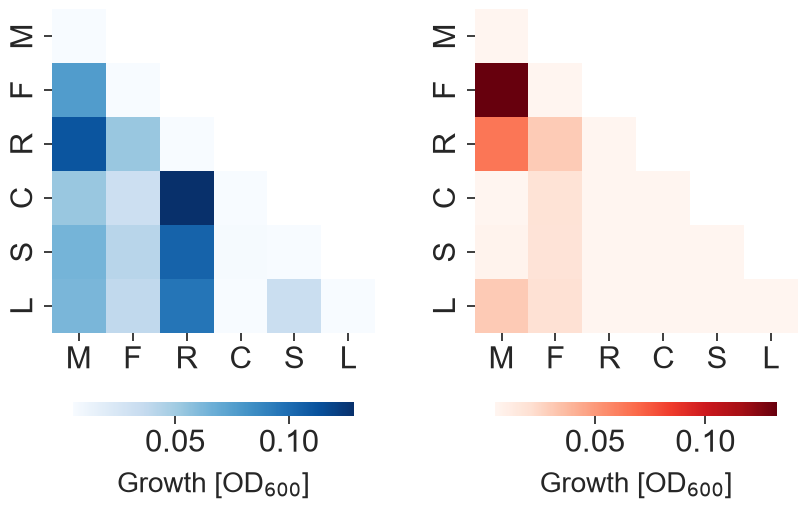

In [42]:
# Figure 1B
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

ax=axes[0]
data=(big_norm_df.query("Environment == 'Glut + Gly' " +
                  "and Aux1!= 'WT' and Species == 'Bs'")
     .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
     .reindex(['M','F','R','C','S','L'])).astype(float)[['M','F','R','C','S','L']]

sns.heatmap(data, cmap='Blues', square=True, linewidths=0, ax=ax, 
             cbar_kws={"orientation": "horizontal", "pad": 0.15, "shrink": 0.8})

cbar = ax.collections[0].colorbar
cbar.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

ax.set_ylabel('');ax.set_xlabel('')

ax=axes[1]
data=(big_norm_df.query("Environment == 'Glut + Gly' " +
                  "and Aux1!= 'WT' and Species == 'Ec'")
     .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
     .reindex(['M','F','R','C','S','L'])).astype(float)[['M','F','R','C','S','L']]

sns.heatmap(data, cmap='Reds', square=True, linewidths=0, ax=ax,
            cbar_kws={"orientation": "horizontal", "pad": 0.15, "shrink": 0.8})
ax.set_ylabel('');ax.set_xlabel('')
cbar = ax.collections[0].colorbar
cbar.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

plt.savefig('images/Fig1B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2); 



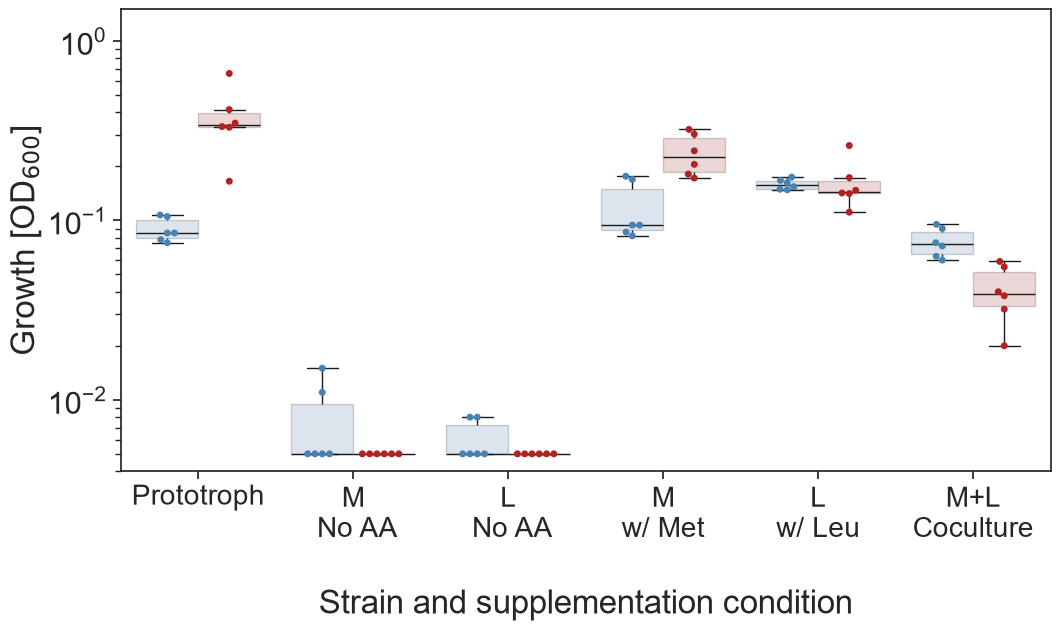

In [43]:
# Figure 1D
data=merged_df.query("Pair == 'WT+WT' or " + "Pair == 'M+Met' or " + 
                  "Pair == 'L+Leu' or " + "Pair == 'M+M' or " + "Pair == 'L+L' or " + 
                  "Pair == 'M+L'").query("Environment == 'Glut + Gly' ")

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.swarmplot(data=data, x='Pair', y='OD', ax=ax, s=5, 
              hue='Species', palette=['steelblue','firebrick'],
              hue_order=['Bs', 'Ec'], legend=False, dodge=True,
              order=['WT+WT','M+M','L+L','M+Met','L+Leu','M+L'])

sns.boxplot(data=data, x='Pair', y='OD', ax=ax, 
            hue='Species', palette=['steelblue','firebrick'], 
            hue_order=['Bs', 'Ec'], legend=False,
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},
            order=['WT+WT','M+M','L+L','M+Met','L+Leu','M+L'])


ax.set_yscale('log') ; ax.set_ylim(0.004,1.5)
ax.set_ylabel(r'Growth [OD$_{600}$]') ; ax.set_xlabel('\nStrain and supplementation condition')
ax.tick_params(axis="x", rotation=90)

condition_labels = ['Prototroph','M\n No AA','L\n No AA','M\nw/ Met','L\nw/ Leu','M+L\nCoculture']
ax.set_xticks(range(len(condition_labels)), labels=condition_labels,rotation=0, fontsize=20)

plt.savefig('images/Fig1D.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


## Figure 2. Auxotrophic phenotypes are nutrient dependent

In [45]:
# Figure 2 data preparation
# Quanitfy evnrioments in which each KO is auxotrophic
data=big_norm_df.query("Aux1 == Aux2 and Aux1!= 'WT' and Species == 'Bs'")
data=data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
data

wt_data=filtered_df.query("Aux1== 'WT' and Species == 'Bs'")
wt_data=wt_data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()


cols = wt_data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])

data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')

data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')

data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')

bs_aux_growth=data.melt(id_vars=['Aux1','Species',], value_vars=['n_grows_01','n_grows_05', 'n_grows_1'])



data=big_norm_df.query("Aux1 == Aux2 and Aux1!= 'WT' and Species == 'Ec'")
data=data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()

wt_data=filtered_df.query("Aux1== 'WT' and Species == 'Ec'")
wt_data=wt_data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()


cols = wt_data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])

data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')

data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')

data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')

ec_aux_growth=data.melt(id_vars=['Aux1','Species',], value_vars=['n_grows_01','n_grows_05', 'n_grows_1'])

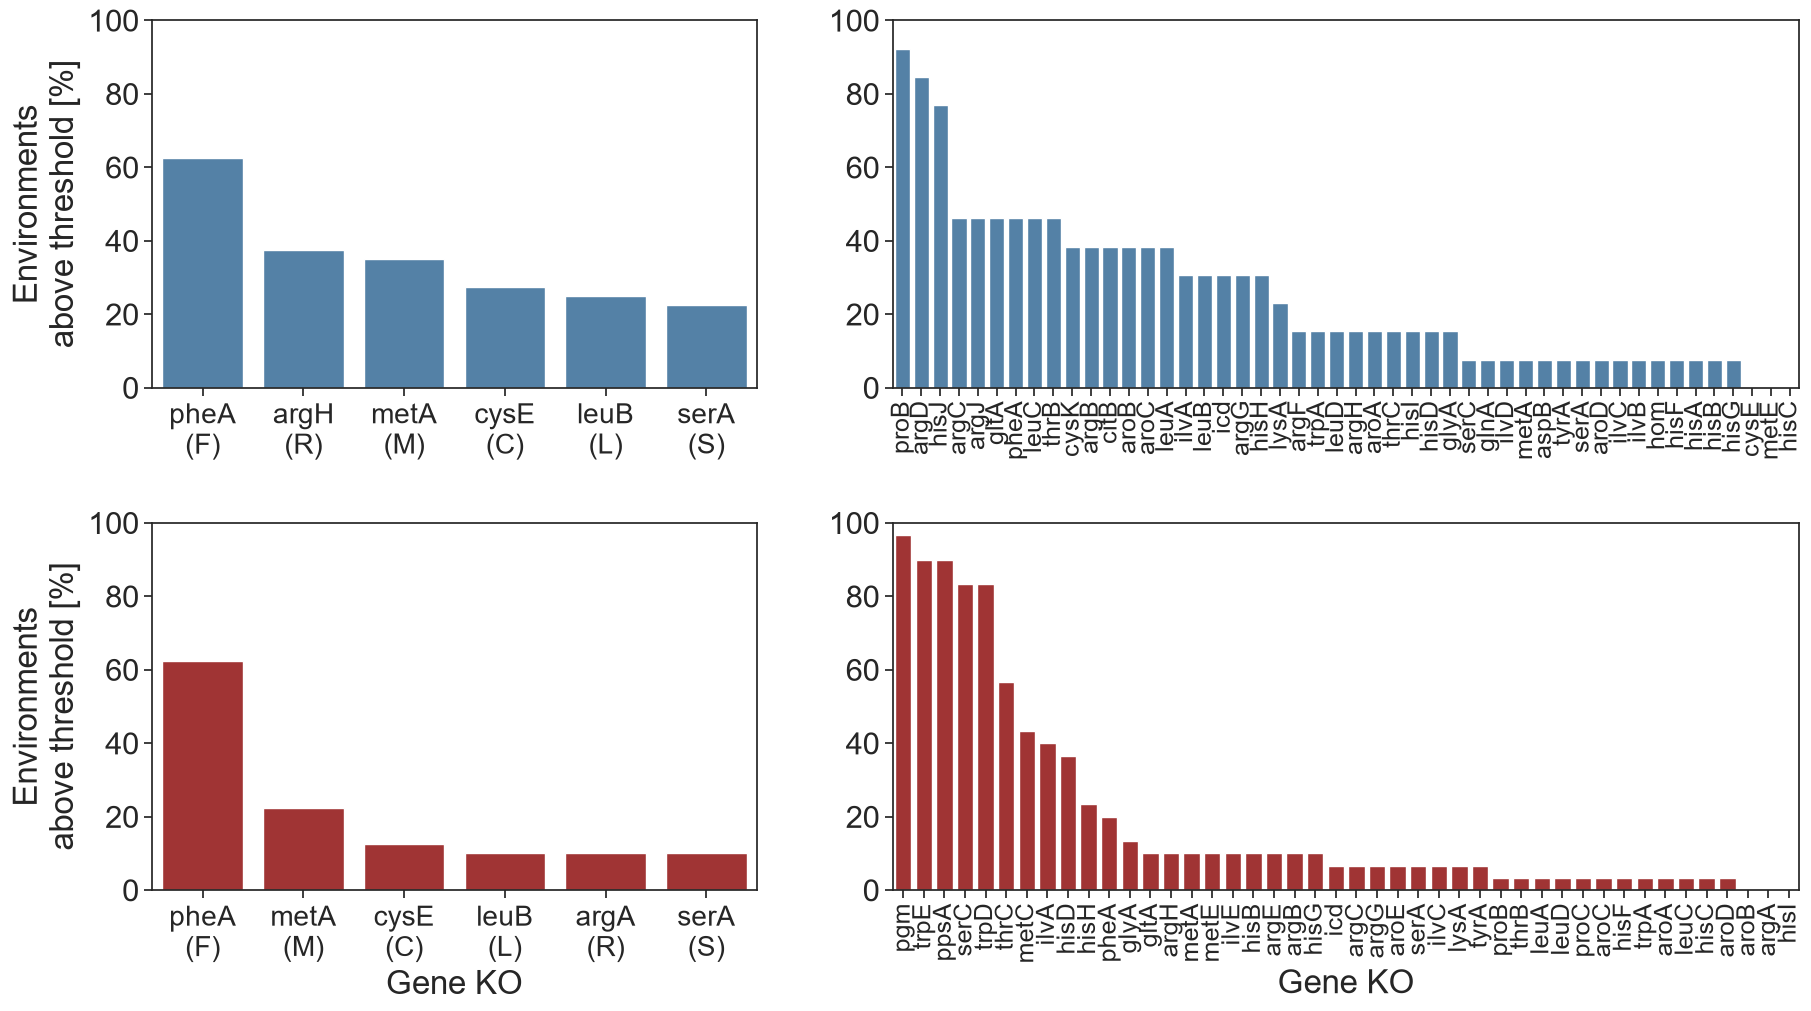

In [46]:
#Generate graphs

bs_label_map = {'M':'metA\n(M)', 'F':'pheA\n(F)', 'R':'argH\n(R)', 'C':'cysE\n(C)', 'S':'serA\n(S)', 'L':'leuB\n(L)'}
ec_label_map = {'M':'metA\n(M)', 'F':'pheA\n(F)', 'R':'argA\n(R)', 'C':'cysE\n(C)', 'S':'serA\n(S)', 'L':'leuB\n(L)'}


fig, axes = plt.subplots(2, 2, figsize=(18, 10),constrained_layout=True,
                         gridspec_kw={'width_ratios': [1, 1.5]},)
fig.set_constrained_layout_pads(wspace=0.08, hspace=0.1)

ax_bs_mono, ax_bs_koo = axes[0]
ax_ec_mono, ax_ec_tong = axes[1]


# Panel A: Bs mono auxotrophs
sns.barplot(data=bs_aux_growth.query("Environment == 'n_grows_01'"), x='Aux1', y='value', color='steelblue', ax=ax_bs_mono,
              order=list(bs_aux_growth.query("Environment == 'n_grows_01'").set_index('Aux1')['value']
                         .sort_values(ascending=False).index))

ax_bs_mono.set_ylabel('Environments\nabove threshold [%]') ; ax_bs_mono.set_xlabel('')
ax_bs_mono.set_ylim(0, 100)
bs_tick_labels = [bs_label_map[t.get_text()] for t in ax_bs_mono.get_xticklabels()]
ax_bs_mono.set_xticks(ax_bs_mono.get_xticks(), labels=bs_tick_labels, rotation=0, fontsize=20)
# Panel B: Bs Koo knockouts
bs_koo = koo_df_bs_auxs.query("Casette == 'Erm'")

sns.barplot(data=bs_koo, x='gene', y='n_grows_01', color='steelblue',ax=ax_bs_koo,
            order=list(bs_koo.set_index('gene')['rank_01'].sort_values().index))

ax_bs_koo.tick_params(axis='x', rotation=90, labelsize=18)
ax_bs_koo.set_ylim(0,100)
ax_bs_koo.set_ylabel('') ; ax_bs_koo.set_xlabel('')

# Panel C: Ec mono auxotrophs
sns.barplot(data=ec_aux_growth.query("Environment == 'n_grows_01'"), x='Aux1', y='value', color='firebrick', ax=ax_ec_mono,
              order=list(ec_aux_growth.query("Environment == 'n_grows_01'")
                         .set_index('Aux1')['value'].sort_values(ascending=False).index))

ax_ec_mono.set_ylabel('Environments\nabove threshold [%]') ; ax_ec_mono.set_xlabel('Gene KO')
ax_ec_mono.set_ylim(0, 100)
ec_tick_labels = [ec_label_map[t.get_text()] for t in ax_ec_mono.get_xticklabels()]
ax_ec_mono.set_xticks(ax_ec_mono.get_xticks(), labels=ec_tick_labels, rotation=0, fontsize=20)
# Panel D: Ec Tong knockouts
sns.barplot(data=tong_df_ec_auxs, x='gene', y='n_grows_01', color='firebrick',ax=ax_ec_tong,
            order=list(tong_df_ec_auxs.set_index('gene')['rank_01'].sort_values().index))

ax_ec_tong.tick_params(axis='x', rotation=90, labelsize=18)
ax_ec_tong.set_ylim(0,100)
ax_ec_tong.set_ylabel('') ; ax_ec_tong.set_xlabel('Gene KO')


plt.savefig('images/Fig2.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

## Figure 3. Crossfeeding varies widely across conditions

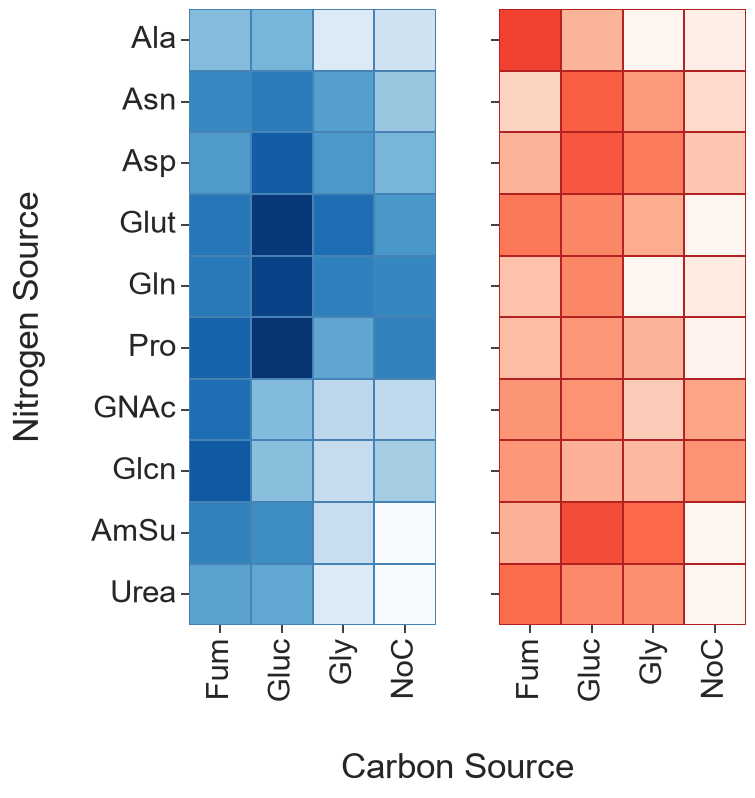

In [48]:
C_order = ['Fum', 'Gluc', 'Gly', 'NoC']                 
N_order = ['Ala',  'Asn', 'Asp', 'Glut', 'Gln', 'Pro',
           'GNAc', 'Glcn', 'AmSu', 'Urea',] 

fig, axes = plt.subplots(1,2, figsize=(8,8),gridspec_kw={'wspace': 0}, sharey=True)

bs_envs =(comp_env_df
           .pivot(index='C', columns='N', values='Norm_mean_Bs')
           .reindex(index=C_order, columns=N_order)).T

sns.heatmap(bs_envs, cmap='Blues', linecolor='steelblue', ax=axes[0],
            square=True, linewidths=0.1, 
            cbar=False, norm=LogNorm(vmin=0.005, vmax=0.15,))

ec_envs =(comp_env_df
           .pivot(index='C', columns='N', values='Norm_mean_Ec')
           .reindex(index=C_order, columns=N_order)).T

sns.heatmap(ec_envs, cmap='Reds', linecolor='firebrick', ax=axes[1],
            square=True, linewidths=0.1,
            cbar=False, norm=LogNorm(vmin=0.005, vmax=0.15,))

axes[0].set_ylabel("Nitrogen Source\n",  fontsize=25);axes[0].set_xlabel("")
axes[1].set_ylabel("");axes[1].set_xlabel("")
fig.suptitle("\nCarbon Source", y=0.001, fontsize=25)

plt.savefig('images/Fig3A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

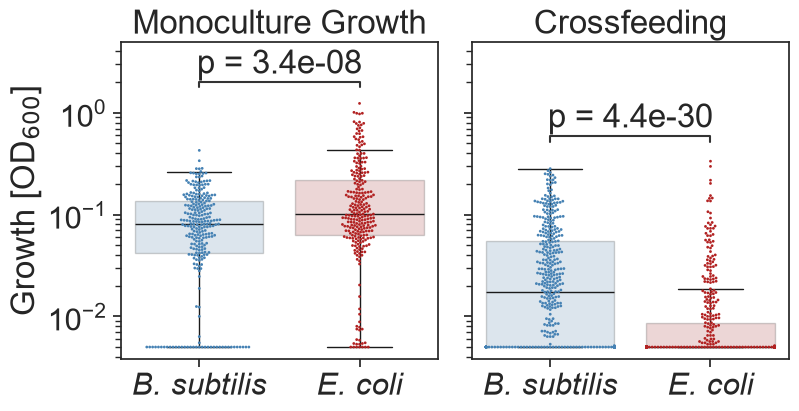

In [49]:
# Figure 3B
warnings.filterwarnings("ignore", message=".*points cannot be placed.*")


fig, axes = plt.subplots(1,2, figsize=(8,4), sharey=True, subplot_kw={'box_aspect': 1},
                         constrained_layout=True)

sns.swarmplot(data=aa_long.query("Aux1 != 'WT'"), x='Species', y='Mean', ax=axes[0], s=2, 
              hue='Species', palette=['steelblue','firebrick'])
sns.boxplot(data=aa_long.query("Aux1 != 'WT'"), x='Species', y='Mean', ax=axes[0],
            hue='Species', palette=['steelblue','firebrick'], 
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},)
axes[0].set_yscale('log'); axes[0].set_ylabel('Growth [OD$_{600}$]')
axes[0].set_xlabel('');axes[0].set_title('Monoculture Growth')

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['B. subtilis', 'E. coli'], style='italic')

# Add statistical annotation
annot = Annotator(ax=axes[0], pairs=[("Bs", "Ec")],
                  data=aa_long.query("Aux1 != 'WT'"), x='Species', y='Mean')
annot.configure(test='Wilcoxon', text_format='full', pvalue_format_string='{:.1e}',
                loc='inside', verbose=0, show_test_name=False)
annot.apply_test()#(alternative='greater')
annot.annotate()

######################################################################################################

sns.swarmplot(data=df_long.query("Aux1 != Aux2"), x='Species', y='Norm_mean',ax=axes[1], s=2,
             hue='Species', palette=['steelblue','firebrick'])
sns.boxplot(data=df_long.query("Aux1 != Aux2"), x='Species', y='Norm_mean', ax=axes[1],
            hue='Species', palette=['steelblue','firebrick'], 
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},)
axes[1].set_yscale('log')
axes[1].set_xlabel('');axes[1].set_title('Crossfeeding')

annot = Annotator(ax=axes[1], pairs=[("Bs", "Ec")],
                  data=df_long[df_long.Aux1!=df_long.Aux2], x='Species', y='Norm_mean')
annot.configure(test='Wilcoxon', text_format='full',pvalue_format_string='{:.1e}',
                loc='inside', verbose=0, show_test_name=False)
annot.apply_test()#(alternative='greater')
annot.annotate()

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['B. subtilis', 'E. coli'], style='italic')

plt.savefig('images/Fig3B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

In [50]:
#Calculate means
mono_bs_gmean=sp.stats.gmean(aa_long.query("Species == 'Bs'and Aux1 != 'WT'").Mean)
mono_ec_gmean=sp.stats.gmean(aa_long.query("Species == 'Ec'and Aux1 != 'WT'").Mean)
print(f"Monoculture geometric mean (Bs) = {mono_bs_gmean:.4g}")
print(f"Monoculture geometric mean (Ec) = {mono_ec_gmean:.4g}")
print(f"Monoculture fold-change (Ec/Bs) = {mono_ec_gmean/mono_bs_gmean:.3g}\n")

cf_bs_gmean=sp.stats.gmean(df_long.query("Aux1 != Aux2 and Species == 'Bs'").Norm_mean)
cf_ec_gmean=sp.stats.gmean(df_long.query("Aux1 != Aux2 and Species == 'Ec'").Norm_mean)

print(f"Crossfeeding geometric mean (Bs) = {cf_bs_gmean:.4g}")
print(f"Crossfeeding geometric mean (Ec) = {cf_ec_gmean:.4g}")
print(f"Crossfeeding fold-change (Bs/Ec) = {cf_bs_gmean/cf_ec_gmean:.3g}")

Monoculture geometric mean (Bs) = 0.06008
Monoculture geometric mean (Ec) = 0.1042
Monoculture fold-change (Ec/Bs) = 1.73

Crossfeeding geometric mean (Bs) = 0.01901
Crossfeeding geometric mean (Ec) = 0.007929
Crossfeeding fold-change (Bs/Ec) = 2.4


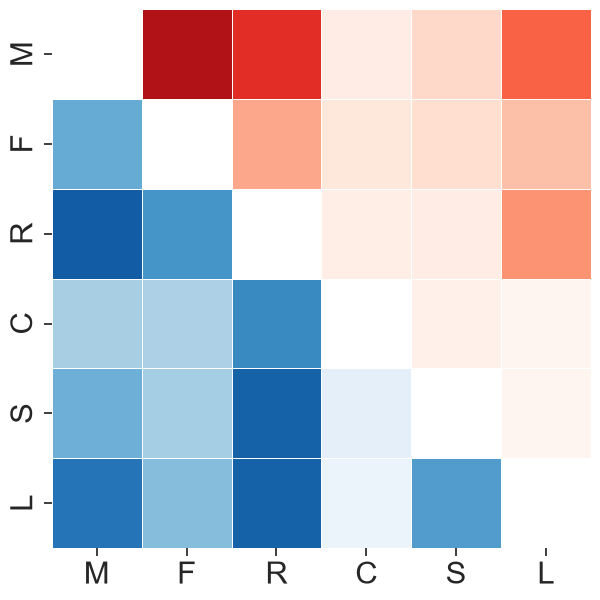

In [51]:
pair_order = ['M','F','R','C','S','L']
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

# Bs in lower triangle - values
bs_lower =(cf_comp_pair_df
           .pivot(index='Aux1', columns='Aux2', values='Norm_mean_Bs')
           .reindex(index=pair_order, columns=pair_order).T)

# Ec in upper triangle - values
ec_upper = (cf_comp_pair_df
           .pivot(index='Aux1', columns='Aux2', values='Norm_mean_Ec')
           .reindex(index=pair_order, columns=pair_order))

# mask everything except lower triangle for Bs
mask_bs = np.triu(np.ones(bs_lower.shape, dtype=bool), k=0)
# mask everything except upper triangle for Ec
mask_ec = np.tril(np.ones(ec_upper.shape, dtype=bool), k=0)

# plot blue lower triangle
sns.heatmap(bs_lower, mask=mask_bs, cmap='Blues',  
            square=True, linewidths=0.5, cbar=False, ax=ax,
            norm=LogNorm(vmin=0.005, vmax=0.15,))

# plot red upper triangle
sns.heatmap(ec_upper, mask=mask_ec, cmap='Reds', 
            square=True, linewidths=0.5, cbar=False, ax=ax,
            norm=LogNorm(vmin=0.005, vmax=0.15,))

ax.set_ylabel('');ax.set_xlabel('')

plt.savefig('images/Fig3C.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

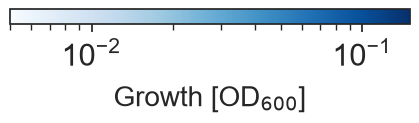

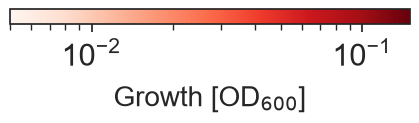

In [52]:
# Figure 3 colorbars
plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.3]]), cmap="Blues", norm=LogNorm(vmin=0.005, vmax=0.15))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)
plt.savefig('images/Fig3_blue_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.6]]), cmap="Reds", norm=LogNorm(vmin=0.005, vmax=0.15))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

plt.savefig('images/Fig3_red_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


## Figure 4. Auxotrophy is a better predictor than the environment for cross-feeding across species 

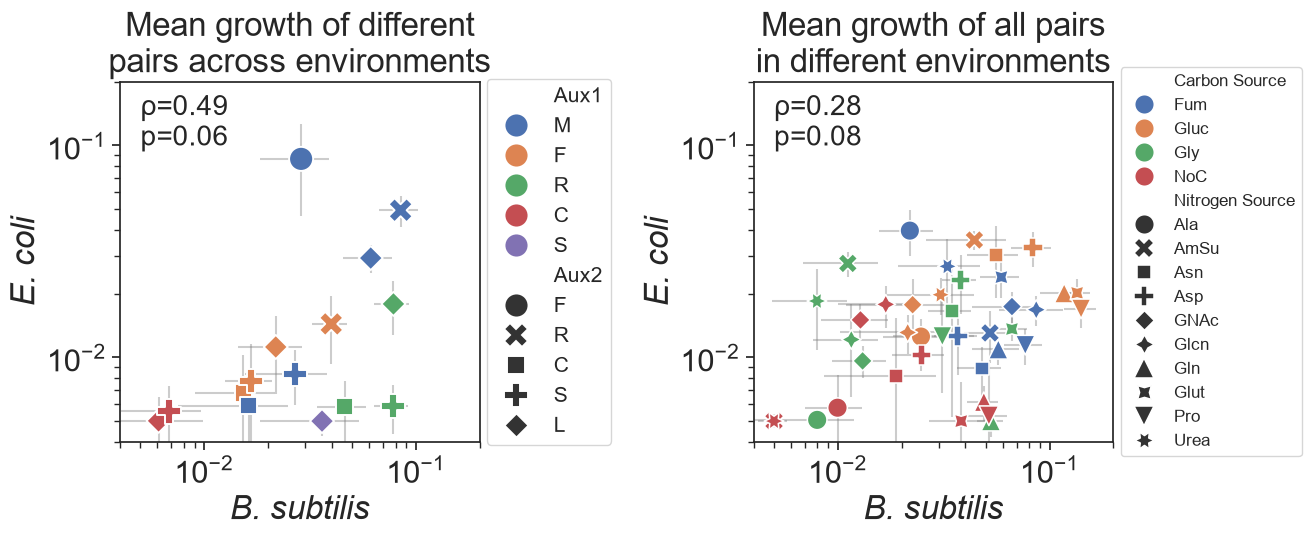

In [54]:
# Figure 4- A and B
fig, axes = plt.subplots(1,2, figsize=(13,6), subplot_kw={'box_aspect': 1},
                         constrained_layout=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.05})


ax=axes[0]; ax.set_box_aspect(1)
data=cf_comp_pair_df[cf_comp_pair_df.Aux1!=cf_comp_pair_df.Aux2]
sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="Aux1", hue_order=['M', 'F', 'R', 'C', 'S'],
                style="Aux2", style_order=['F', 'R', 'C', 'S', 'L'],
                ax=ax, legend="full", s=300, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

rho, rho_pval = sp.stats.spearmanr(data["Norm_mean_Bs"], data["Norm_mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of different\npairs across environments')
ax.legend( loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=15)

###################################################################################################

ax=axes[1]; ax.set_box_aspect(1)
data=comp_env_df.query("N != 'NoN'") 

sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="C", style="N", ax=ax, legend="full", s=200, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)


rho, rho_pval = sp.stats.spearmanr(data["Norm_mean_Bs"], data["Norm_mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of all pairs\nin different environments')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[6:],
          loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=12);

    
plt.savefig('images/Fig4AB.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


Pairs better than WT = 33
523
Pairs better than WT = 1
450
Total pairs better than WT = 34/973 (3.5%)


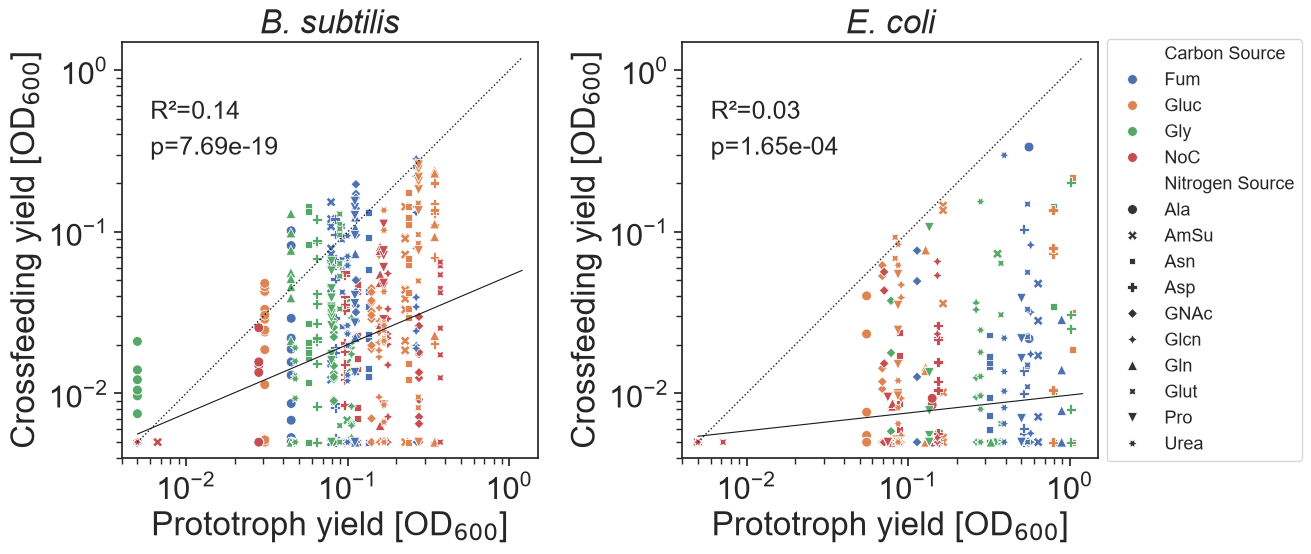

In [55]:
# Figure 4C
fig, axes = plt.subplots(1,2, figsize=(13,6), subplot_kw={'box_aspect': 1},
                         constrained_layout=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

for ax in axes:
    ax.set_box_aspect(1) # Sets the box aspect to be 1:1 (square)
    
title_dic={0:'B. subtilis',1:'E. coli'}

for x, data in enumerate([bs_df,ec_df]):
    ax = axes[x]
    data=data.query("Aux1 != 'WT' and Aux1 != Aux2 and N != 'NoN'")
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean",  data=data,
                    hue="C", style="N", ax=ax, s=50, zorder=1)
    
   
    # Apply log10
    x_log = np.log10(data["WT_mean"])
    y_log = np.log10(data["Norm_mean"])
    
    # Regression
    r = sp.stats.linregress(x_log, y_log)
    ax.text(0.006, 0.5, "R²="+str(((r.rvalue)**2).round(2)), fontsize=18)
    ax.text(0.006, 0.3, f"p={r.pvalue:.2e}", fontsize=18)
    
    x_vals = np.logspace(np.log10(0.005), np.log10(1.2), 10)
    y_vals = 10**(r.slope * np.log10(x_vals) + r.intercept)
    ax.plot(x_vals, y_vals, color='k', lw=0.8)
    ax.plot(x_vals, x_vals, color='k', lw=1, linestyle='dotted')
    
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Prototroph yield [OD$_{600}$]"); ax.set_ylabel("Crossfeeding yield [OD$_{600}$]")
    ax.set_xlim(0.004, 1.5); ax.set_ylim(0.004, 1.5)
    ax.set_title(title_dic[x], style='italic')

    if x==0:
        ax.get_legend().remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[6:],
                  loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=13);    
    
    print("Pairs better than WT = " + str(len((data[((data.Norm_mean-data.Norm_sem)>data.WT_mean)]))))
    print(str(len((data))))
    
crossfeeding_df = filtered_df.query("Aux1 != 'WT' and Aux1 != Aux2 and N != 'NoN'").copy()
n_better = ((crossfeeding_df["Norm_mean"] - crossfeeding_df["Norm_sem"])> crossfeeding_df["WT_mean"]).sum()

print(f"Total pairs better than WT = {n_better}/{len(crossfeeding_df)} "
      f"({n_better / len(crossfeeding_df) * 100:.1f}%)")

plt.savefig('images/Fig4C.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

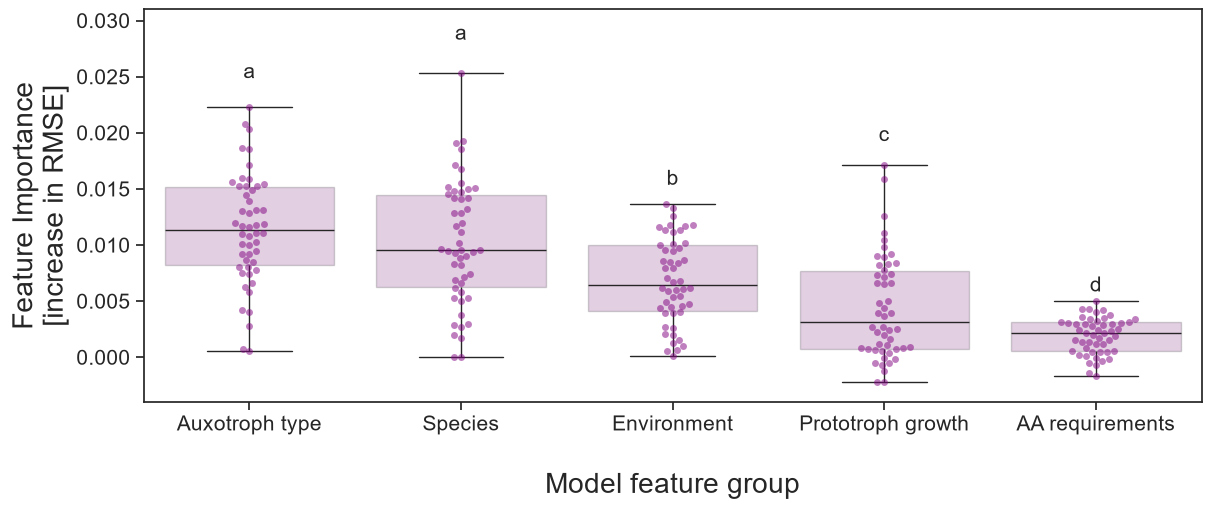

In [56]:
# Figure 4D
fig, ax = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)

sns.swarmplot(data=block_cv_folds_fast, x="block", y="rmse_increase",
              color="purple", ax=ax, s=5, alpha=0.5,
              order=list(cld.sort_values('Letters').index))

sns.boxplot(data=block_cv_folds_fast, x="block", y="rmse_increase", ax=ax,
            color="purple", fliersize=0, boxprops={'alpha':0.2},
            order=list(cld.sort_values('Letters').index))

# ax.set_yscale('log')
ax.set_ylim(-0.004,0.031)
ax.set_ylabel('Feature Importance\n[increase in RMSE]', size=20)
ax.set_xlabel('\nModel feature group', size=20)
ax.tick_params(axis="x", rotation=0, labelsize=15)
ax.tick_params(axis="y", rotation=0, labelsize=15)

# Add letters
ymax = block_cv_folds_fast.groupby("block")["rmse_increase"].max()
for i, g in enumerate(list(cld.sort_values('Letters').index)):
    # place slightly above max (multiplicative offset works well on log scale)
    y = ymax[g] * 1.1
    ax.text(i, y, cld.to_dict()['Letters'][g], ha="center", va="bottom", fontsize=15)

plt.savefig('images/Fig4D.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


## Supplementary figures

### Figure S1. Nutrient dependent phenotypes of *B. subtilis* KOs with ErmR cassette

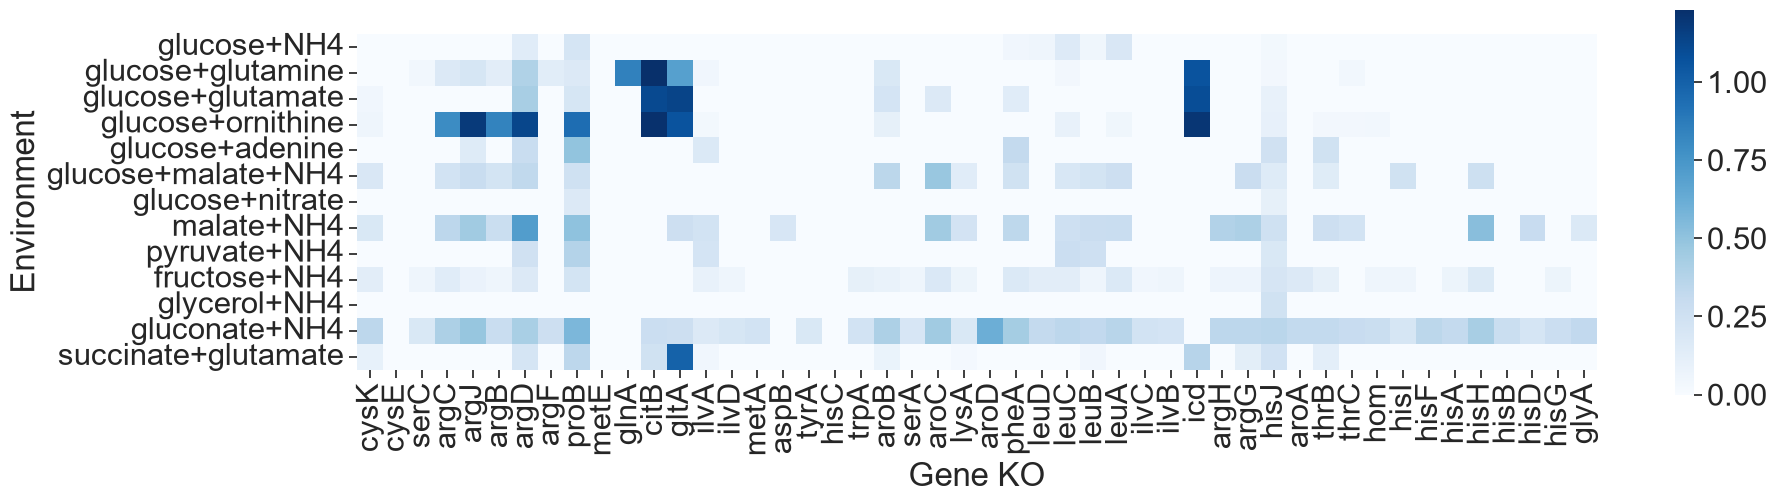

In [59]:
# Figure S1A
data=koo_df_bs_auxs.query("Casette == 'Erm'")[koo_df_bs_auxs.columns[1:15]]
data=data.set_index('gene').T
data.index = data.index.str.replace('_', '+', regex=False)


fig, ax = plt.subplots(1, 1, figsize=(20,5))
sns.heatmap(data=data, yticklabels=1, xticklabels=1, cmap='Blues', square=True, ax=ax)
ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO');

plt.savefig('images/FigS1A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

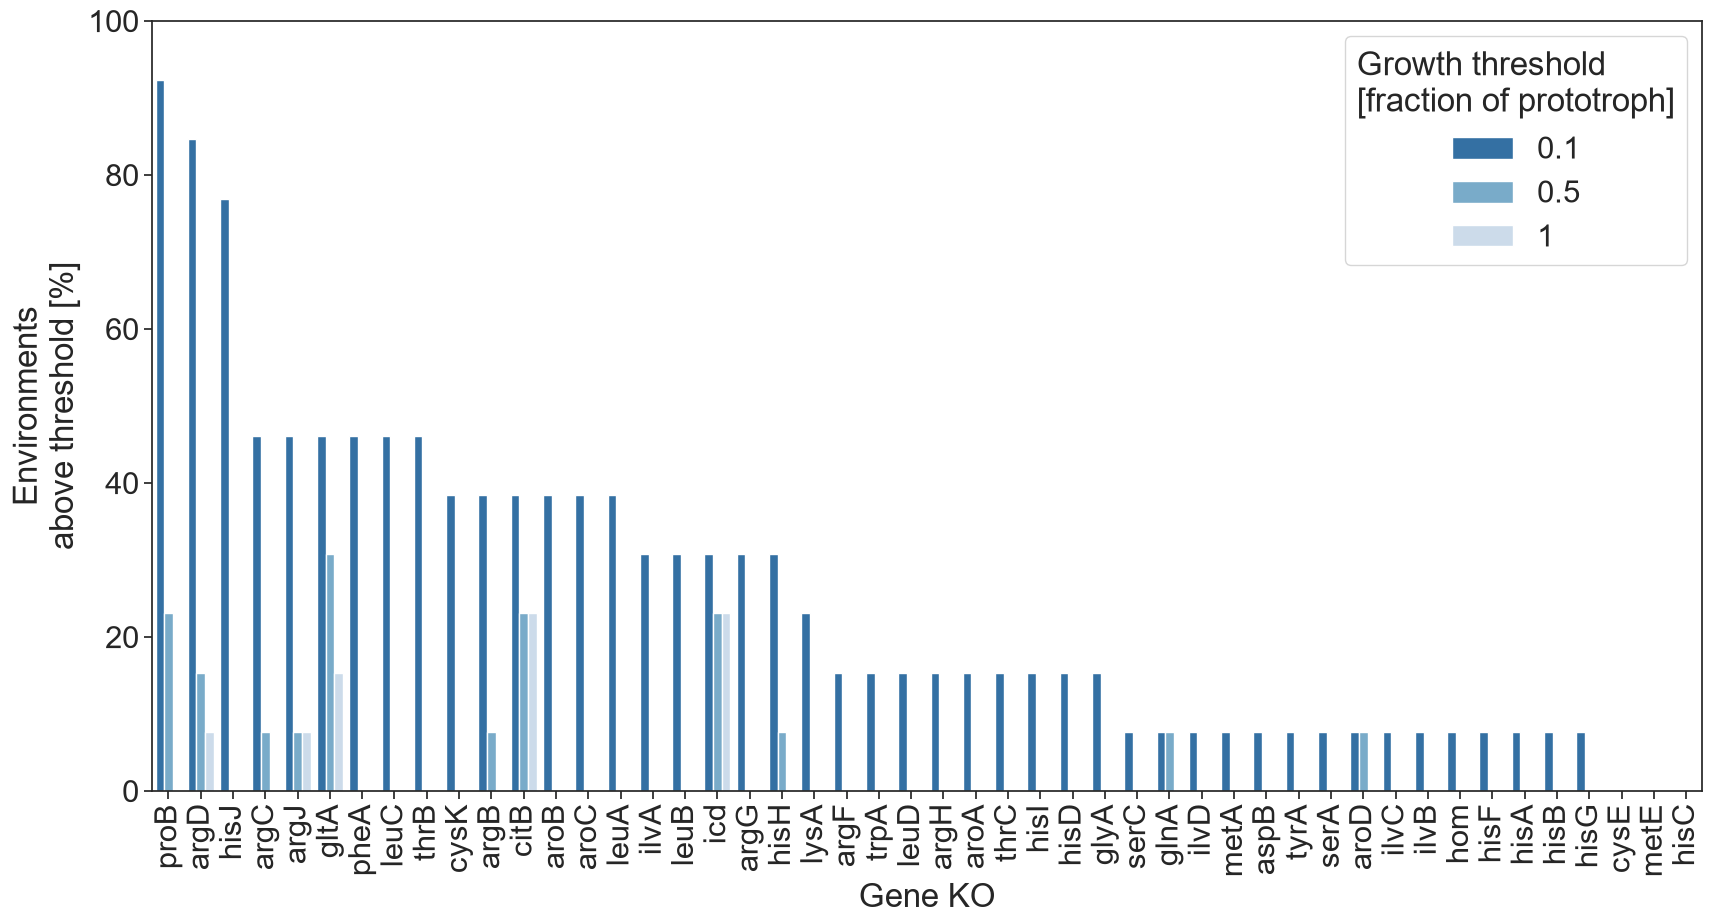

In [60]:
# Figure S1B
aux_melt=koo_df_bs_auxs.melt(id_vars=['gene','Casette','rank_01',], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])


fig, ax = plt.subplots(1, 1, figsize=(20, 10))

g=sns.barplot(data=aux_melt.query("Casette == 'Erm'"), x='gene', y='value',  
            hue= 'variable', palette='Blues_r',
           order=list(aux_melt.query("Casette == 'Erm'").set_index('gene')['rank_01'].sort_values().index))

plt.xticks(rotation=90)
ax.set_ylim(0,100)
ax.set_ylabel('Environments\nabove threshold [%]') ; ax.set_xlabel('Gene KO')
# ax.tick_params(axis="x", rotation=90)
plt.xticks(rotation=90);
# get legend entries created by seaborn
handles, labels = ax.get_legend_handles_labels()

# keep only the first 4 
handles = handles[:3]
labels = labels[:3]

# rename them manually
new_labels = ["0.1", "0.5", "1"]   

ax.legend(handles, new_labels, title="Growth threshold\n[fraction of prototroph]");
plt.savefig('images/FigS1B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S2. Nutrient dependent phenotypes of *B. subtilis* KOs with KanR cassette

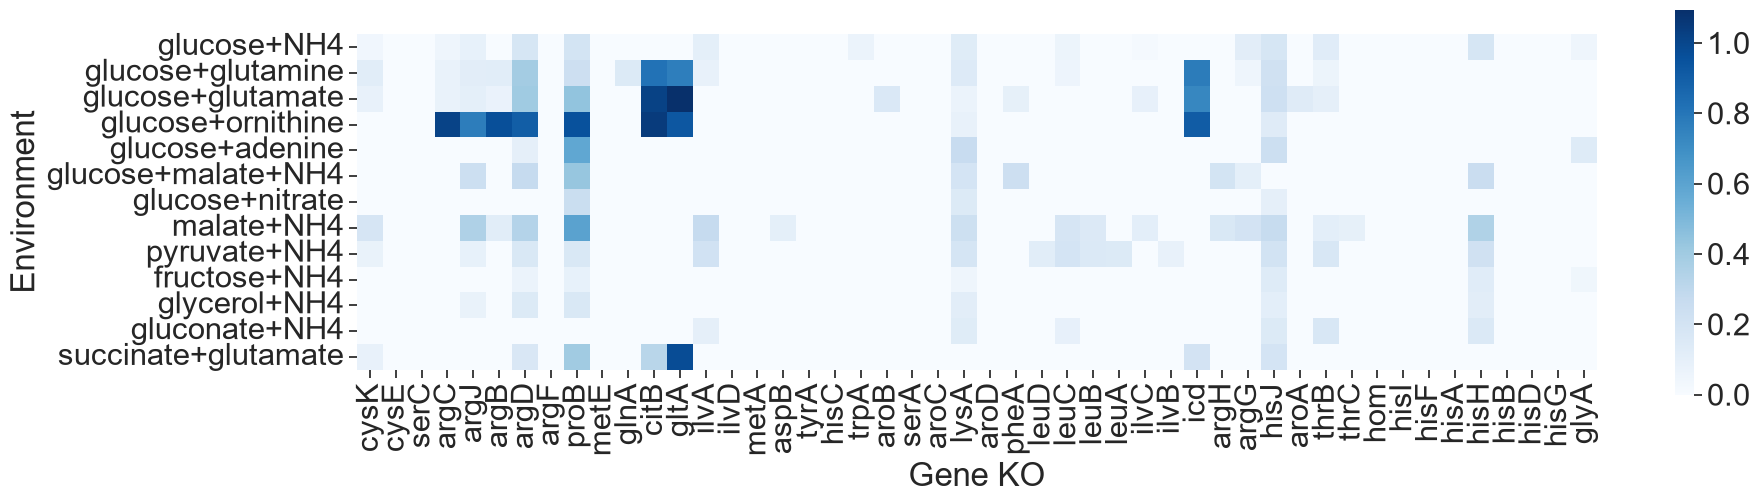

In [62]:
# Figure S2A
data=koo_df_bs_auxs.query("Casette == 'Kan'")[koo_df_bs_auxs.columns[1:15]]
data=data.set_index('gene').T
data.index = data.index.str.replace('_', '+', regex=False)


fig, ax = plt.subplots(1, 1, figsize=(20,5))
sns.heatmap(data=data, yticklabels=1, xticklabels=1, cmap='Blues', square=True, ax=ax)
ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO');

plt.savefig('images/FigS2A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

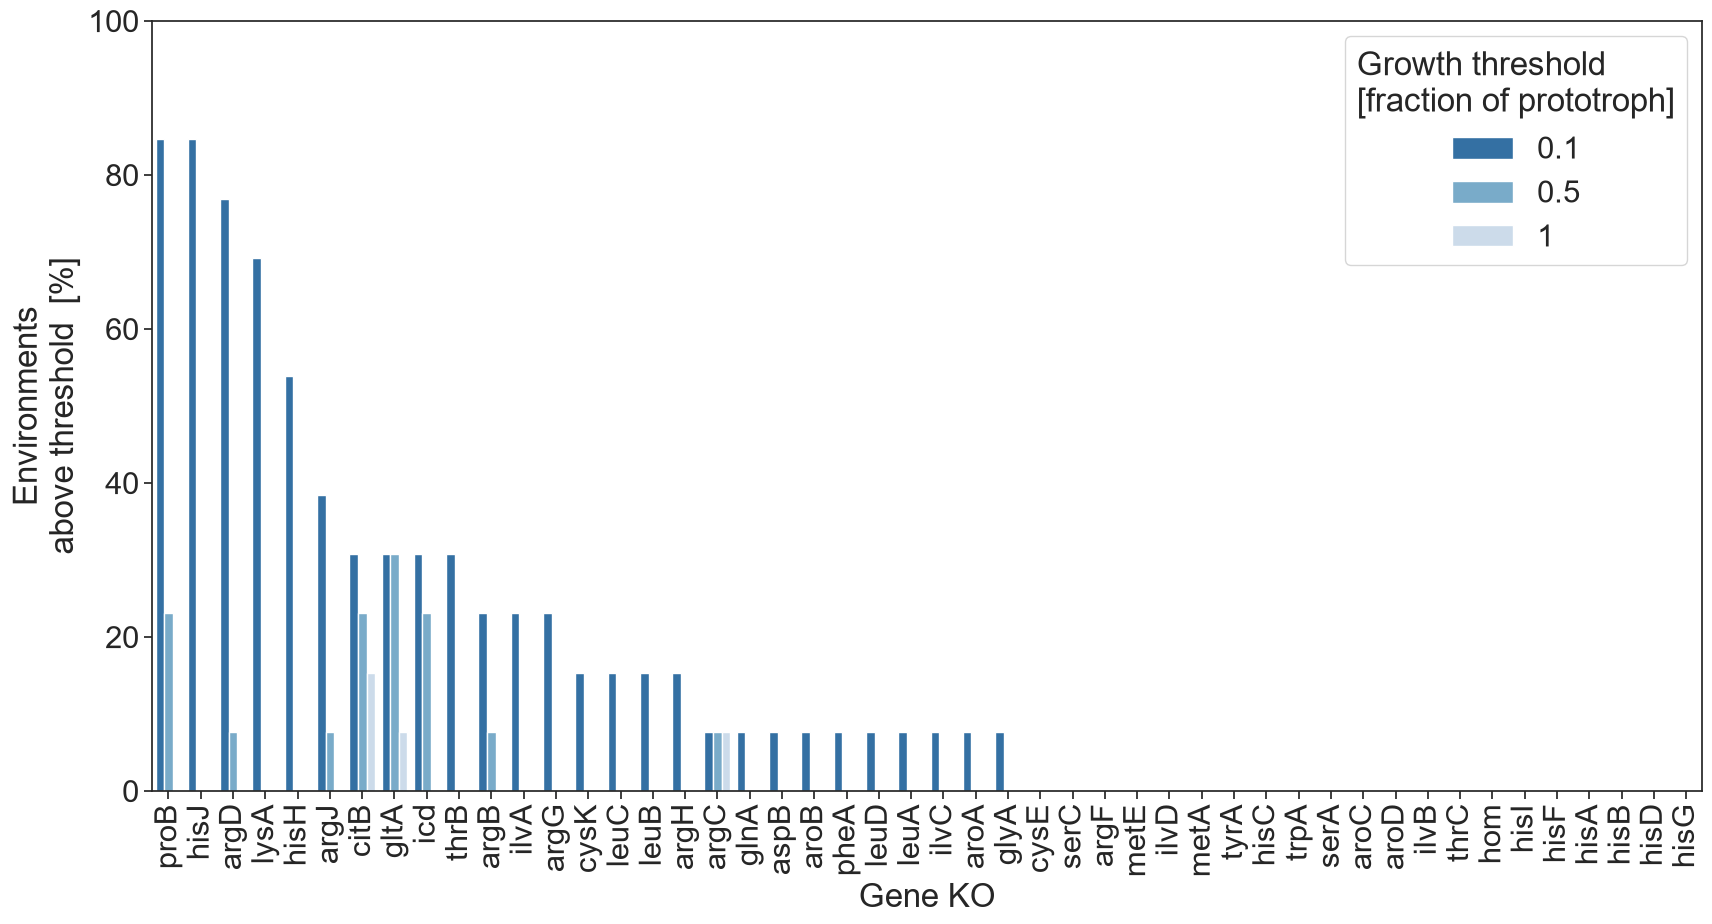

In [63]:
# Figure S2B
aux_melt=koo_df_bs_auxs.melt(id_vars=['gene','Casette','rank_01',], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])


fig, ax = plt.subplots(1, 1, figsize=(20, 10))

g=sns.barplot(data=aux_melt.query("Casette == 'Kan'"), x='gene', y='value',  
            hue= 'variable', palette='Blues_r',
           order=list(aux_melt.query("Casette == 'Kan'").set_index('gene')['rank_01'].sort_values().index))

plt.xticks(rotation=90)
ax.set_ylim(0,100)
ax.set_ylabel('Environments\nabove threshold  [%]') ; ax.set_xlabel('Gene KO')
# ax.tick_params(axis="x", rotation=90)
plt.xticks(rotation=90);
# get legend entries created by seaborn
handles, labels = ax.get_legend_handles_labels()

# keep only the first 4 
handles = handles[:3]
labels = labels[:3]

# rename them manually
new_labels = ["0.1", "0.5", "1"]   

ax.legend(handles, new_labels, title="Growth threshold\n[fraction of prototroph]");
plt.savefig('images/FigS2B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S3. Nutrient dependent phenotypes of *E. coli* KOs

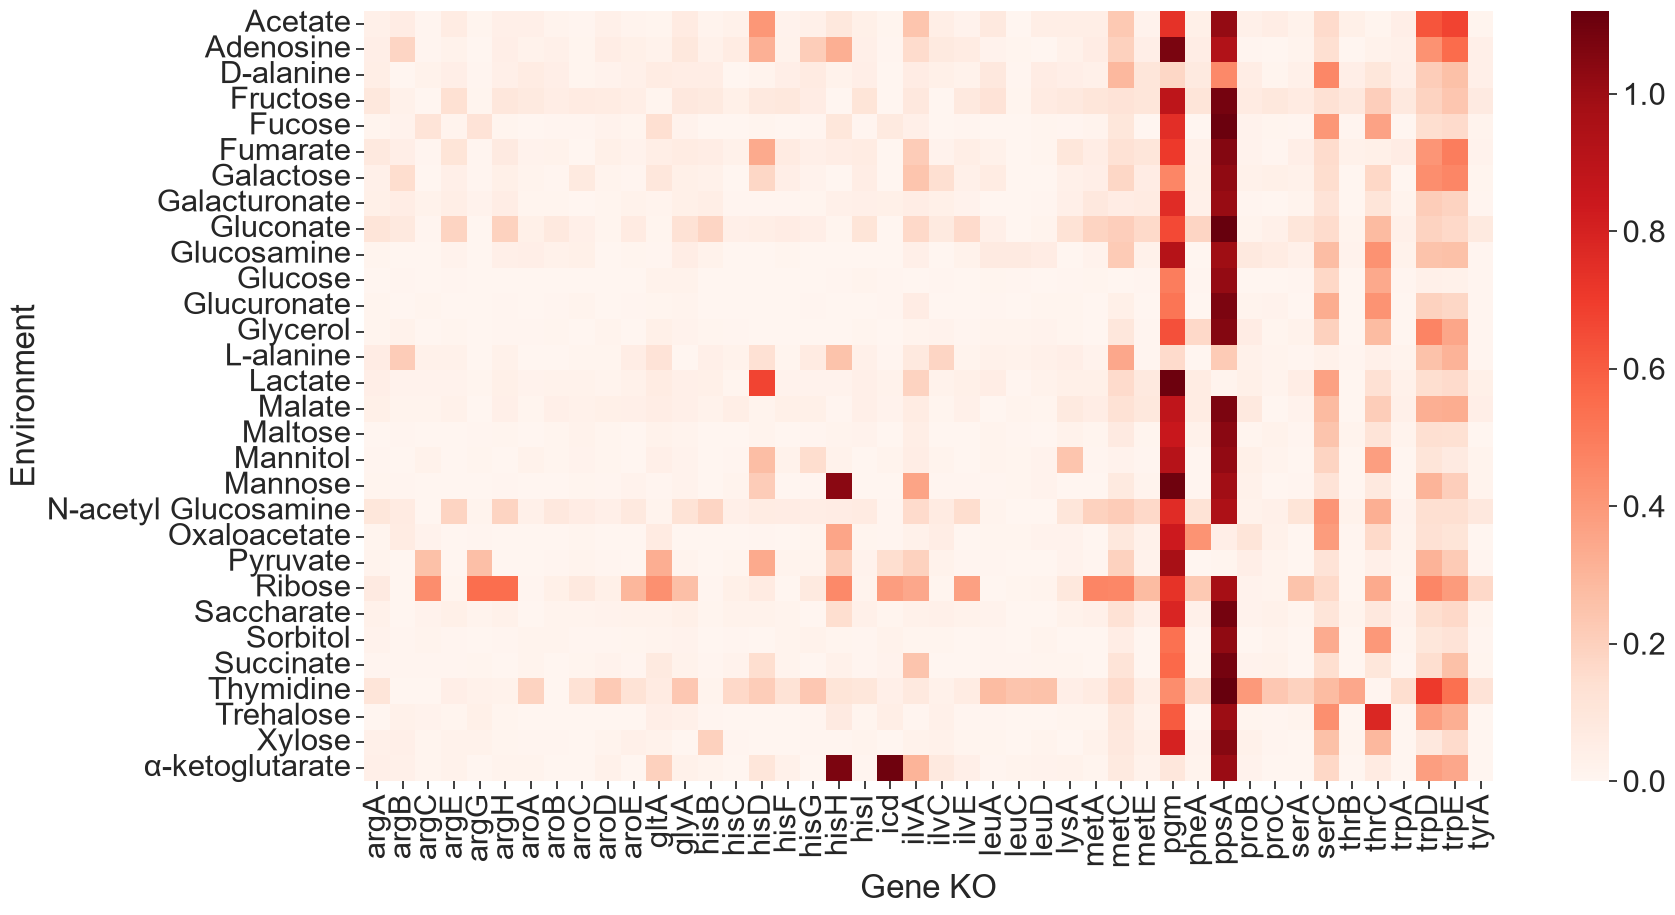

In [65]:
# Figure S3A
data=ec_auxs[ec_auxs.columns[1:]].sort_values('gene')
data=data.set_index('gene').drop('kdsC').T
data=data.loc[sorted(data.index)]

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
sns.heatmap(data=data, yticklabels=1, xticklabels=1, cmap='Reds', square=True, ax=ax)
ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO');
plt.savefig('images/FigS3A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

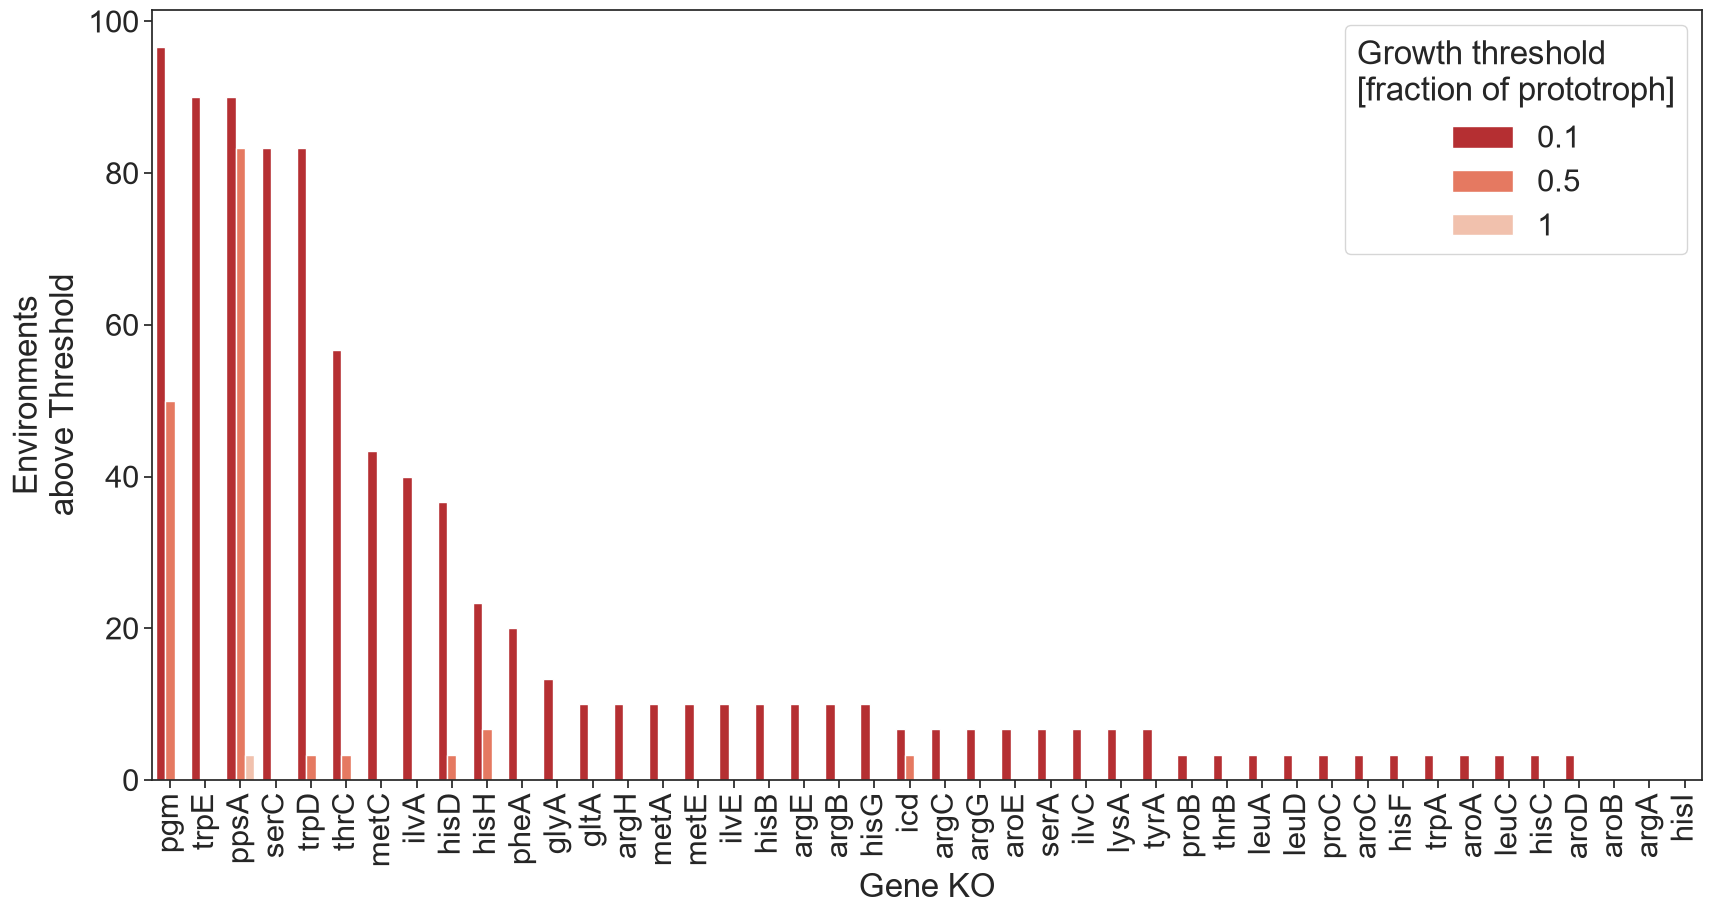

In [66]:
# Figure S3B
aux_melt=tong_df_ec_auxs.melt(id_vars=['gene','rank_01',], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])


fig, ax = plt.subplots(1, 1, figsize=(20, 10))
g=sns.barplot(data=aux_melt, x='gene', y='value', hue= 'variable', palette='Reds_r',
              order=list(tong_df_ec_auxs.set_index('gene')['rank_01'].sort_values().index))

plt.xticks(rotation=90)

ax.set_ylabel('Environments\nabove Threshold') ; ax.set_xlabel('Gene KO')
# ax.tick_params(axis="x", rotation=90)
plt.xticks(rotation=90);
# get legend entries created by seaborn
handles, labels = ax.get_legend_handles_labels()

# keep only the first 4 
handles = handles[:3]
labels = labels[:3]

# rename them manually
new_labels = ["0.1", "0.5", "1"]   

ax.legend(handles, new_labels, title="Growth threshold\n[fraction of prototroph]");
plt.savefig('images/FigS3B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

In [67]:
# Summary of KO–dataset combinations that exceeded each growth threshold
# Rule: normalized KO growth > 0.1, > 0.5, or > 1 in at least one environment.
# Exact equality with each threshold is not counted.

datasets_thresholds = {
    "This study – B. subtilis": {
        ">0.1": bs_aux_growth.loc[bs_aux_growth["Environment"] == "n_grows_01", "value"],
        ">0.5": bs_aux_growth.loc[bs_aux_growth["Environment"] == "n_grows_05", "value"],
        ">1.0": bs_aux_growth.loc[bs_aux_growth["Environment"] == "n_grows_1", "value"]},

    "This study – E. coli": {
        ">0.1": ec_aux_growth.loc[ec_aux_growth["Environment"] == "n_grows_01", "value"],
        ">0.5": ec_aux_growth.loc[ec_aux_growth["Environment"] == "n_grows_05", "value"],
        ">1.0": ec_aux_growth.loc[ec_aux_growth["Environment"] == "n_grows_1", "value"]},

    "Tong et al.": {
        ">0.1": tong_df_ec_auxs["n_grows_01"],
        ">0.5": tong_df_ec_auxs["n_grows_05"],
        ">1.0": tong_df_ec_auxs["n_grows_1"]},

    "Koo et al. – Erm": {
        ">0.1": koo_df_bs_auxs.loc[koo_df_bs_auxs["Casette"] == "Erm", "n_grows_01"],
        ">0.5": koo_df_bs_auxs.loc[koo_df_bs_auxs["Casette"] == "Erm", "n_grows_05"],
        ">1.0": koo_df_bs_auxs.loc[koo_df_bs_auxs["Casette"] == "Erm", "n_grows_1"]},

    "Koo et al. – Kan": {
        ">0.1": koo_df_bs_auxs.loc[koo_df_bs_auxs["Casette"] == "Kan", "n_grows_01"],
        ">0.5": koo_df_bs_auxs.loc[koo_df_bs_auxs["Casette"] == "Kan", "n_grows_05"],
        ">1.0": koo_df_bs_auxs.loc[koo_df_bs_auxs["Casette"] == "Kan", "n_grows_1"]},}

threshold_summary = pd.DataFrame([{
    "Dataset": dataset,
    "Total KO–dataset combinations": len(values[">0.1"]),
    "Exceeded 0.1 in ≥1 environment": int(values[">0.1"].gt(0).sum()),
    "Exceeded 0.5 in ≥1 environment": int(values[">0.5"].gt(0).sum()),
    "Exceeded 1.0 in ≥1 environment": int(values[">1.0"].gt(0).sum())}
    for dataset, values in datasets_thresholds.items()])

total_row = pd.DataFrame([{
    "Dataset": "Total",
    "Total KO–dataset combinations": threshold_summary["Total KO–dataset combinations"].sum(),
    "Exceeded 0.1 in ≥1 environment": threshold_summary["Exceeded 0.1 in ≥1 environment"].sum(),
    "Exceeded 0.5 in ≥1 environment": threshold_summary["Exceeded 0.5 in ≥1 environment"].sum(),
    "Exceeded 1.0 in ≥1 environment": threshold_summary["Exceeded 1.0 in ≥1 environment"].sum()}])

threshold_summary = pd.concat([threshold_summary, total_row], ignore_index=True)

for threshold in ["0.1", "0.5", "1.0"]:
    count_column = f"Exceeded {threshold} in ≥1 environment"
    threshold_summary[f"Percentage >{threshold}"] = (
        threshold_summary[count_column] /
        threshold_summary["Total KO–dataset combinations"] * 100
    )

display(threshold_summary.round(1))

,Dataset,Total KO–dataset combinations,Exceeded 0.1 in ≥1 environment,Exceeded 0.5 in ≥1 environment,Exceeded 1.0 in ≥1 environment,Percentage >0.1,Percentage >0.5,Percentage >1.0
0,This study – B. subtilis,6,6,6,2,100.0,100.0,33.3
1,This study – E. coli,6,6,6,1,100.0,100.0,16.7
2,Tong et al.,44,41,7,1,93.2,15.9,2.3
3,Koo et al. – Erm,48,45,11,5,93.8,22.9,10.4
4,Koo et al. – Kan,48,27,8,3,56.2,16.7,6.2
5,Total,152,125,38,12,82.2,25.0,7.9


### Figure S4. Nutrient dependent phenotypes of pooled *E. coli* KOs

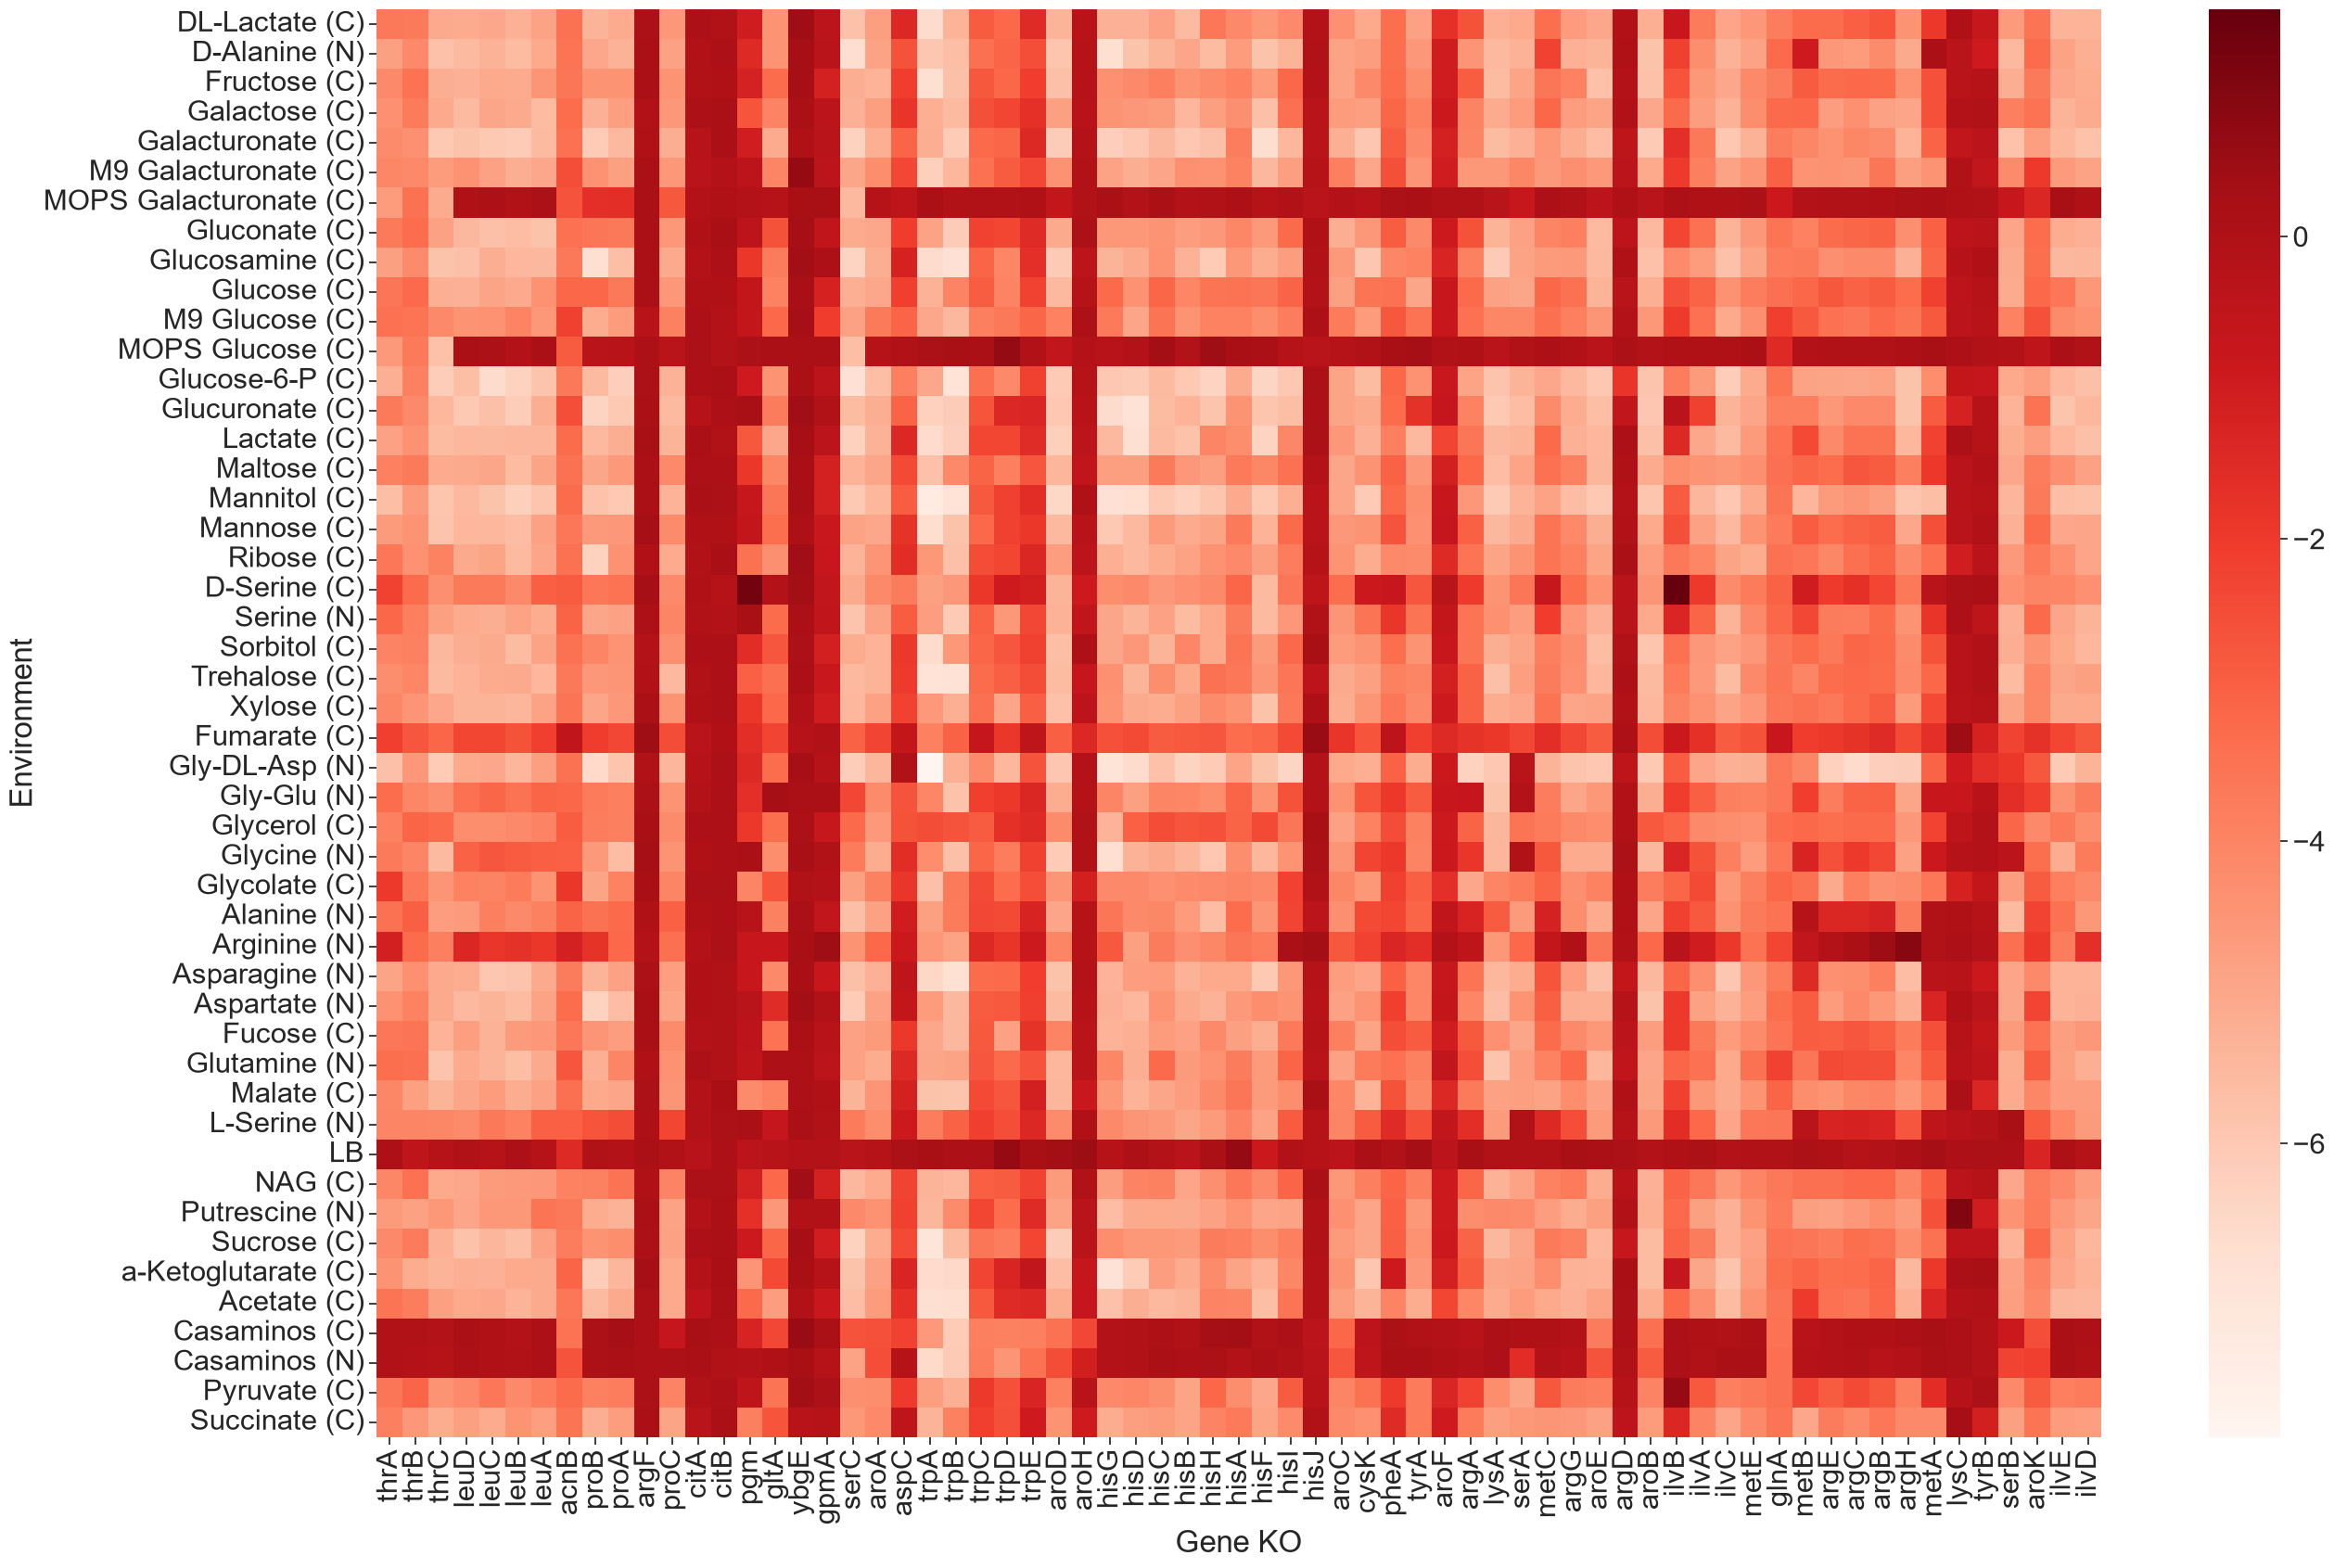

In [69]:
# Figure S4
column_rename = {'D,L-Lactate (C)': 'DL-Lactate (C)', 'D-Alanine (N)': 'D-Alanine (N)',
                 'D-Fructose (C)': 'Fructose (C)', 'D-Galactose (C)': 'Galactose (C)',
                 'D-Galacturonic Acid (C)': 'Galacturonate (C)','D-Galacturonic Acid (C) M9': 'M9 Galacturonate (C)',
                 'D-Galacturonic Acid (C) MOPS': 'MOPS Galacturonate (C)', 'D-Gluconic Acid (C)': 'Gluconate (C)',
                 'D-Glucosamine Hydrochloride (C)': 'Glucosamine (C)', 'D-Glucose (C)': 'Glucose (C)',
                 'D-Glucose (C) M9': 'M9 Glucose (C)','D-Glucose (C) MOPS': 'MOPS Glucose (C)',
                 'D-Glucose-6-Phosphate (C)': 'Glucose-6-P (C)', 'D-Glucuronic Acid (C)': 'Glucuronate (C)',
                 'D-Lactate (C)': 'Lactate (C)', 'D-Maltose (C)': 'Maltose (C)', 'D-Mannitol (C)': 'Mannitol (C)',
                 'D-Mannose (C)': 'Mannose (C)', 'D-Ribose (C)': 'Ribose (C)', 'succinate (C)': 'Succinate (C)',
                 'D-Serine (N)': 'Serine (N)', 'D-Sorbitol (C)': 'Sorbitol (C)', 'D-Trehalose (C)': 'Trehalose (C)',
                 'D-Xylose (C)': 'Xylose (C)', 'Glycolic Acid (C)': 'Glycolate (C)', 'L-Alanine (N)': 'Alanine (N)',
                 'L-Arginine (N)': 'Arginine (N)', 'L-Asparagine (N)': 'Asparagine (N)','L-Aspartic Acid (N)': 'Aspartate (N)',
                 'L-Fucose (C)': 'Fucose (C)', 'L-Glutamine (N)': 'Glutamine (N)', 'L-Malic (C)': 'Malate (C)',
                 'a-Ketoglutaric (C)': 'a-Ketoglutarate (C)', 'acetate (C)': 'Acetate (C)', 'casaminos (C)': 'Casaminos (C)',
                 'casaminos (N)': 'Casaminos (N)', 'pyruvate (C)': 'Pyruvate (C)'}

Wetmore_aux_df_ec = Wetmore_aux_df_ec.rename(columns=column_rename)

fig, ax = plt.subplots(1, 1, figsize=(30, 20))
sns.heatmap(data=Wetmore_aux_df_ec.set_index('gene')[Wetmore_aux_df_ec.set_index('gene').columns[3:]].T,
            yticklabels=1, xticklabels=1, cmap='Reds',)

ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO')

plt.savefig('images/FigS4A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

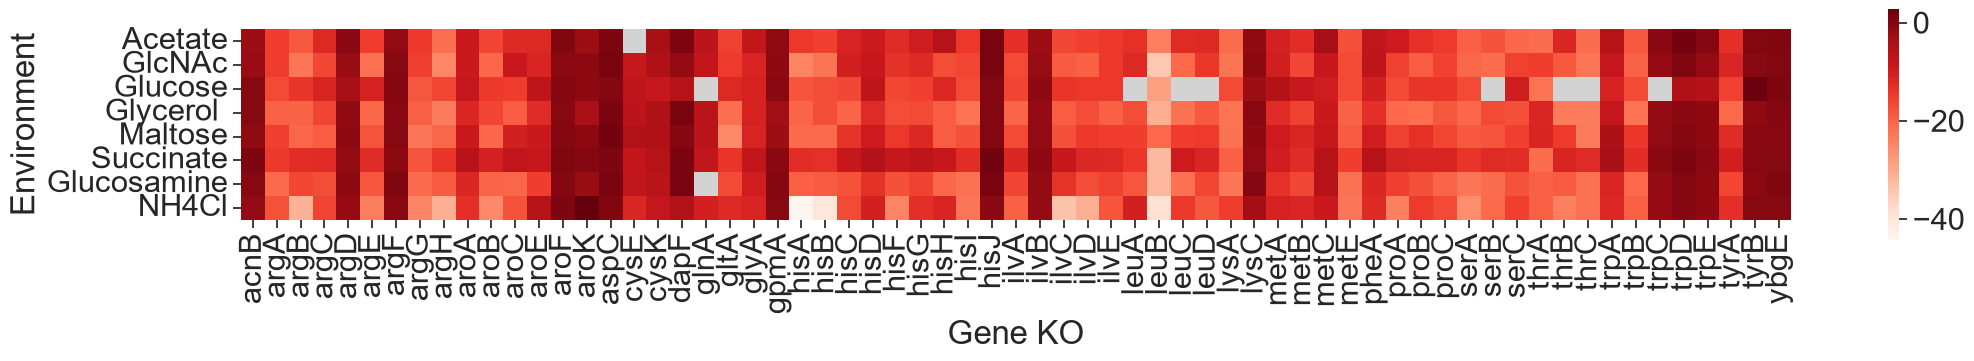

In [70]:
cmap_red = mpl.colormaps['Reds'].copy(); cmap_red.set_bad(('lightgrey'))

nichols_df = pd.read_excel("Data/Nichols et al Data.xlsx",
                               sheet_name="C_N_sources")
nichols_df["Gene"] = (nichols_df["Gene"].str[:-1].str.lower()
                      + nichols_df["Gene"].str[-1:].str.upper())
nichols_df.columns= nichols_df.columns.str.capitalize()

nichols_KO_data = nichols_df.copy()
nichols_KO_data = nichols_KO_data.rename(columns={'Gene':'gene', 'Nh4cl':'NH4Cl'})
nichols_KO_data[nichols_KO_data.columns[1:]] = nichols_KO_data[nichols_KO_data.columns[1:]].astype(float)

nichols_auxs = nichols_KO_data[(nichols_KO_data.gene.isin(ec_relevant_genes))].copy()

nichols_normalized = nichols_auxs.copy()
cols = nichols_normalized.columns[2:]
nichols_normalized[cols] = nichols_normalized[cols].apply(pd.to_numeric, errors="coerce")

nichols_df_auxs = nichols_normalized.copy()[((nichols_normalized[(nichols_normalized.columns[1:])] < 0).any(axis=1,))].copy()
nichols_df_auxs.rename(columns={'N-acetylglucosamine ':'GlcNAc'}, inplace=True)


# Figure S4
fig, ax = plt.subplots(1, 1, figsize=(25, 3))
sns.heatmap(data=nichols_df_auxs.set_index('gene').T[sorted(nichols_df_auxs.gene)],
            yticklabels=1, xticklabels=1, cmap=cmap_red, square=True)

ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO')
plt.savefig('images/FigS4B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

C:\Users\amich\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


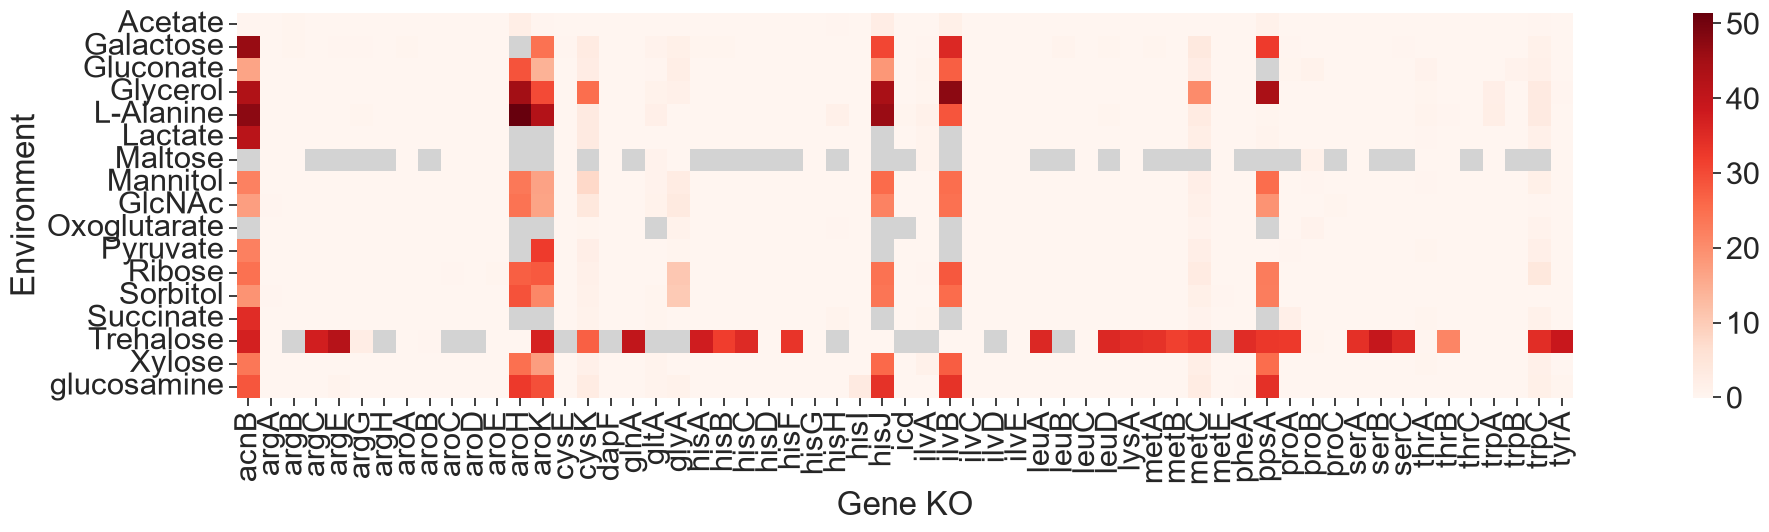

In [71]:
#Translate b_numbers to gene names
# BiGG Models API: iML1515 genes
data = requests.get("http://bigg.ucsd.edu/api/v2/models/iML1515/genes", timeout=30).json()
bigg_map = pd.DataFrame(data["results"])

bigg_map = bigg_map.rename(columns={"bigg_id": "b_number", "name": "gene_name"})

## Import Monk data, and add gene names
monk_df = pd.read_excel("Data/Monk et al 2017.xlsx",
                               sheet_name="Table 7")[["c_source","gene","upper asymptote"]]

monk_df=pd.merge(monk_df,bigg_map[['gene_name','b_number']], left_on='gene', right_on='b_number', how='left')
monk_df=monk_df[['c_source', 'upper asymptote', 'gene_name']].rename(columns={'gene_name':'gene'})

monk_KO_data = monk_df.copy()
monk_KO_data['upper asymptote'] = monk_KO_data['upper asymptote'].astype(float)
monk_KO_data = monk_KO_data[(monk_KO_data.gene.isin(ec_relevant_genes))]
monk_auxs = monk_KO_data.pivot(index='gene', columns='c_source', values='upper asymptote')
monk_auxs = monk_auxs.loc[monk_auxs.lt(1).any(axis=1)].copy()
monk_auxs.rename(columns={'N-acetyl-glucosamine':'GlcNAc'}, inplace=True)

# Figure S4C
fig, ax = plt.subplots(1, 1, figsize=(31, 5))
sns.heatmap(data=monk_auxs.T[sorted(monk_auxs.T.columns)],
            yticklabels=1, xticklabels=1, cmap=cmap_red, square=True)

ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO')
plt.savefig('images/FigS4C.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

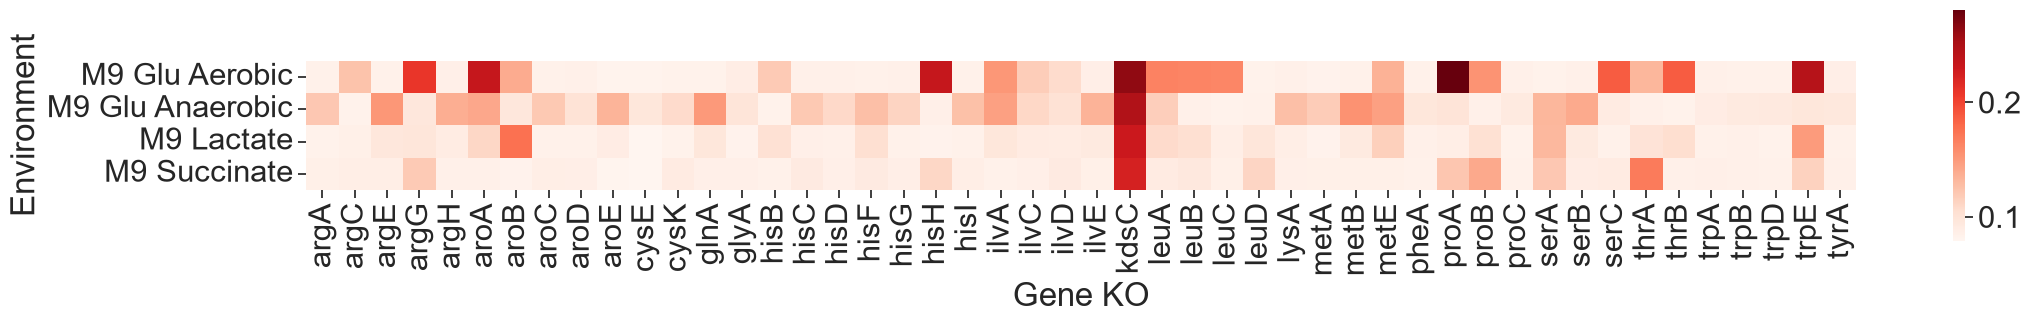

In [72]:
orth_df = pd.read_excel("Data/Orth et al 2011.xls", sheet_name="Table 1",
                        skiprows=1, usecols="B,I:P", index_col=0).astype(float).T
orth_df=orth_df.groupby(lambda col: col.replace(" plate 1", "").replace(" plate 2", "")).mean().T.reset_index()

orth_KO_data = orth_df[(orth_df.Gene.isin(ec_relevant_genes)) | (orth_df.Gene == 'kdsC')]
orth_KO_data = orth_KO_data[((orth_KO_data[(orth_KO_data.columns[1:])] < 0.1).any(axis=1)) | (orth_KO_data.Gene == 'kdsC')].copy()
orth_KO_data.rename(columns={'Glucose M9 aerobic':'M9 Glu Aerobic','Glucose M9 anaerobic':'M9 Glu Anaerobic',
                             'Succinate M9 aerobic':'M9 Succinate','Lactate M9 aerobic':'M9 Lactate',}, inplace=True)

orth_KO_data=orth_KO_data.set_index('Gene')

fig, ax = plt.subplots(1, 1, figsize=(25, 3))
sns.heatmap(data=orth_KO_data.T[sorted(orth_KO_data.T.columns)],
            yticklabels=1, xticklabels=1, cmap=cmap_red, square=True)

ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO')
plt.savefig('images/FigS4D.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

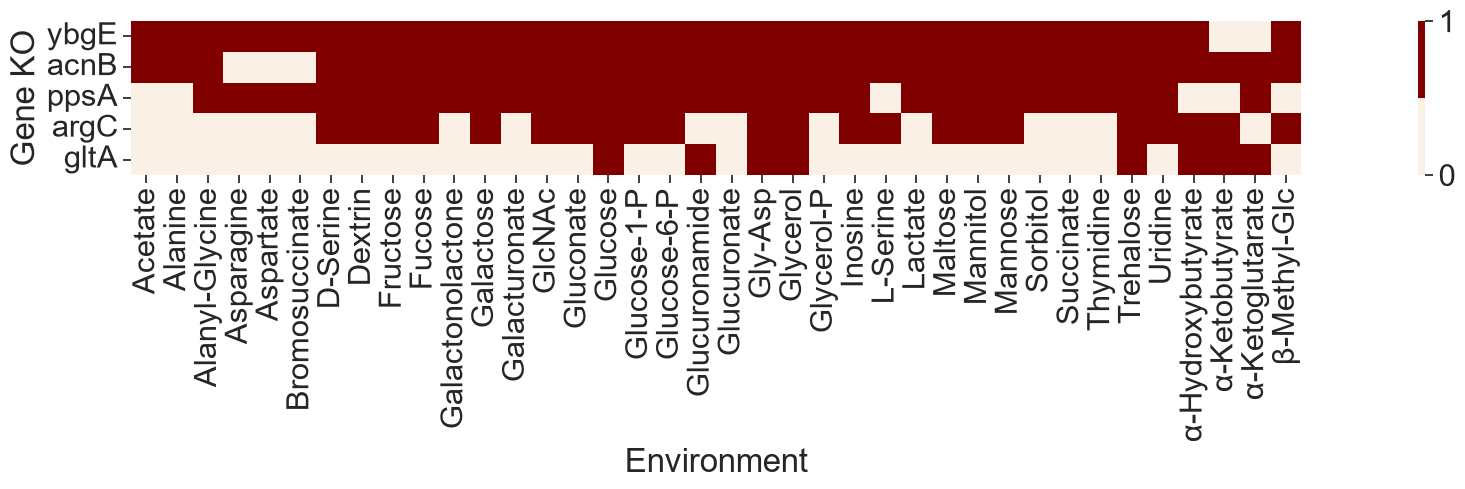

In [73]:
column_rename = {"Dextrin": "Dextrin","N-Acetyl-D-Glucosamine": "GlcNAc", "D-Fructose": "Fructose",
                 "L-Fucose": "Fucose", "D-Galactose": "Galactose", "D-Mannitol": "Mannitol", 
                 "D-Mannose": "Mannose", "β-Methyl-D-Glucoside": "β-Methyl-Glc","D-Sorbitol": "Sorbitol",
                 "D-Trehalose": "Trehalose", "α-D-Glucose": "Glucose","α-D-Glucose-1-Phosphate": "Glucose-1-P",
                 "D-Glucose-6-Phosphate": "Glucose-6-P", "Glycerol": "Glycerol", "D,L,α-Glycerol Phosphate": "Glycerol-P",
                 "D-Galactonic Acid Lactone": "Galactonolactone", "D-Galacturonic Acid": "Galacturonate",
                 "D-Gluconic Acid": "Gluconate", "D-Glucuronic Acid": "Glucuronate", "Acetic Acid": "Acetate",
                 "α-Hydroxybutyric Acid": "α-Hydroxybutyrate","α-Ketobutyric Acid": "α-Ketobutyrate", 
                 "α-Ketoglutaric Acid": "α-Ketoglutarate", "D,L-Lactic Acid": "Lactate","Succinic Acid": "Succinate", 
                 "Bromosuccinic Acid": "Bromosuccinate", "Glucuronamide": "Glucuronamide", "L-Alanine": "Alanine",
                 "L-Alanyl-Glycine": "Alanyl-Glycine", "L-Asparagine": "Asparagine", "L-Aspartic Acid": "Aspartate",
                 "Glycyl-L-Aspartic Acid": "Gly-Asp",}


ito_df = (pd.read_excel("Data/Ito et al 2005.xlsx")
          .drop(columns=['Cluster','Appearance in Supplemental Figure'])
          .rename(columns={"Gene name deleted":'Gene'}))

ito_KO_data = ito_df[(ito_df.Gene.isin(ec_relevant_genes)) | (ito_df.Gene == 'kdsC')]

ito_KO_data=ito_KO_data.set_index('Gene')
ito_KO_data = ito_KO_data.rename(columns=column_rename)

fig, ax = plt.subplots(1, 1, figsize=(30, 2))
sns.heatmap(data=ito_KO_data[sorted(ito_KO_data.columns)],
            yticklabels=1, xticklabels=1, cmap=mcolors.ListedColormap(["linen", "maroon"]),
            cbar_kws={"ticks": [0, 1]}, square=True)

ax.set_xlabel('Environment') ; ax.set_ylabel('Gene KO')

cbar = ax.collections[0].colorbar
cbar.set_ticklabels(["0", "1"])
plt.savefig('images/FigS4E.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

# Figure S5
Auxotroph growth without supplemented amino acids

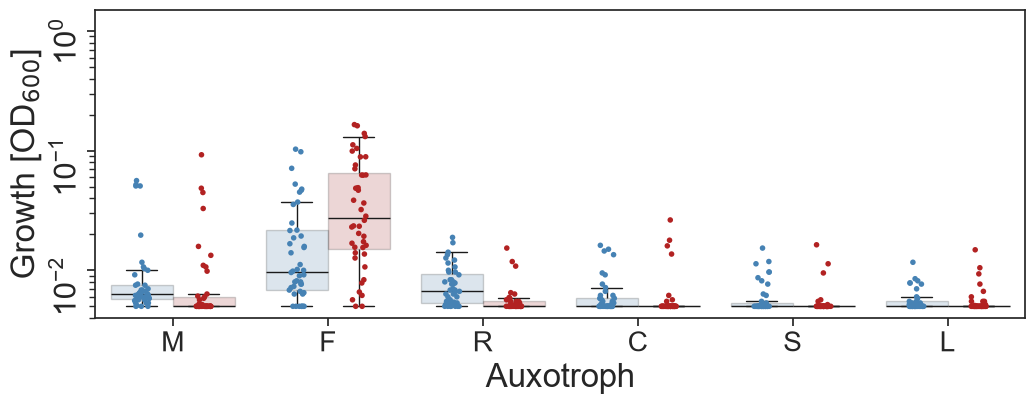

In [75]:
data=big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT'")
pair_order = ['M','F','R','C','S','L']


fig, ax = plt.subplots(1, 1, figsize=(12, 4))

sns.stripplot(data=data, x='Aux1', y='Mean', ax=ax, s=4, 
              hue='Species', palette=['steelblue','firebrick'],
              hue_order=['Bs', 'Ec'], legend=False, dodge=True,
              order= pair_order)

sns.boxplot(data=data, x='Aux1', y='Mean', ax=ax,
            hue='Species', palette=['steelblue','firebrick'], 
            hue_order=['Bs', 'Ec'], legend=False,
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},
            order= pair_order)


ax.set_yscale('log') ; ax.set_ylim(0.004,1.5)
ax.set_ylabel(r'Growth [OD$_{600}$]') ; ax.set_xlabel('Auxotroph')
ax.tick_params(axis="y", rotation=90)
ax.set_xticks(range(len(pair_order)), labels=pair_order,rotation=0, fontsize=20)

plt.savefig('images/FigS5.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figures S6

Unfiltered Datasets


In [77]:
#re-generate relvant dataframes from unfiltered data

bs_df_uf = big_norm_df.query("Species == 'Bs' and N != 'NoN' and Aux1 != Aux2").copy()
ec_df_uf = big_norm_df.query("Species == 'Ec' and N != 'NoN' and Aux1 != Aux2").copy()

comp_species_df_uf = pd.merge(bs_df_uf, ec_df_uf, 
                           on=['Environment', 'Pair', 'N', 'C', 'Aux1', 'Aux2'],
                           suffixes=['_Bs', '_Ec'])

# Supplemented monoculture dataframe across species
aa_dic = {}
for pair in ['WT+WT', 'M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_dic[pair] = big_df[big_df.Pair == pair].drop(columns=['Aux1', 'Aux2', 'SEM', 'C', 'N'])

comp_aa_df_uf = aa_dic["WT+WT"]
for pair in ['M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    comp_aa_df_uf = pd.concat([comp_aa_df_uf, aa_dic[pair]])

comp_aa_df_uf_b = pd.merge(comp_aa_df_uf.query("Species == 'Bs'"), 
                           comp_aa_df_uf.query("Species == 'Ec'"), 
                           on=['Environment', 'Pair'], suffixes=['_Bs', '_Ec'])

aa_long_uf = pd.merge(comp_aa_df_uf_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='Mean')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)),
                   comp_aa_df_uf_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='SEM')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)))

aa_long_uf[['Aux1', 'Aux2']] = aa_long_uf['Pair'].str.split("+", expand=True)
aa_long_uf[['N', 'C']] = aa_long_uf['Environment'].str.split("+", expand=True)
aa_long_uf['Mean'] = aa_long_uf['Mean'].astype(float)

# Crossfeeding long-form dataframe
df_long_uf = pd.merge((comp_species_df_uf.melt(id_vars=['Environment', 'Pair'], 
                                              value_vars=['Norm_mean_Bs', 'Norm_mean_Ec'],
                                              var_name='Species', value_name='Norm_mean')
                      .replace({"Norm_mean_Bs": "Bs", "Norm_mean_Ec": "Ec"})),
                      (comp_species_df_uf.melt(id_vars=['Environment', 'Pair'], 
                                              value_vars=['Norm_sem_Bs', 'Norm_sem_Ec'],
                                              var_name='Species', value_name='Norm_sem')
                      .replace({"Norm_sem_Bs": "Bs", "Norm_sem_Ec": "Ec"})))

df_long_uf[['Aux1', 'Aux2']] = df_long_uf['Pair'].str.split("+", expand=True)
df_long_uf['Norm_mean'] = df_long_uf['Norm_mean'].astype(float)

mean_by_env_df_uf =( big_norm_df.query("Aux1 != 'WT' and Aux1 != Aux2 and N != 'NoN'")
                    .groupby(['Environment', 'C', 'N', 'Species']).mean(numeric_only=True).reset_index())
mean_by_pair_df_uf = (big_norm_df.query("Aux1 != 'WT' and Aux1 != Aux2 and N != 'NoN'")
                      .groupby(['Pair', 'Aux1', 'Aux2', 'Species']).mean(numeric_only=True).reset_index())

comp_env_df_uf = pd.merge(mean_by_env_df_uf[mean_by_env_df_uf.Species == 'Bs'],
                       mean_by_env_df_uf[mean_by_env_df_uf.Species == 'Ec'],
                       on=['Environment', 'N', 'C'], suffixes=['_Bs', '_Ec'])

comp_pair_df_uf = pd.merge(mean_by_pair_df_uf[mean_by_pair_df_uf.Species == 'Bs'],
                        mean_by_pair_df_uf[mean_by_pair_df_uf.Species == 'Ec'],
                        on=['Pair', 'Aux1', 'Aux2'], suffixes=['_Bs', '_Ec'])

comp_pair_df_uf = comp_pair_df_uf[comp_pair_df_uf.Aux1 != 'WT'].copy()

cf_comp_pair_df_uf = comp_pair_df_uf[comp_pair_df_uf.Aux1 != 'WT'].copy()


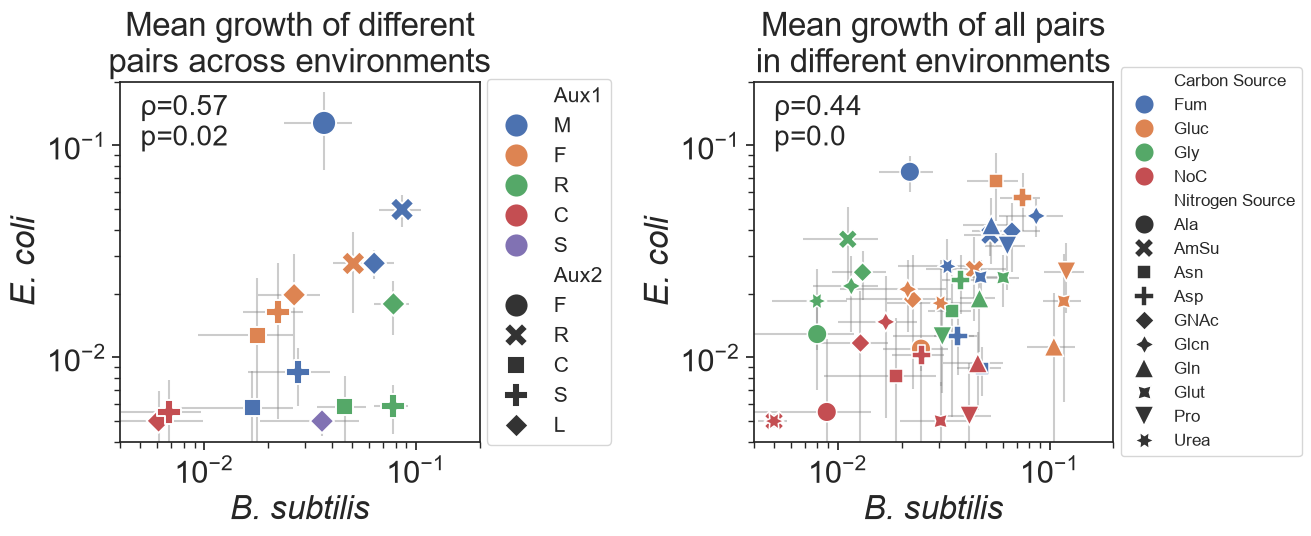

In [78]:
# Figure S6A
fig, axes = plt.subplots(1,2, figsize=(13,6), subplot_kw={'box_aspect': 1},
                         constrained_layout=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.05})


ax=axes[0]; ax.set_box_aspect(1)
data=cf_comp_pair_df_uf.query('Aux1!= Aux2')
sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="Aux1", hue_order=['M', 'F', 'R', 'C', 'S'],
                style="Aux2", style_order=['F', 'R', 'C', 'S', 'L'],
                ax=ax, legend="full", s=300, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

rho, rho_pval = sp.stats.spearmanr(data["Norm_mean_Bs"], data["Norm_mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of different\npairs across environments')
ax.legend( loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=15)
# ax.get_legend().remove()

###################################################################################################

ax=axes[1]; ax.set_box_aspect(1)
data=comp_env_df_uf.query("N != 'NoN'") 

sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="C", style="N", ax=ax, legend="full", s=200, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

# ax.plot(np.arange(0.001,0.3,0.002), np.arange(0.001,0.3,0.002), color='k', lw=0.8)

# r, r_pval = sp.stats.linregress(data["Mean_Bs"], data["Mean_Ec"])[2:4]

rho, rho_pval = sp.stats.spearmanr(data["Norm_mean_Bs"], data["Norm_mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of all pairs\nin different environments')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[6:],
          loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=12);

    
plt.savefig('images/FigS6A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


Pairs better than WT = 35
600
Pairs better than WT = 3
600
Total pairs better than WT = 38/1200 (3.2%)


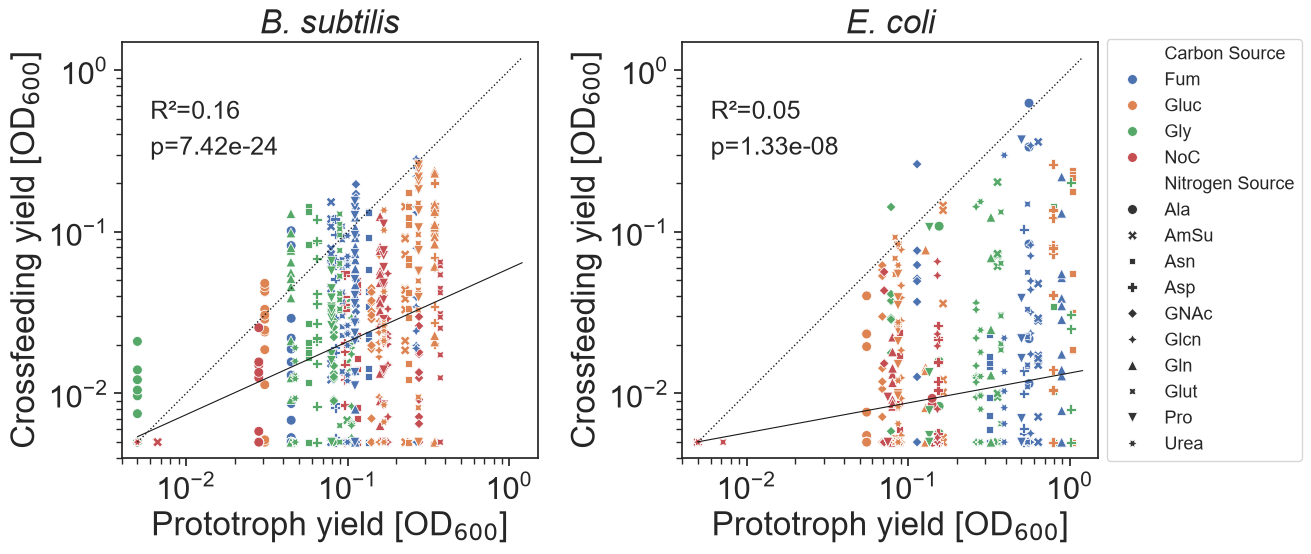

In [79]:
# Figure S6B
fig, axes = plt.subplots(1,2, figsize=(13,6), subplot_kw={'box_aspect': 1},
                         constrained_layout=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

for ax in axes:
    ax.set_box_aspect(1) # Sets the box aspect to be 1:1 (square)
    
title_dic={0:'B. subtilis',1:'E. coli'}

for x, data in enumerate([bs_df_uf,ec_df_uf]):
    ax = axes[x]
    data=data.query("Aux1 != 'WT' and N != 'NoN'")
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean",  data=data,
                    hue="C", style="N", ax=ax, s=50, zorder=1)
    
   
    # Apply log10
    x_log = np.log10(data["WT_mean"])
    y_log = np.log10(data["Norm_mean"])
    
    # Regression
    r = sp.stats.linregress(x_log, y_log)
    ax.text(0.006, 0.5, "R²="+str(((r.rvalue)**2).round(2)), fontsize=18)
    ax.text(0.006, 0.3, f"p={r.pvalue:.2e}", fontsize=18)
    
    x_vals = np.logspace(np.log10(0.005), np.log10(1.2), 10)
    y_vals = 10**(r.slope * np.log10(x_vals) + r.intercept)
    ax.plot(x_vals, y_vals, color='k', lw=0.8)
    ax.plot(x_vals, x_vals, color='k', lw=1, linestyle='dotted')
    
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Prototroph yield [OD$_{600}$]"); ax.set_ylabel("Crossfeeding yield [OD$_{600}$]")
    ax.set_xlim(0.004, 1.5); ax.set_ylim(0.004, 1.5)
    ax.set_title(title_dic[x], style='italic')

    if x==0:
        ax.get_legend().remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[6:],
                  loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=13);    
    
    print("Pairs better than WT = " + str(len((data[((data.Norm_mean-data.Norm_sem)>data.WT_mean)]))))
    print(str(len((data))))
    
crossfeeding_df = big_norm_df.query("Aux1 != 'WT' and Aux1 != Aux2 and N != 'NoN'").copy()
n_better = ((crossfeeding_df["Norm_mean"] - crossfeeding_df["Norm_sem"])> crossfeeding_df["WT_mean"]).sum()

print(f"Total pairs better than WT = {n_better}/{len(crossfeeding_df)} "
      f"({n_better / len(crossfeeding_df) * 100:.1f}%)")

plt.savefig('images/FigS6B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S7: Cross-feeding varies widely across conditions- disaggregated data

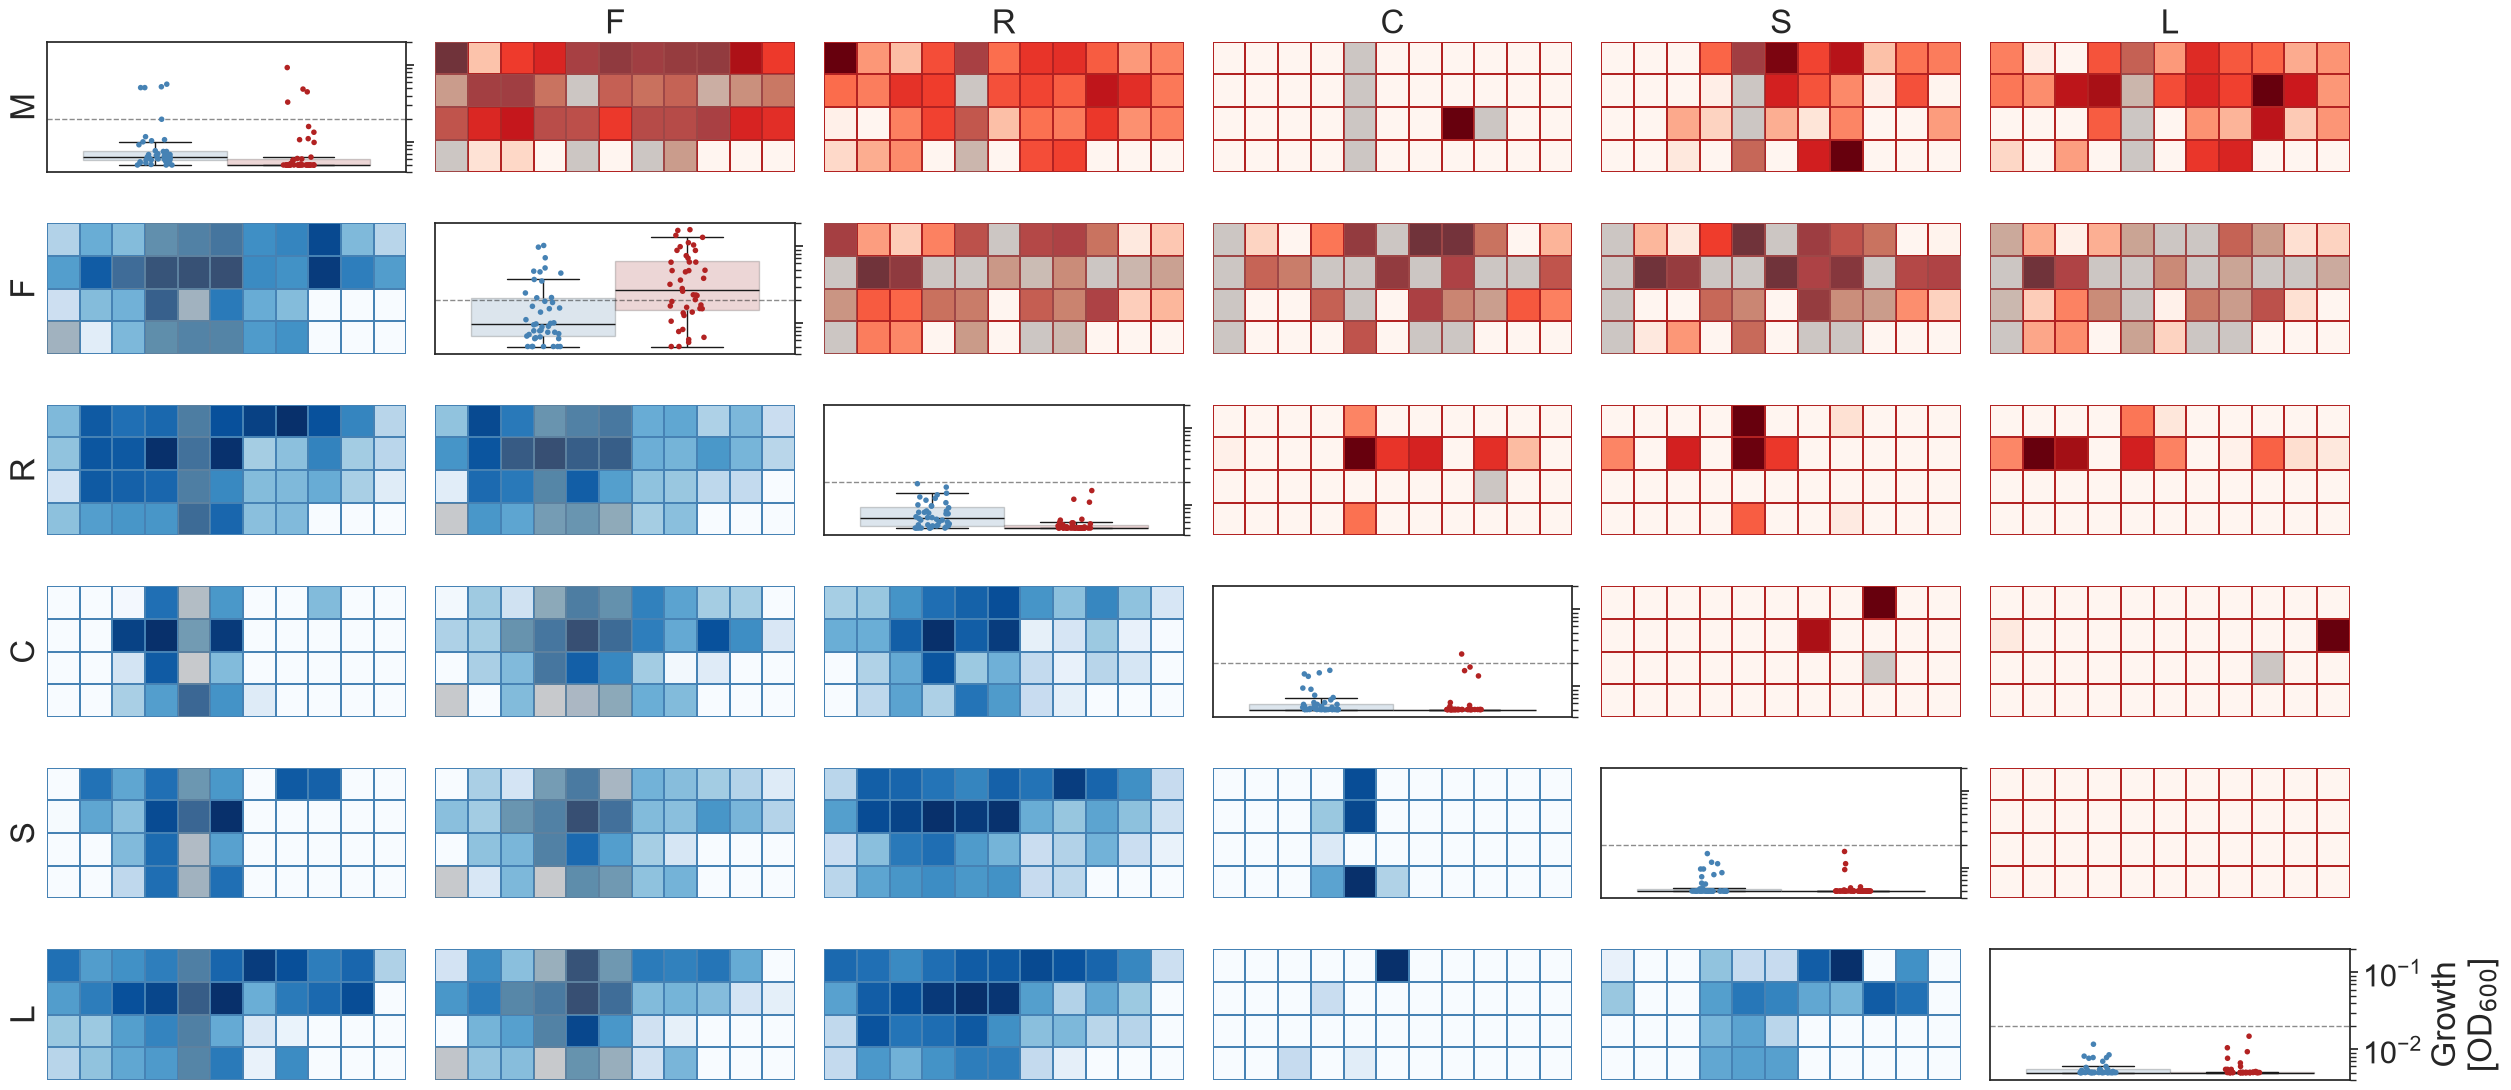

In [81]:
# Figure S7A

# colormaps
cmap_blue = mpl.colormaps['Blues'].copy() ; cmap_red = mpl.colormaps['Reds'].copy()
cmap_blue.set_bad(('lightgrey')) ; cmap_red.set_bad('lightgrey')

graph_order=dict(zip(list(range(0,40)),
                     list(itertools.product(['M','F','R', 'C', 'S', 'L'],
                                            ['M','F','R', 'C', 'S', 'L']))))

C_order = ['Fum', 'Gluc', 'Gly', 'NoC']                 
N_order = ['Ala',  'Asn', 'Asp', 'Glut', 'Gln', 'Pro',
           'GNAc', 'Glcn', 'AmSu', 'Urea', 'NoN',] 

fig, axes = plt.subplots(6, 6, figsize=(25, 11),  constrained_layout=True,
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
for pair in graph_order.keys():
    
    row = pair // 6 ; col = pair % 6
    ax = axes[row, col]
    
    if row <= col:
        aux1=graph_order[pair][0]
        aux2=graph_order[pair][1]
    else:
        aux1=graph_order[pair][1]
        aux2=graph_order[pair][0]
        
    
    if col == row:
        temp=big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2")

        sns.stripplot(data=temp, x='Pair', y='Mean', ax=ax, s=4, 
                      hue='Species', palette=['steelblue','firebrick'],
                      hue_order=['Bs', 'Ec'], legend=False, dodge=True)        
        sns.boxplot(data=temp, x='Pair', y='Mean', ax=ax, 
                    hue='Species', palette=['steelblue','firebrick'], 
                    hue_order=['Bs', 'Ec'], legend=False,
                    fliersize=0, linecolor="k", boxprops={'alpha':0.2})
        
        ax.set_yscale('log') ; ax.set_ylim(0.004,0.2)
        ax.set_ylabel(''); ax.set_xlabel('')
        ax.tick_params(axis="x", rotation=90)
        ax.axhline(0.02, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_box_aspect(4/11)
        
        # draw ticks/labels inward so they stay inside the axes box
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
                           
        if col == 5:
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
            ax.tick_params(axis='y', which='both', right=True, labelright=True,
                           left=False, labelleft=False)   
            ax.set_ylabel('Growth\n'+r'[OD$_{600}$]')


        elif col == 0:
            ax.set_ylabel(aux2)
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False)
            ax.tick_params(axis='y', which='both', right=True, labelright=False,
                           left=False, labelleft=False) 

        else:
            ax.yaxis.set_label_position("right")
            ax.set_yticklabels([])
            ax.tick_params(axis='y', which='both', right=True, labelright=False,
                           left=False, labelleft=False) 
        continue
        
    if col > row:
        temp_vals = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
                     .pivot(index='C', columns='N', values='Norm_mean')
                     .reindex(index=C_order, columns=N_order))
        
        temp_mask = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
                     .pivot(index='C', columns='N', values='filtered_out')
                     .reindex(index=C_order, columns=N_order))

                
        sns.heatmap(temp_vals, cmap='Reds', vmax=0.6, vmin=0.005, square=True, 
                    linewidths=0.005, linecolor='firebrick', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        
         # overlay gray boxes where filtered_out == True
        for y in range(temp_mask.shape[0]):
            for x in range(temp_mask.shape[1]):
                if temp_mask.iloc[y, x]:
                    ax.add_patch(Rectangle((x, y), 1, 1,facecolor='gray',edgecolor='none',alpha=0.4,zorder=10))        
                        
        ax.set_ylabel(''); ax.set_xlabel('')
        if row == 0:
            ax.set_title(aux2)
        continue
        
    if col < row:
        temp_vals = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
                     .pivot(index='C', columns='N', values='Norm_mean')
                     .reindex(index=C_order, columns=N_order))
        
        temp_mask = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
                     .pivot(index='C', columns='N', values='filtered_out')
                     .reindex(index=C_order, columns=N_order))

                
        sns.heatmap(temp_vals, cmap='Blues', vmax=0.3, vmin=0.005, square=True, 
                    linewidths=0.005, linecolor='steelblue', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        
         # overlay gray boxes where filtered_out == True
        for y in range(temp_mask.shape[0]):
            for x in range(temp_mask.shape[1]):
                if temp_mask.iloc[y, x]:
                    ax.add_patch(Rectangle((x, y), 1, 1,facecolor='gray',edgecolor='none',alpha=0.4,zorder=10))
        
        ax.set_ylabel(''); ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel(aux2);  


plt.savefig('images/FigS7A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

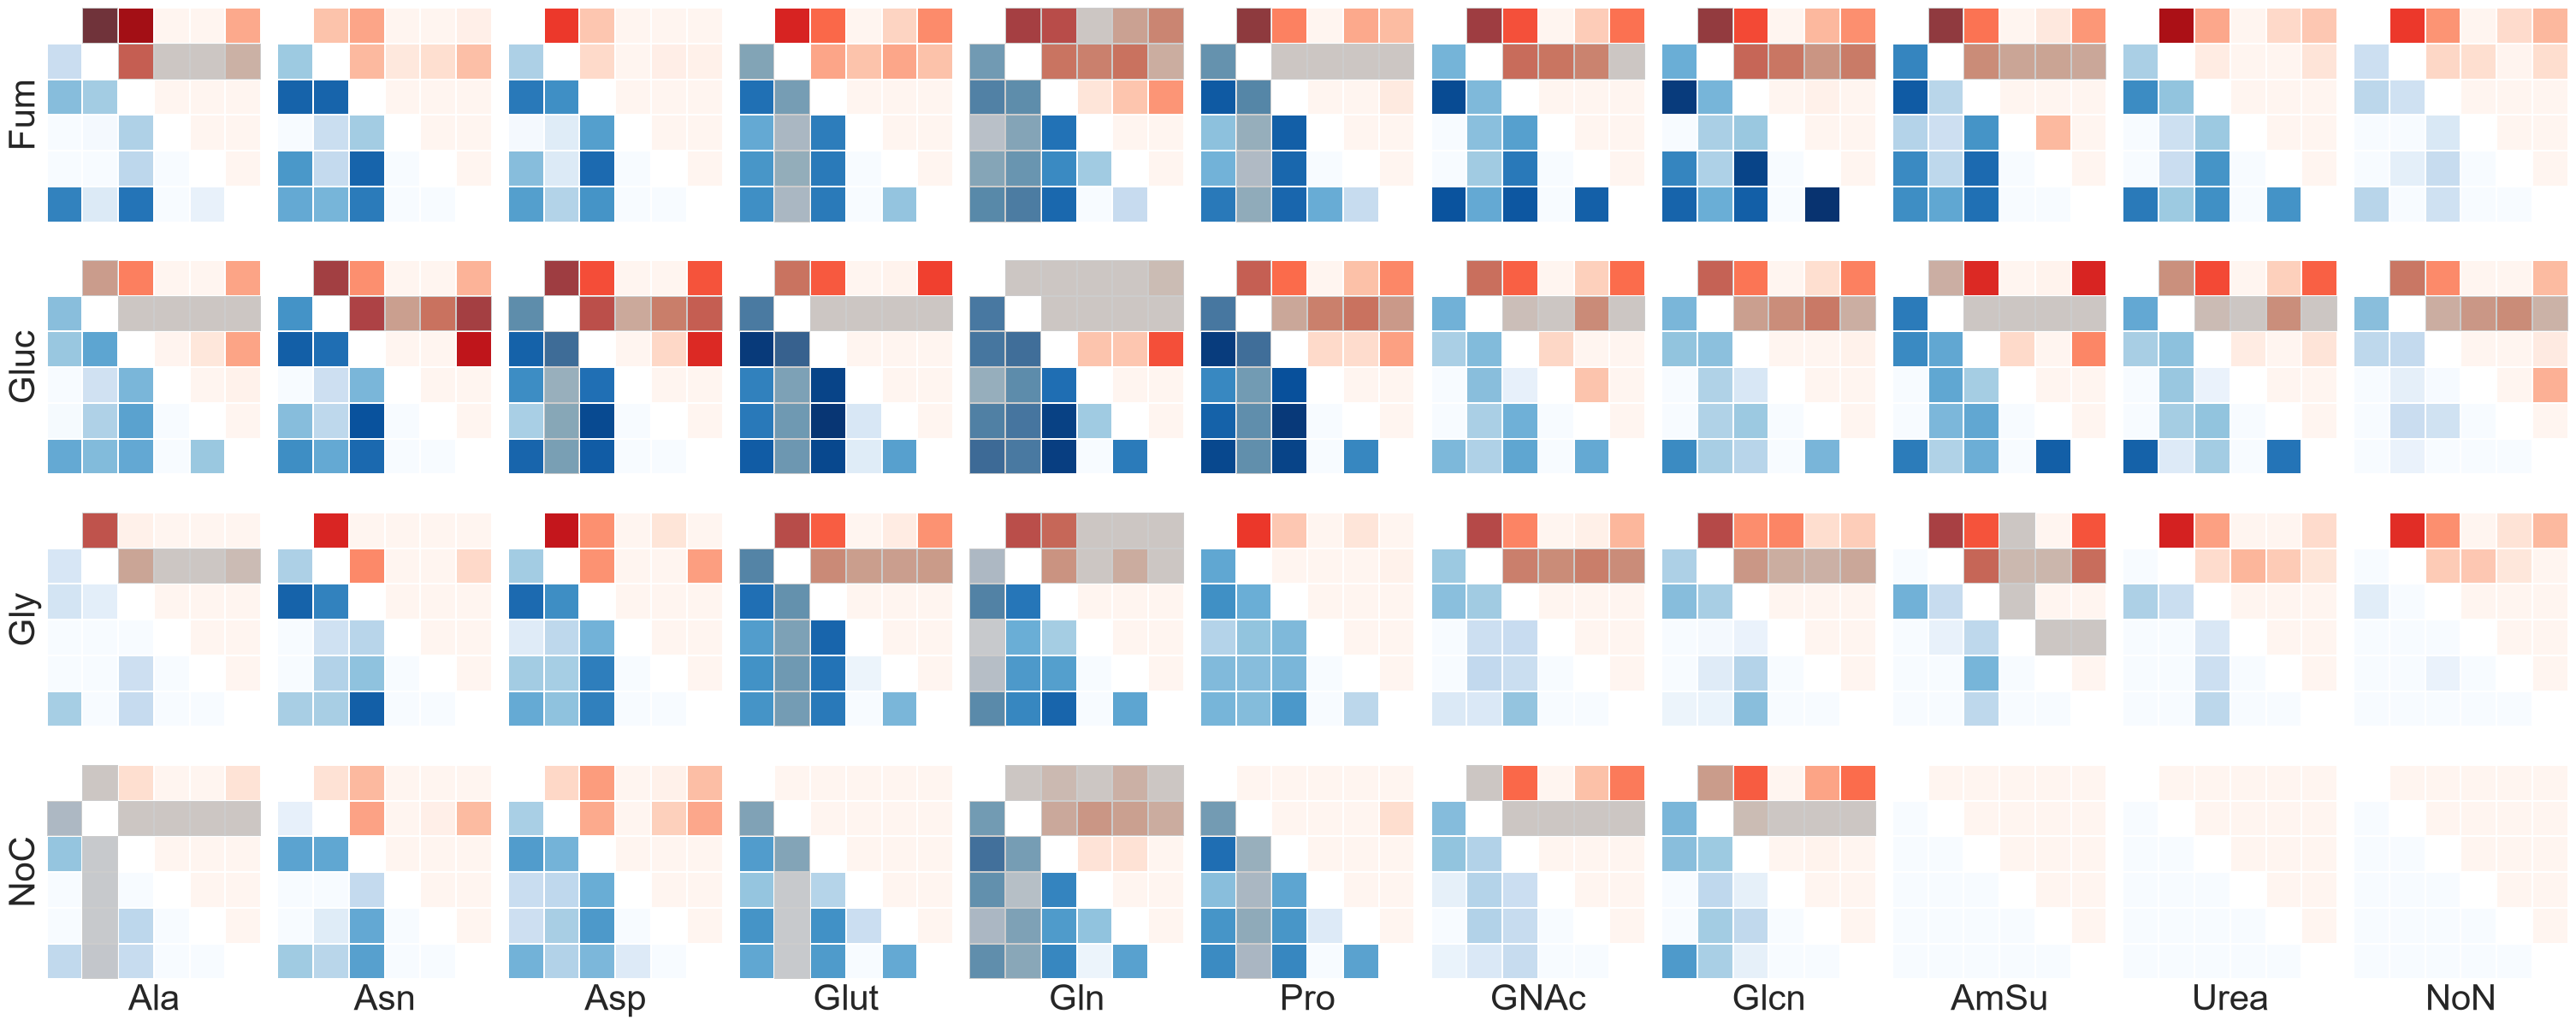

In [82]:
# Figure S7B

cmap_blue_triangle = cmap_blue.copy()
cmap_red_triangle = cmap_red.copy()

# Masked cells must be transparent so the two heatmaps can overlap
cmap_blue_triangle.set_bad((0, 0, 0, 0))
cmap_red_triangle.set_bad((0, 0, 0, 0))

graph_order = dict(zip(list(range(0,44)),
                       list(itertools.product(['Fum', 'Gluc', 'Gly', 'NoC'],
                                              ['Ala', 'Asn', 'Asp', 'Glut',
                                               'Gln', 'Pro', 'GNAc', 'Glcn',
                                               'AmSu', 'Urea', 'NoN']))))

pair_order = ['M','F','R','C','S','L']

fig, axes = plt.subplots(4, 11, figsize=(30, 12), constrained_layout=True,
                         gridspec_kw={'wspace': 0.07, 'hspace': 0.07})

for x in graph_order.keys():
    
    row = x // 11; col = x % 11
    ax = axes[row, col]
    env = graph_order[x][1] + " + " + graph_order[x][0]
    
    # Bs in lower triangle - values
    bs_lower = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Bs'")
                .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
                .reindex(index=pair_order, columns=pair_order).astype(float))

    # Bs overlay mask
    bs_overlay = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Bs'")
                  .pivot(columns='Aux1', index='Aux2', values='filtered_out')
                  .reindex(index=pair_order, columns=pair_order).fillna(False).astype(bool))

    # Ec in upper triangle - values
    ec_upper = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Ec'")
                .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
                .reindex(index=pair_order, columns=pair_order).astype(float).T)

    # Ec overlay mask
    ec_overlay = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Ec'")
                  .pivot(columns='Aux1', index='Aux2', values='filtered_out')
                  .reindex(index=pair_order, columns=pair_order).fillna(False).astype(bool).T)
    
    # mask everything except lower triangle for Bs
    mask_bs = np.triu(np.ones(bs_lower.shape, dtype=bool), k=0)
    # mask everything except upper triangle for Ec
    mask_ec = np.tril(np.ones(ec_upper.shape, dtype=bool), k=0)
    
    # plot blue lower triangle
    sns.heatmap(bs_lower, mask=mask_bs, cmap=cmap_blue_triangle, norm=LogNorm(vmin=0.005, vmax=0.3), 
                xticklabels=0, yticklabels=0, square=True, linewidths=0.1, cbar=False, ax=ax)
    
    # plot red upper triangle
    sns.heatmap(ec_upper, mask=mask_ec, cmap=cmap_red_triangle, norm=LogNorm(vmin=0.005, vmax=0.6), 
                xticklabels=0, yticklabels=0, square=True, linewidths=0.1, cbar=False, ax=ax)

    # gray overlay for Bs lower triangle
    for y in range(bs_overlay.shape[0]):
        for xx in range(bs_overlay.shape[1]):
            if bs_overlay.iloc[y, xx] and y > xx:
                ax.add_patch(Rectangle((xx, y), 1, 1, facecolor='gray', edgecolor='none', alpha=0.4, zorder=10))

    # gray overlay for Ec upper triangle
    for y in range(ec_overlay.shape[0]):
        for xx in range(ec_overlay.shape[1]):
            if ec_overlay.iloc[y, xx] and y < xx:
                ax.add_patch(Rectangle((xx, y), 1, 1,facecolor='gray', edgecolor='none', alpha=0.4, zorder=10))
    
    if col == 0:
        ax.set_ylabel(graph_order[x][0], fontsize=30)
    else:
        ax.set_ylabel('')

    if row == 3: 
        ax.set_xlabel(graph_order[x][1], fontsize=30)
    else:
        ax.set_xlabel('')
    
plt.savefig('images/FigS7B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

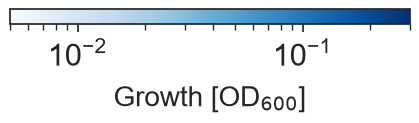

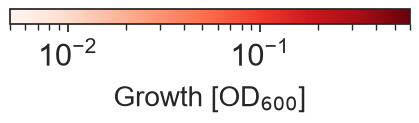

In [83]:
# Figure S7 colorbars
plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.3]]), cmap="Blues", norm=LogNorm(vmin=0.005, vmax=0.3))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)
plt.savefig('images/FigS7_blue_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.6]]), cmap="Reds", norm=LogNorm(vmin=0.005, vmax=0.6))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

plt.savefig('images/FigS7_red_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


### Figure S8 High variation still in growth after normalization to prototroph growth

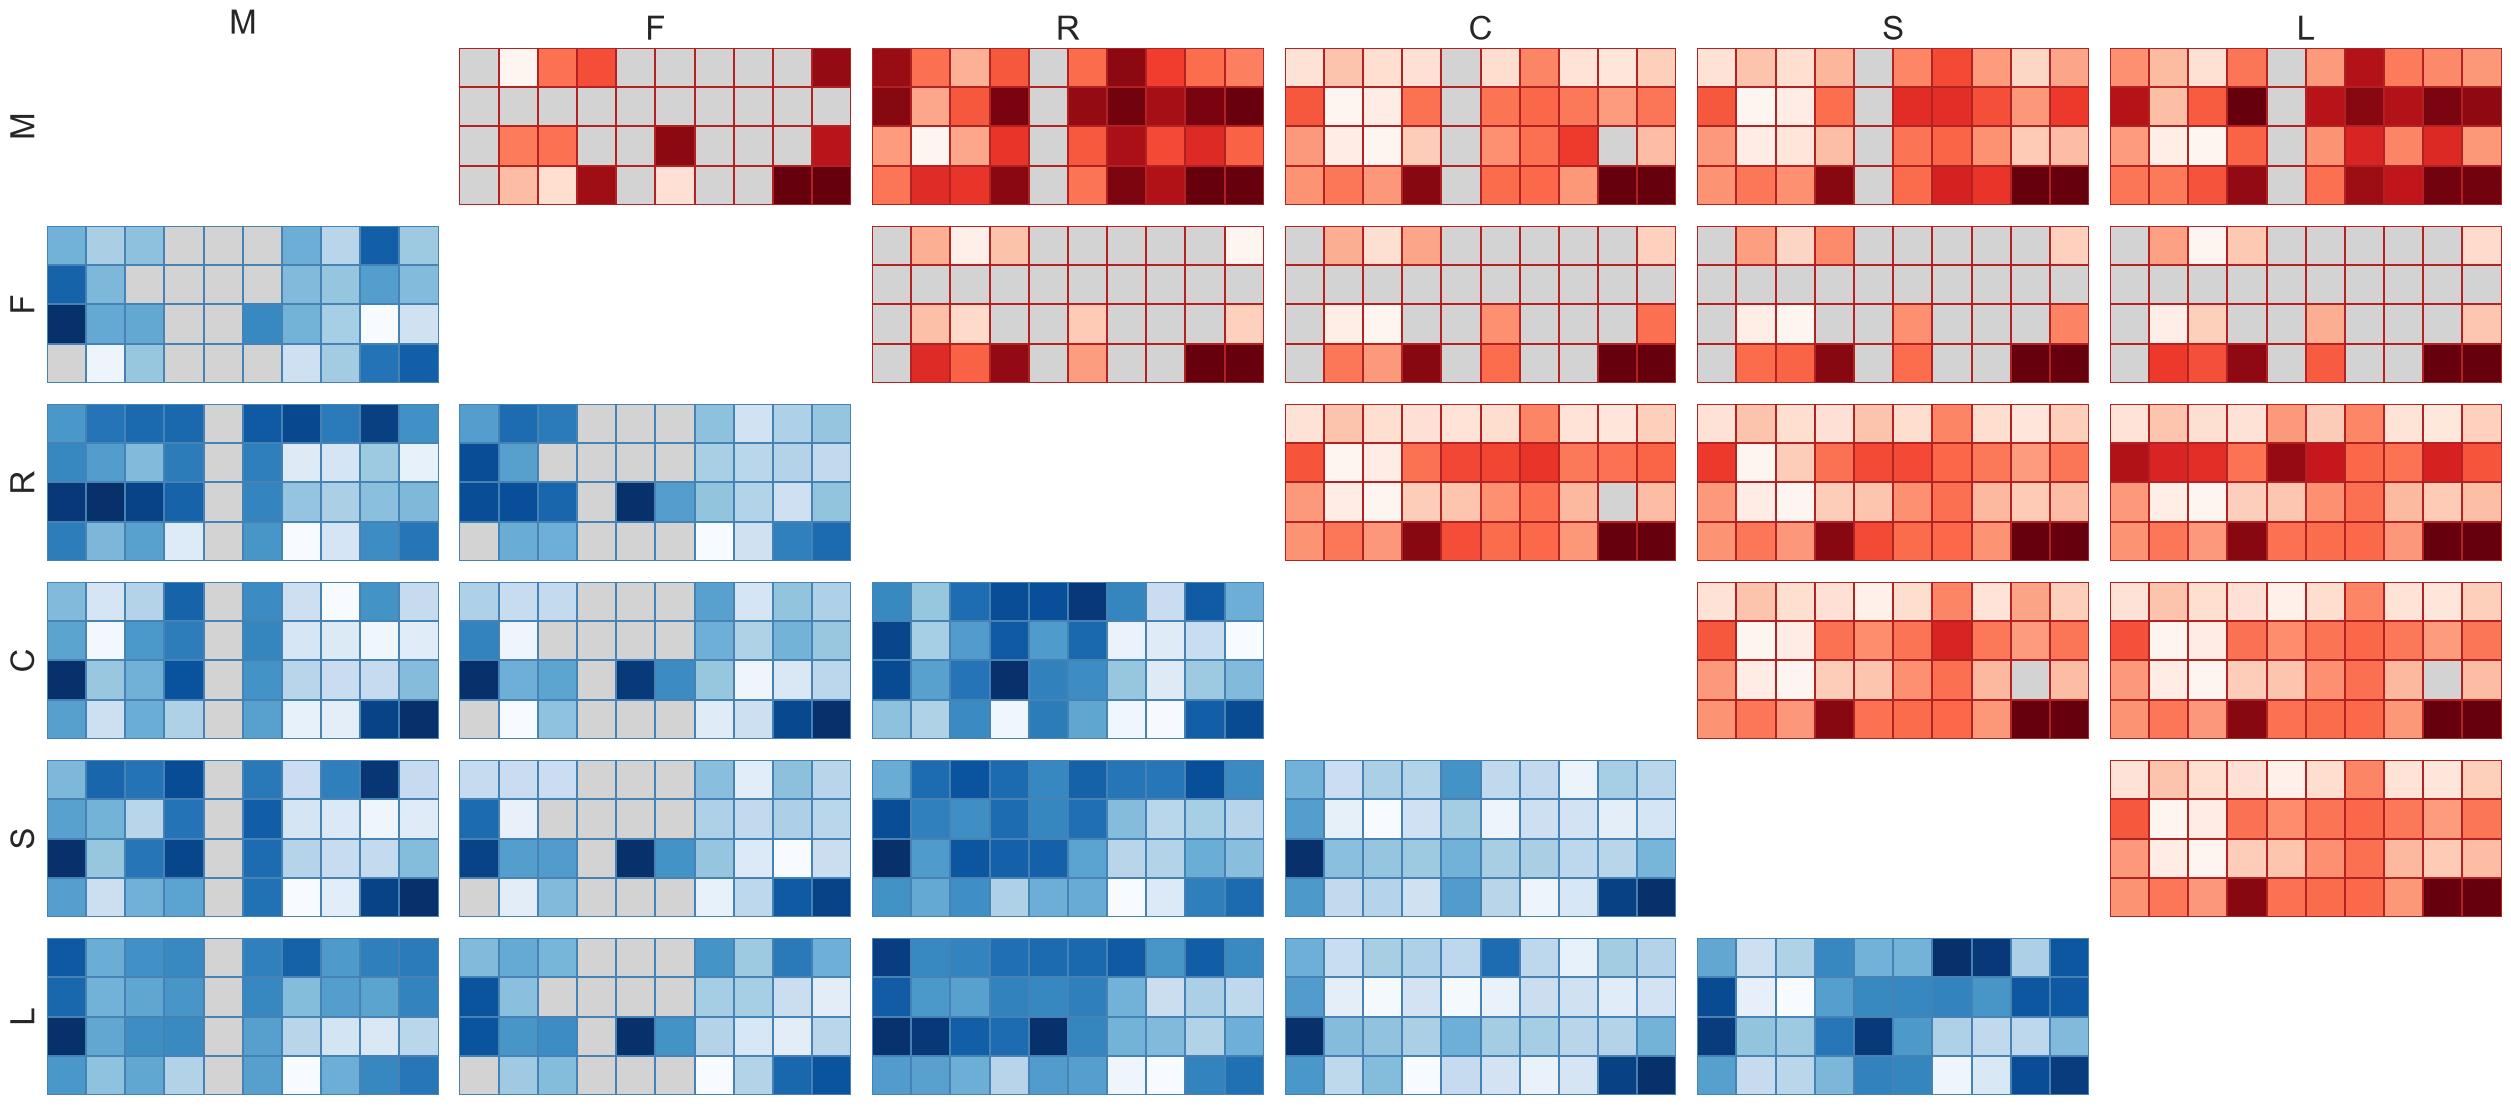

In [85]:
# Figure S8

cmap_red = mpl.colormaps['Reds'].copy(); cmap_blue = mpl.colormaps['Blues'].copy()
cmap_red.set_bad('lightgray'); cmap_blue.set_bad('lightgray')


graph_order=dict(zip(list(range(0,40)),
                     list(itertools.product(['M','F','R', 'C', 'S', 'L'],
                                            ['M','F','R', 'C', 'S', 'L']))))

C_order = ['Fum', 'Gluc', 'Gly', 'NoC']                 
N_order = ['Ala',  'Asn', 'Asp', 'Glut', 'Gln', 'Pro',
           'GNAc', 'Glcn', 'AmSu', 'Urea',] 

fig, axes = plt.subplots(6, 6, figsize=(25, 11),  constrained_layout=True,
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
for pair in graph_order.keys():
    
    row = pair // 6 ; col = pair % 6
    ax = axes[row, col]
    
    if row <= col:
        aux1=graph_order[pair][0]
        aux2=graph_order[pair][1]
    else:
        aux1=graph_order[pair][1]
        aux2=graph_order[pair][0]
        
    
    if col == row:
        ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
        ax.tick_params(left=False, bottom=False)
        ax.tick_params(labelleft=False, labelbottom=False)
        if col == 0:
            ax.set_title(aux2)
            ax.set_ylabel(aux2)

        
    if col > row:
        temp_norm=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
              .pivot(index='C', columns='N', values='Norm_mean')
              .reindex(index=C_order, columns=N_order))

        temp_WT=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
              .pivot(index='C', columns='N', values='WT_mean')
              .reindex(index=C_order, columns=N_order))

        sns.heatmap(temp_norm/temp_WT, cmap=cmap_red, vmin=0.04, vmax=3, square=True, 
                    linewidths=0.005, linecolor='firebrick', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        ax.set_ylabel(''); ax.set_xlabel('')
        if row == 0:
            ax.set_title(aux2)
        continue
        
    if col < row:
        temp_norm=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
              .pivot(index='C', columns='N', values='Norm_mean')
              .reindex(index=C_order, columns=N_order))

        temp_WT=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
              .pivot(index='C', columns='N', values='WT_mean')
              .reindex(index=C_order, columns=N_order))

        sns.heatmap(temp_norm/temp_WT, cmap=cmap_blue, vmin=0.04, vmax=3, square=True,
                    linewidths=0.005, linecolor='steelblue', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        ax.set_ylabel(''); ax.set_xlabel('')

        if col == 0:
            ax.set_ylabel(aux2);

plt.savefig('images/FigS8.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


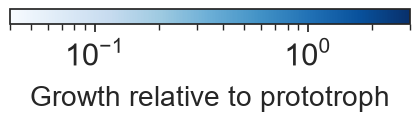

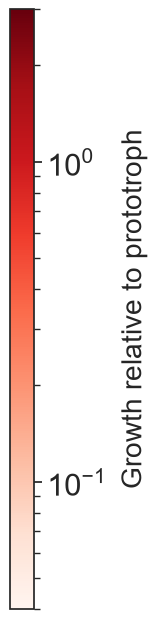

In [86]:
# Figure S8 colorbars
plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.004, 4]]), cmap="Blues", norm=LogNorm(vmin=0.04, vmax=3))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label('Growth relative to prototroph', fontsize=20, labelpad=10)
plt.savefig('images/FigS8_blue_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


# Vertical colorbar
plt.figure(figsize=(0.3, 20))
img = plt.imshow(np.array([[0.004, 3]]), cmap="Reds", norm=LogNorm(vmin=0.04, vmax=3))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="vertical")
cb.set_label('Growth relative to prototroph', fontsize=20, labelpad=10)
plt.savefig('images/FigS8_red_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 

# Figure S9 Amino acid requirments

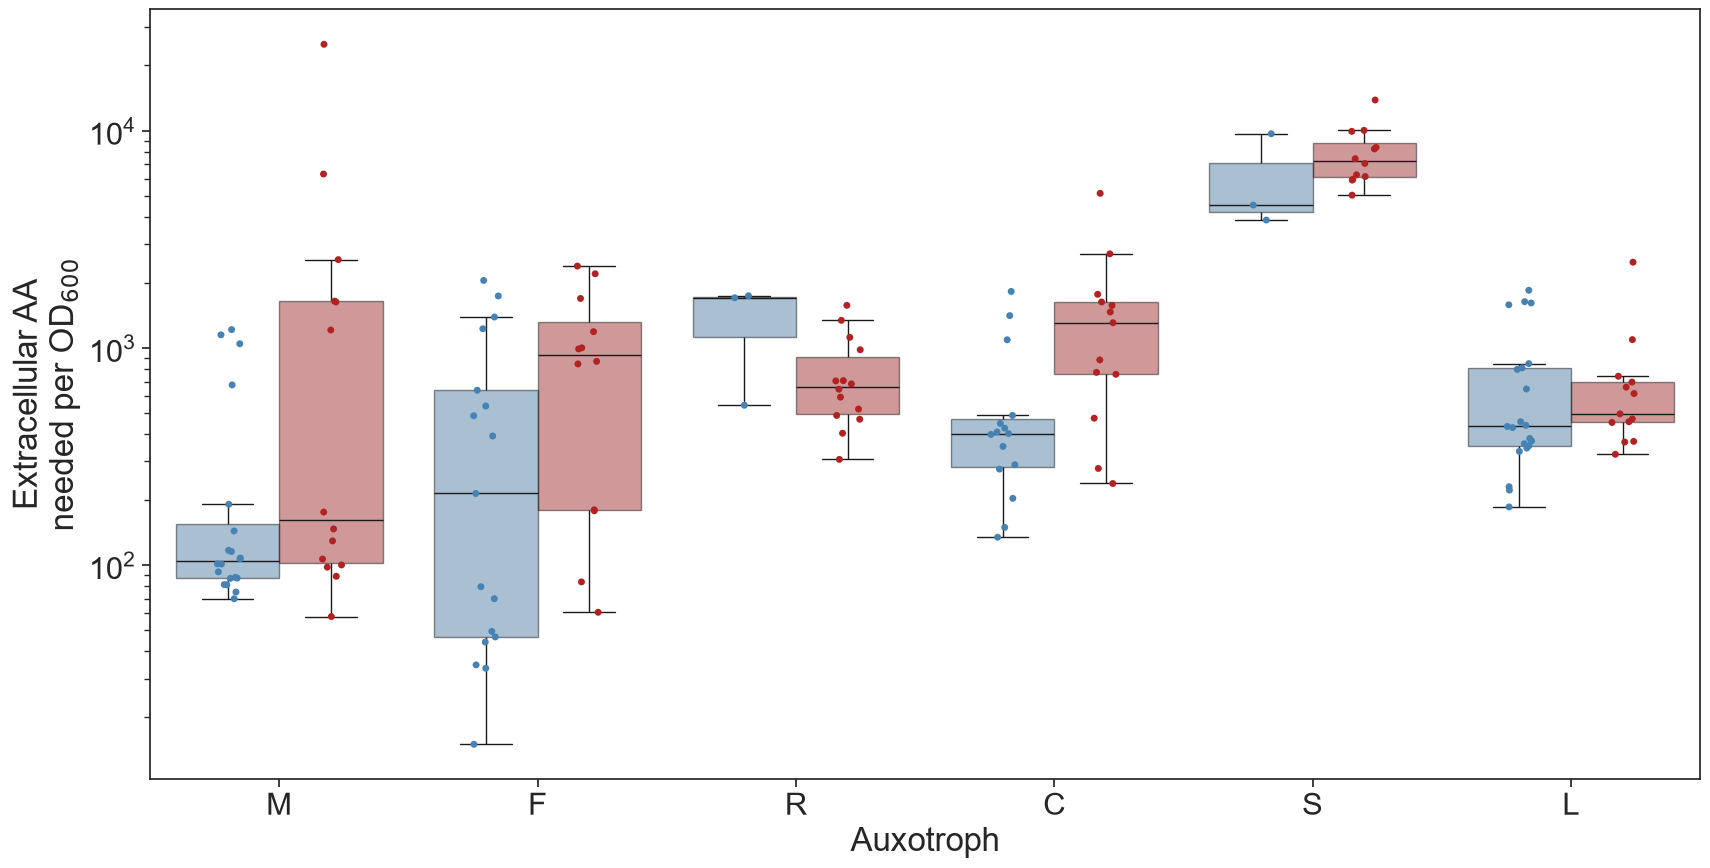

In [88]:
fig, axes = plt.subplots(1,1, figsize=(20,10))
 
g=sns.stripplot(data=aa_requirments_dataset, x='Aux', y='aa_per_od', s=5, hue='Species', 
                dodge=True, palette=['steelblue','firebrick'], legend=False,
                order=["M", "F", "R", "C", "S", "L"])

g=sns.boxplot(data=aa_requirments_dataset, x='Aux', y='aa_per_od', legend=False, hue='Species', dodge=True,
              palette=['steelblue','firebrick'], boxprops=dict(alpha=0.5), 
              fliersize=0, linecolor="k",)

g.set_yscale('log')
g.set_ylabel('Extracellular AA\nneeded per OD$_{600}$')
g.set_xlabel('Auxotroph');

plt.savefig('images/FigS9.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S10. Random forest model performance and feature importance

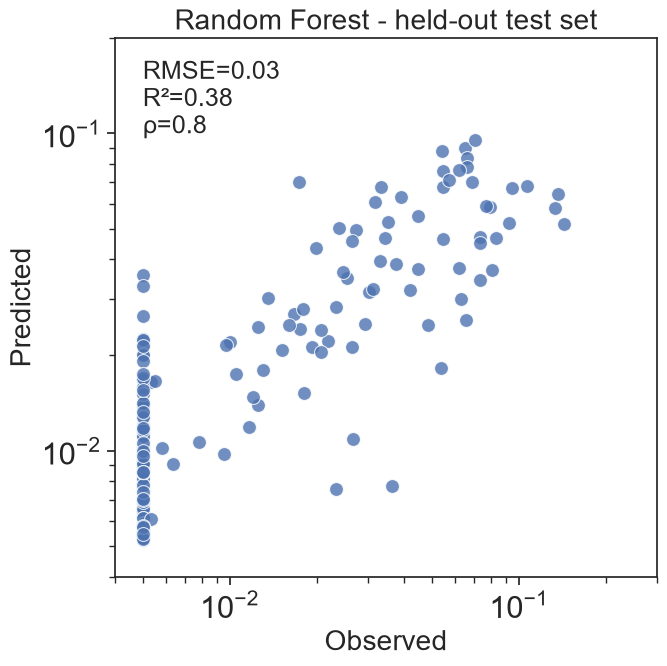

In [90]:
# Figure S10A
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

sns.scatterplot(x=y_test, y=pred_test, s=100, zorder=1, alpha=0.8)


ax.text(0.005, 0.1, (f"RMSE={round(rmse_test,2)}"+"\n"+
                     f"R²={round(r2_test,2)}"+"\n"+
                     f"ρ={round(spearmanr(y_test, pred_test).correlation,2)}"), fontsize=18)


ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.3); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("Observed", fontsize=20); ax.set_ylabel("Predicted", fontsize=20)
ax.set_title('Random Forest - held-out test set', fontsize=20)
plt.savefig('images/FigS10A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


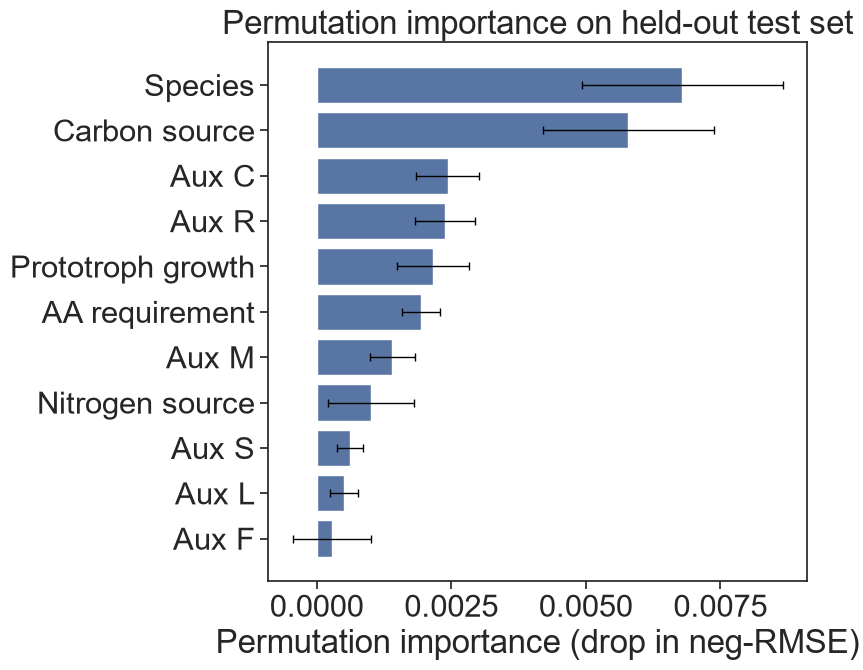

In [91]:
# Figure S10B
label_map = {"WT_mean": "Prototroph growth","pair_aa_requirement": "AA requirement",
             "Aux_R": "Aux R", "Aux_M": "Aux M", "Aux_L": "Aux L",
             "Aux_F": "Aux F", "Aux_C": "Aux C", "Aux_S": "Aux S",
             "C":"Carbon source","N":"Nitrogen source"}

perm_test_df["feature_label"] = perm_test_df["feature"].replace(label_map)


fig, ax = plt.subplots(1,1, figsize=(10,7), subplot_kw={'box_aspect': 1})
ax = sns.barplot(data=perm_test_df, y="feature_label",x="importance_mean",
                 orient="h")

ax.errorbar(x=perm_test_df["importance_mean"], y=range(len(perm_test_df)),
            xerr=perm_test_df["importance_std"], fmt="none",
            capsize=3, color="black", linewidth=1)

ax.set_xlabel("Permutation importance (drop in neg-RMSE)")
ax.set_ylabel("")
ax.set_title("Permutation importance on held-out test set")

plt.savefig("images/FigS10B.jpeg", dpi=300, bbox_inches="tight", pad_inches=0.2)


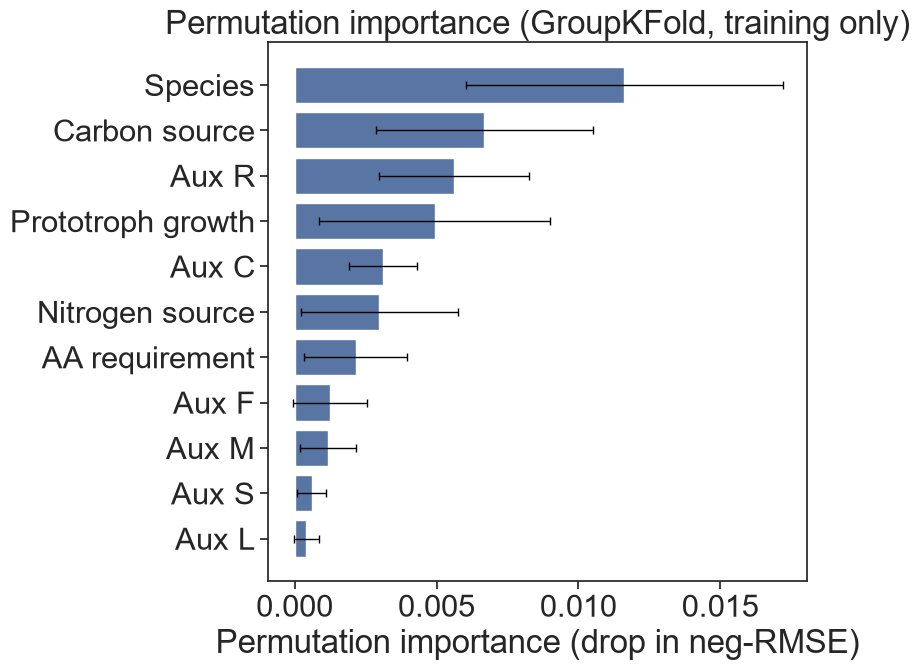

In [92]:
# Figure S10C
perm_cv_df["feature_label"] = perm_cv_df["feature"].replace(label_map)

fig, ax = plt.subplots(1,1, figsize=(10,7), subplot_kw={'box_aspect': 1})
ax = sns.barplot(data=perm_cv_df, y="feature_label",x="importance_mean",
                 orient="h")

ax.errorbar(x=perm_cv_df["importance_mean"], y=range(len(perm_cv_df)),
            xerr=perm_cv_df["importance_std"], fmt="none",
            capsize=3, color="black", linewidth=1)

ax.set_xlabel("Permutation importance (drop in neg-RMSE)")
ax.set_ylabel("")
plt.title("Permutation importance (GroupKFold, training only)")

plt.savefig("images/FigS10C.jpeg", dpi=300, bbox_inches="tight", pad_inches=0.2)


# Table S1
Auxotrophy type level differences in cross-feeding between species


In [94]:
aux_diff_across_sp=cf_comp_pair_df.copy().query("Aux1 != Aux2")[['Aux1','Aux2','Norm_mean_Bs','Norm_mean_Ec']]
aux_diff_across_sp['diff']=abs(aux_diff_across_sp['Norm_mean_Bs']-aux_diff_across_sp['Norm_mean_Ec'])


results = []

for aux in ['M', 'F', 'R', 'C', 'S', 'L']:
    contains_aux = (aux_diff_across_sp["Aux1"] == aux) | (aux_diff_across_sp["Aux2"] == aux)

    contains_vals = aux_diff_across_sp.loc[contains_aux, "diff"].values
    other_vals = aux_diff_across_sp.loc[~contains_aux, "diff"].values

    mean_contains = contains_vals.mean()
    mean_other = other_vals.mean()
    contrast = mean_contains - mean_other

    # One-sided test: are pairs containing this auxotrophy more species-divergent?
    mw = mannwhitneyu(contains_vals, other_vals, alternative= 'greater')

    results.append({"Auxotrophy": aux, "Mean difference in pairs containing auxotrophy type": mean_contains,
                    "Mean difference in pairs not containing auxotrophy type": mean_other, 
                    "Contrast": contrast, "Mann-WhitneyU_p": mw.pvalue})

results = pd.DataFrame(results)

# Correct for testing all six auxotrophies
results["FDR_p"] = multipletests(results["Mann-WhitneyU_p"], method="fdr_bh")[1]

results = results.sort_values("Contrast", ascending=False).round(3)

results

,Auxotrophy,Mean difference in pairs containing auxotrophy type,Mean difference in pairs not containing auxotrophy type,Contrast,Mann-WhitneyU_p,FDR_p
2,R,0.046,0.018,0.029,0.006,0.038
0,M,0.031,0.026,0.005,0.257,0.770
5,L,0.027,0.028,-0.001,0.523,0.936
4,S,0.026,0.028,-0.002,0.661,0.936
1,F,0.022,0.030,-0.008,0.780,0.936
3,C,0.012,0.035,-0.023,0.986,0.986


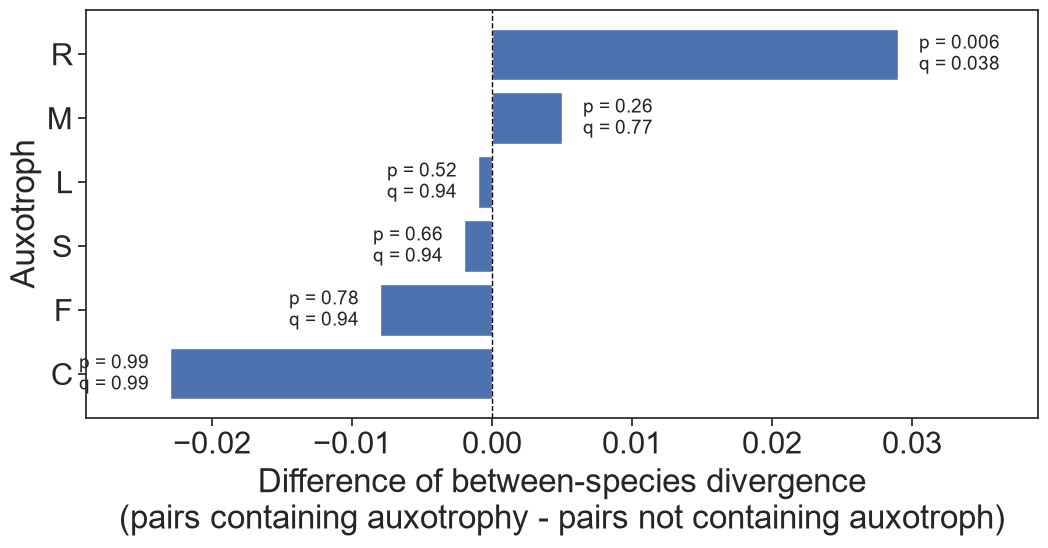

In [95]:
#Visualization of table S1, not used in manuscript

plot_df = results.sort_values("Contrast", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 6)) 

# Bar plot 
bars = ax.barh(plot_df["Auxotrophy"], plot_df["Contrast"]) 

# Vertical zero line 
ax.axvline(0, color="black", linestyle="--", linewidth=1) 
ax.set_xlim(-0.029,0.039) 


# Axis labels 
ax.set_xlabel("Difference of between-species divergence\n"+ "(pairs containing auxotrophy - pairs not containing auxotroph)") 
ax.set_ylabel("Auxotroph") 

# Add p and q values next to each bar 
for i, row in plot_df.iterrows(): 
    x = row["Contrast"] 
    y = list(plot_df.index).index(i) 
    label = f"p = {row['Mann-WhitneyU_p']:.2g}\nq = {row['FDR_p']:.2g}" 
    if x >= 0: 
        ax.text(x + 0.0015, y, label, va="center", ha="left", fontsize=14) 
    else: 
        ax.text(x - 0.0015, y, label, va="center", ha="right", fontsize=14) 

plt.tight_layout() 
plt.show()
